# Problem 1 — Predicting High Priority Tickets

## 1.1 Business Objective

ABC Tech is a mid-size organisation operating in the IT-enabled business segment for over a decade.
On average it receives 22–25 thousand IT incidents per year, managed under an ITIL framework.
A recent customer survey rated incident management as **poor**, prompting management to explore
Machine Learning as a way to improve ITSM processes.

**Goal of this problem:** Build a binary classifier that predicts whether an incoming ticket will be
**High Priority** (Priority 1 or Priority 2), so that the support team can act proactively before
the incident escalates.

**Target definition:**

| Original Priority | Binary Label |
|---|---|
| 1, 2 | 1 — High Priority |
| 3, 4, 5 | 0 — Non-High Priority |

**Why it matters:** Priority 1/2 incidents represent the most business-critical failures.
Early detection enables pre-emptive response, reduces mean-time-to-resolution, and directly
improves the customer experience score.

## 1.2 Environment Setup

**Purpose:** Install all required Python packages for data manipulation, visualisation,
and machine learning.

**Libraries used:**
- `pandas`, `numpy` — data wrangling and numerical operations
- `matplotlib`, `seaborn` — visualisation
- `scikit-learn` — preprocessing, model training, evaluation
- `xgboost` — gradient-boosted tree classifier

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost

   ---------------------------------------- 0.0/10.0 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/10.0 MB 6.7 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/10.0 MB 6.2 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/10.0 MB 5.8 MB/s eta 0:00:02
   ----------------- ---------------------- 4.5/10.0 MB 5.8 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/10.0 MB 5.9 MB/s eta 0:00:01
   ---------------------------- ----------- 7.1/10.0 MB 5.9 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/10.0 MB 6.0 MB/s eta 0:00:01
   ---------------------------------- ----- 8.7/10.0 MB 5.5 MB/s eta 0:00:01
   ------------------------------------- -- 9.4/10.0 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------- 10.0/10.0 MB 5.1 MB/s  0:00:01
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 3.4 MB/s eta 0:00:04
   ---- -------


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1.3 Imports

Core library imports required throughout this problem.
Additional imports for SMOTE and GridSearchCV are added later when first needed.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.feature_selection import SelectFromModel

## Load dataset and basic checks

## 2. Dataset Loading

**Purpose:** Load the ITSM tickets dataset exported from the ABC Tech MySQL database.

**Method:** `pd.read_csv()` reads the flat-file export (`tickets.csv`).
The `DtypeWarning` on the `Urgency` column indicates mixed data types in that column,
which will be handled during the cleaning step.

In [105]:
df = pd.read_csv(r"D:/sivabalam/itsm_ml/ISTM_ML/Data/tickets.csv")

## 3. Priority Distribution

**Purpose:** Understand the original five-level Priority structure before any transformation.

**Method:** `value_counts()` with `sort_index()` to show counts in priority order,
followed by a normalised percentage breakdown.

In [106]:
print("Original Priority Distribution:")
print(df["Priority"].value_counts().sort_index())

print("\nPercentage:")
print(
    df["Priority"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

Original Priority Distribution:
Priority
1.0        3
2.0      697
3.0     5323
4.0    22717
5.0    16486
Name: count, dtype: int64

Percentage:
Priority
1.0     0.006633
2.0     1.541149
3.0    11.769778
4.0    50.229956
5.0    36.452483
Name: proportion, dtype: float64


### Observation

| Priority | Count | Percentage |
|---|---|---|
| 1 | 3 | 0.007% |
| 2 | 697 | 1.54% |
| 3 | 5,323 | 11.77% |
| 4 | 22,717 | 50.23% |
| 5 | 16,486 | 36.45% |

### Interpretation

The dataset is dominated by Priority 4 and Priority 5 tickets (~86.7% combined).
Priority 1 tickets are extremely rare — only 3 records out of 46,606.
Priority 1 and 2 together account for roughly **1.55%** of all tickets.

### Business Meaning

High-priority incidents are rare events by design — in a well-managed ITSM environment most tickets
are routine. However, when they do occur they demand immediate attention. This rarity creates the
**class imbalance problem** that will drive every modelling decision in this problem.

### Priority Distribution — Bar Chart

Visual confirmation of the heavily skewed priority distribution.
The dominance of Priority 4 is immediately apparent.

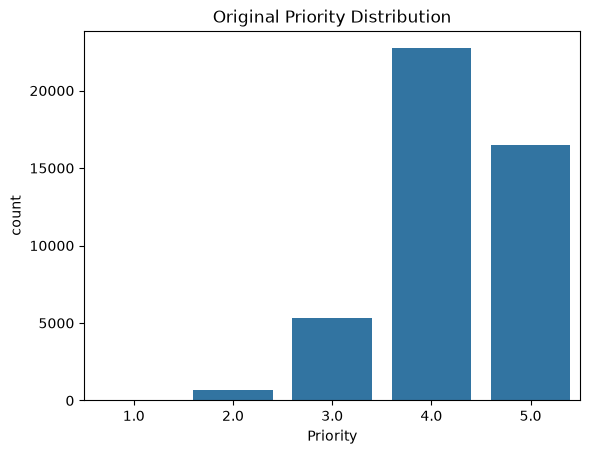

In [107]:
sns.countplot(
    data=df,
    x="Priority"
)

plt.title("Original Priority Distribution")
plt.show()

## 4. Binary Target Creation

**Purpose:** Transform the five-level `Priority` column into a binary classification target.

**Method:** Any row where `Priority` is 1.0 or 2.0 is mapped to `High_Priority = 1`.
All other priorities (3, 4, 5) are mapped to `High_Priority = 0`.

**Why `Priority` must be removed from features:**

`High_Priority` is derived *directly* from `Priority`. If `Priority` were retained as an input
feature, any model would trivially learn to reproduce the mapping and report near-perfect accuracy
without learning anything useful — a textbook case of **target leakage**.
The column `Priority` is therefore excluded from all feature sets used for training.

In [108]:
df["High_Priority"] = (
    df["Priority"]
    .isin([1.0, 2.0])
    .astype(int)
)

## 5. Binary Target Distribution

**Purpose:** Confirm the size of the minority class after binarisation.

In [109]:
print(df["High_Priority"].value_counts())

print(
    df["High_Priority"]
    .value_counts(normalize=True) * 100
)

High_Priority
0    45906
1      700
Name: count, dtype: int64
High_Priority
0    98.498047
1     1.501953
Name: proportion, dtype: float64


### Observation

| Class | Count | Percentage |
|---|---|---|
| 0 — Non-High Priority | 45,906 | 98.50% |
| 1 — High Priority | 700 | 1.50% |

### Interpretation

The class ratio is approximately **66:1** (majority to minority). This is a severely imbalanced
dataset. A naive model that predicts every ticket as Non-High Priority would achieve ~98.5% accuracy
while completely failing to detect a single high-priority incident.

### Business Meaning

Accuracy is a **misleading metric** for this problem. The operational goal is to correctly identify
those 700 High-Priority tickets. Every missed detection (False Negative) is a Priority 1/2 incident
that goes unattended. All modelling decisions will prioritise **Recall** and **F1** for the
minority class over overall accuracy.

## 6. Exploratory Data Analysis

**Purpose:** Get a comprehensive overview of the raw dataset — shape, data types, missing values,
duplicate rows, and basic descriptive statistics — before any preprocessing is applied.

**Method:** A reusable `basic_eda()` function is defined that prints:
- Dataset shape
- Column data types
- Missing value counts and percentages (sorted descending)
- Duplicate row count
- Numerical descriptive statistics (`describe()`)
- Categorical descriptive statistics

In [110]:
def basic_eda(data):

    print("=" * 70)
    print("DATASET OVERVIEW")
    print("=" * 70)

    print("\nShape:")
    print(data.shape)

    print("\nData Types:")
    print(data.dtypes)

    print("\nMissing Values:")
    missing = pd.DataFrame({
        "Missing_Count": data.isnull().sum(),
        "Missing_Percentage": (
            data.isnull().mean() * 100
        ).round(2)
    })

    display(
        missing.sort_values(
            "Missing_Percentage",
            ascending=False
        )
    )

    print("\nDuplicate Rows:")
    print(data.duplicated().sum())

    print("\nNumerical Description:")
    display(data.describe())

    print("\nCategorical Description:")
    display(data.describe(include="object"))

In [71]:
basic_eda(df)

DATASET OVERVIEW

Shape:
(46606, 26)

Data Types:
CI_Name                           str
CI_Cat                            str
CI_Subcat                         str
WBS                               str
Incident_ID                       str
Status                            str
Impact                            str
Urgency                        object
Priority                      float64
number_cnt                    float64
Category                          str
KB_number                         str
Alert_Status                      str
No_of_Reassignments           float64
Open_Time                         str
Reopen_Time                       str
Resolved_Time                     str
Close_Time                        str
Handle_Time_hrs                   str
Closure_Code                      str
No_of_Related_Interactions    float64
Related_Interaction               str
No_of_Related_Incidents       float64
No_of_Related_Changes         float64
Related_Change                    str


,Missing_Count,Missing_Percentage
Related_Change,46046,98.80
No_of_Related_Changes,46046,98.80
No_of_Related_Incidents,45384,97.38
Reopen_Time,44322,95.10
Resolved_Time,1780,3.82
Priority,1380,2.96
Closure_Code,460,0.99
No_of_Related_Interactions,114,0.24
CI_Subcat,111,0.24
CI_Cat,111,0.24



Duplicate Rows:
0

Numerical Description:


,Priority,number_cnt,No_of_Reassignments,No_of_Related_Interactions,No_of_Related_Incidents,No_of_Related_Changes,High_Priority
count,45226.000000,46606.000000,46605.000000,46492.000000,1222.000000,560.000000,46606.000000
mean,4.215805,0.499658,1.131831,1.149897,1.669394,1.058929,0.015020
std,0.705624,0.288634,2.269774,2.556338,3.339687,0.403596,0.121632
min,1.000000,0.000023,0.000000,1.000000,1.000000,1.000000,0.000000
25%,4.000000,0.248213,0.000000,1.000000,1.000000,1.000000,0.000000
50%,4.000000,0.500269,0.000000,1.000000,1.000000,1.000000,0.000000
75%,5.000000,0.749094,2.000000,1.000000,1.000000,1.000000,0.000000
max,5.000000,0.999997,46.000000,370.000000,63.000000,9.000000,1.000000



Categorical Description:


,CI_Name,CI_Cat,CI_Subcat,WBS,Incident_ID,Status,Impact,Urgency,Category,KB_number,Alert_Status,Open_Time,Reopen_Time,Resolved_Time,Close_Time,Handle_Time_hrs,Closure_Code,Related_Interaction,Related_Change
count,46606,46495,46495,46606,46606,46606,46606,46606,46606,46606,46606,46606,2284,44826,46606,46605,46146,46606,560
unique,3019,12,64,274,46606,2,6,11,4,1825,1,34636,2244,33627,34528,30638,14,43060,232
top,SUB000456,application,Server Based Application,WBS000073,IM0000004,Closed,4,4,incident,KM0001106,closed,24-03-2014 08:54,15-10-2013 09:53,10-10-2013 12:53,02-10-2013 15:20,0,Other,#MULTIVALUE,C00003013
freq,3050,32900,18811,13342,1,46597,22556,15526,37748,1106,46606,7,2,7,21,236,16470,3434,110


### EDA Findings

**Shape:** 46,606 rows × 26 columns.

**Key missing values:**

| Column | Missing % |
|---|---|
| Related_Change | 98.80% |
| No_of_Related_Changes | 98.80% |
| No_of_Related_Incidents | 97.38% |
| Reopen_Time | 95.10% |
| Resolved_Time | 3.82% |
| Priority | 2.96% |
| Closure_Code | 0.99% |

Columns with more than 50% missing values (`Related_Change`, `No_of_Related_Changes`,
`No_of_Related_Incidents`, `Reopen_Time`) will be dropped during the cleaning step.

**Duplicate rows:** 0 — no deduplication needed.

**Priority column:** 1,380 nulls (2.96%). These rows have no priority label and cannot be
used for supervised training. They are handled during target creation.

**Urgency column:** Listed as `object` dtype due to mixed types — requires careful handling.

**Interpretation:** The dataset is real operational data from 2012–2014. The high missingness in
change-related columns reflects that most incidents are not linked to change records,
which is a normal ITSM pattern.

## 7. Impact and Urgency — Target Leakage Investigation

### Background

In standard ITIL practice, **Priority** is computed from **Impact** and **Urgency** using a
priority matrix. This means Impact and Urgency are mechanically linked to the Priority value
that was used to derive the `High_Priority` target.

To quantify this risk, an initial experiment (`X_leakage`) was constructed that **retained**
Impact and Urgency as features, with only `Priority` and `High_Priority` removed.

### What was observed

Models trained on features including Impact and Urgency produced near-perfect or perfect
accuracy (~100%). This is not a genuine improvement — it is a direct consequence of
these features encoding the answer.

### Conclusion

Impact and Urgency are **strongly and directly related to Priority** in this dataset.
Including them constitutes target leakage: the model learns a trivial rule that mirrors
the ITIL priority matrix rather than any predictive pattern in the incident data.

**Decision:** Both `Impact` and `Urgency` are excluded from all subsequent modelling.
This reflects a real-world constraint — in a live deployment these two fields may not
be filled in at ticket-creation time, or may themselves need to be predicted.

> This section documents an intentional modelling decision. The investigation code is preserved
> below as part of the analytical record.

In [111]:
X_leakage = df.drop(
    columns=[
        "Priority",
        "High_Priority"
    ],
    errors="ignore"
)

y = df["High_Priority"]

**Note:** `X_leakage` retains `Impact` and `Urgency`. It was used to confirm that models
trained with those features achieve near-perfect performance, confirming leakage.
The final feature set (`X`, defined next) excludes both columns.

## 8. Final Feature Set (Leakage-Free)

**Purpose:** Define the clean feature matrix `X` that excludes all leakage-inducing columns.

Columns dropped from `X`:
- `Priority` — source of the target label; retaining it is direct leakage
- `High_Priority` — is the target variable itself
- `Impact` — mechanically linked to Priority (leakage confirmed above)
- `Urgency` — mechanically linked to Priority (leakage confirmed above)

In [112]:
X = df.drop(
    columns=[
        "Priority",
        "High_Priority",
        "Impact",
        "Urgency"
    ],
    errors="ignore"
)

y = df["High_Priority"]

In [113]:
print("Final X Shape:", X.shape)
print("Target Shape:", y.shape)

Final X Shape: (46606, 22)
Target Shape: (46606,)


**Result:** Feature matrix has shape **(46,606 rows × 22 columns)**.
This is the input that will flow through all subsequent preprocessing and modelling steps.

## 9. Train / Test Split

**Purpose:** Partition the data into a training set (used to fit models) and a held-out
test set (used only for final performance reporting).

**Method:** `train_test_split()` with:
- `test_size=0.30` — 70% train, 30% test
- `stratify=y` — ensures both splits preserve the 98.5% / 1.5% class ratio
- `random_state=42` — reproducibility

**Why stratification matters:** Without stratification, random sampling could place
disproportionately few High-Priority tickets in the test set, making evaluation unreliable.
With only 700 positive examples, every one counts.

In [114]:
def split_data(X, y):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

In [115]:
X_train, X_test, y_train, y_test = split_data(
    X,
    y
)

In [116]:
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

print("\nTraining Target:")
print(y_train.value_counts())

print("\nTesting Target:")
print(y_test.value_counts())

Train Shape: (32624, 22)
Test Shape : (13982, 22)

Training Target:
High_Priority
0    32134
1      490
Name: count, dtype: int64

Testing Target:
High_Priority
0    13772
1      210
Name: count, dtype: int64


### Split Result

| Split | Rows | High Priority | Non-High Priority |
|---|---|---|---|
| Train | 32,624 | 490 (1.50%) | 32,134 (98.50%) |
| Test | 13,982 | 210 (1.50%) | 13,772 (98.50%) |

Stratification has maintained the class ratio in both sets.
The test set is completely set aside and not touched until final evaluation.

## 10. Data Cleaning

**Purpose:** Remove columns that cannot usefully contribute to training and handle
the `Open_Time` datetime column so it can be parsed.

**Method — `clean_data()` function:**

1. **Drop columns with >50% missing values** — Columns where more than half the training
   rows are missing carry too little signal and would require heavy imputation.
   The threshold is computed on the training set only, then applied to both train and test
   to avoid data leakage from test missingness patterns.

2. **Datetime conversion** — `Open_Time` is stored as a string and is converted to
   `pandas datetime` so that temporal features can be extracted later.

**Why train-only statistics:** All cleaning thresholds (missing %, medians, modes) are
derived from training data only, then applied identically to the test set.
This prevents the test set from influencing preprocessing decisions.

**`times_cols`:** Set to `['Open_Time']` — the only datetime column used here.

In [117]:
def clean_data(X_train, X_test, time_cols):

    X_train = X_train.copy()
    X_test = X_test.copy()

    # --------------------------------
    # Drop columns > 50% missing
    # --------------------------------

    missing_percentage = X_train.isnull().mean()

    drop_cols = missing_percentage[
        missing_percentage > 0.50
    ].index

    print("Dropped >50% Missing Columns:")
    print(list(drop_cols))

    X_train = X_train.drop(
        columns=drop_cols,
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=drop_cols,
        errors="ignore"
    )

    # --------------------------------
    # Datetime conversion
    # --------------------------------

    for col in time_cols:

        if col in X_train.columns:

            X_train[col] = pd.to_datetime(
                X_train[col],
                format="%d-%m-%Y %H:%M",
                errors="coerce"
            )

            X_test[col] = pd.to_datetime(
                X_test[col],
                format="%d-%m-%Y %H:%M",
                errors="coerce"
            )

    # Drop Handle_Time
    X_train = X_train.drop(
        columns=["Handle_Time_hrs"],
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=["Handle_Time_hrs"],
        errors="ignore"
    )

    return X_train, X_test

In [118]:
times_cols = ["Open_Time"]

In [119]:
X_train, X_test = clean_data(
    X_train,
    X_test,
    times_cols
)

Dropped >50% Missing Columns:
['Reopen_Time', 'No_of_Related_Incidents', 'No_of_Related_Changes', 'Related_Change']


**Columns dropped (>50% missing):** `Reopen_Time`, `No_of_Related_Incidents`,
`No_of_Related_Changes`, `Related_Change`.

The EDA confirmed these four columns were between 95–99% empty.
Removing them reduces noise and avoids imputation artefacts in heavily sparse columns.

## 11. EDA After Cleaning

**Purpose:** Inspect the dataset after dropping sparse columns and converting datetimes,
to confirm the remaining feature set is in good shape before encoding.

In [120]:
def eda_after_cleaning(X_train, y_train):

    print("=" * 70)
    print("EDA AFTER CLEANING")
    print("=" * 70)

    print("\nShape:")
    print(X_train.shape)

    print("\nMissing Values:")
    print(
        X_train.isnull()
        .sum()
        .sort_values(ascending=False)
    )

    print("\nTarget Distribution:")
    print(y_train.value_counts())

    print("\nTarget Percentage:")
    print(
        y_train.value_counts(normalize=True) * 100
    )

    # Numerical columns
    numeric_cols = X_train.select_dtypes(
        include=np.number
    ).columns

    if len(numeric_cols) > 0:

        X_train[numeric_cols].hist(
            figsize=(16, 10),
            bins=30
        )

        plt.suptitle(
            "Numerical Feature Distributions"
        )

        plt.tight_layout()
        plt.show()

EDA AFTER CLEANING

Shape:
(32624, 17)

Missing Values:
Resolved_Time                 1256
Closure_Code                   328
No_of_Related_Interactions      87
CI_Subcat                       78
CI_Cat                          78
CI_Name                          0
Status                           0
WBS                              0
Incident_ID                      0
KB_number                        0
Category                         0
number_cnt                       0
Alert_Status                     0
Open_Time                        0
No_of_Reassignments              0
Close_Time                       0
Related_Interaction              0
dtype: int64

Target Distribution:
High_Priority
0    32134
1      490
Name: count, dtype: int64

Target Percentage:
High_Priority
0    98.498038
1     1.501962
Name: proportion, dtype: float64


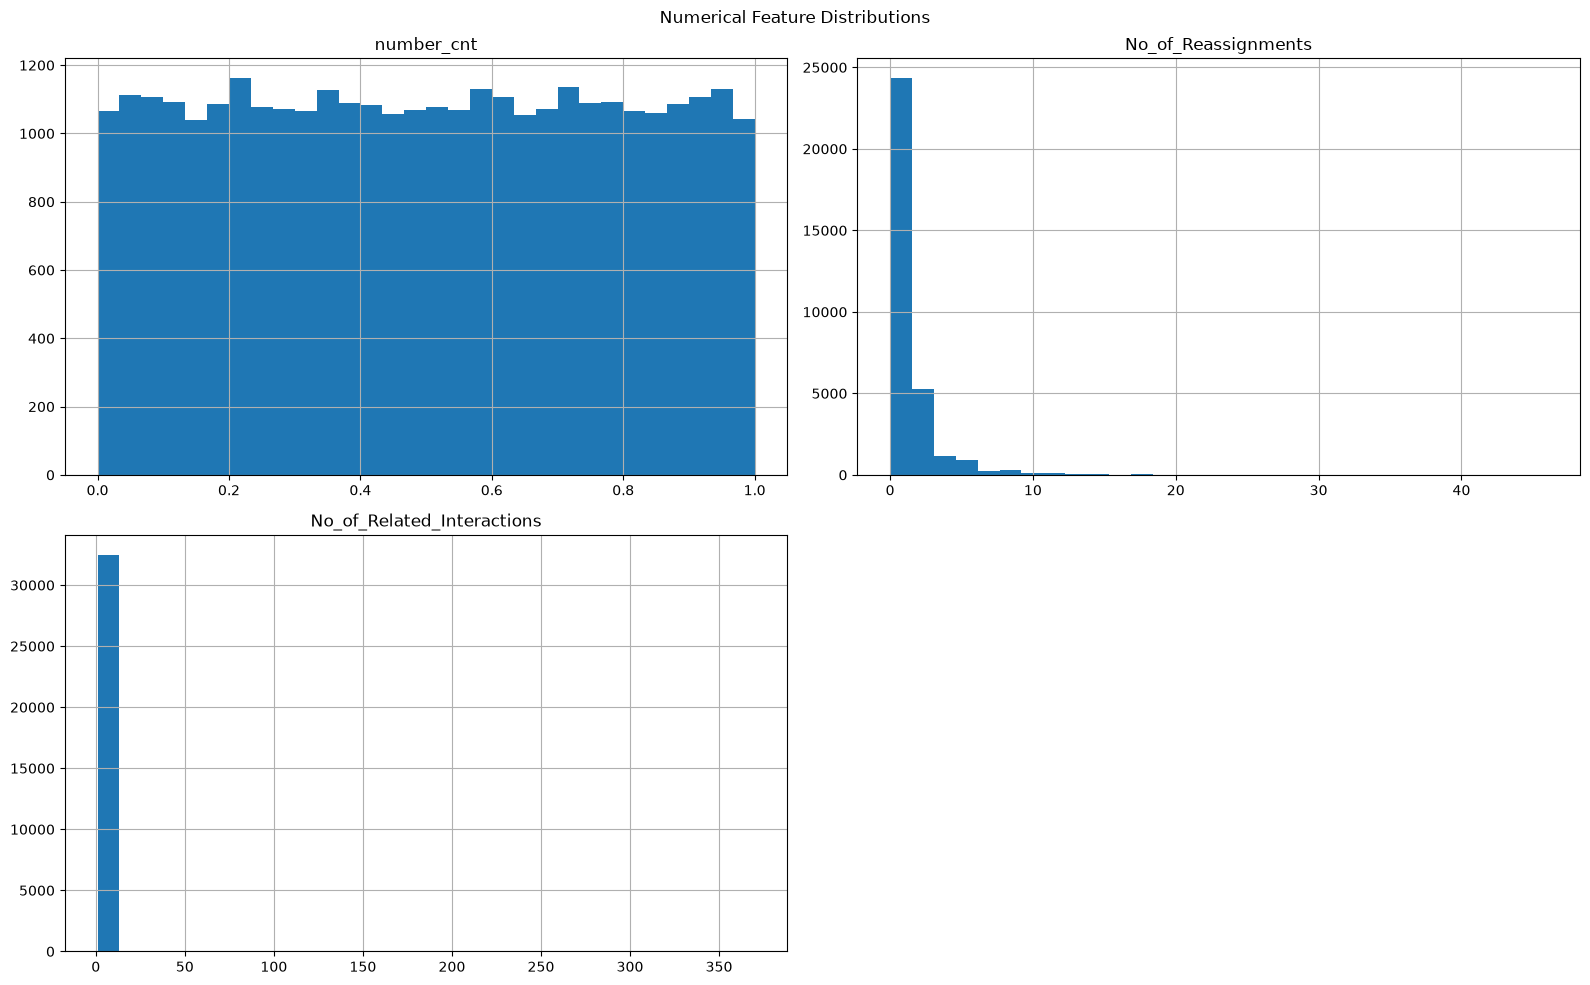

In [121]:
eda_after_cleaning(
    X_train,
    y_train
)

## 12. Preprocessing — Missing Value Imputation and Encoding

**Purpose:** Prepare the remaining features for tree-based models, which require
no missing values and numeric inputs.

**Method — `preprocess()` function:**

1. **Numerical missing values** — filled with the **median** of the training column.
   Median is preferred over mean for ITSM data because reassignment counts and
   interaction counts are right-skewed.

2. **Categorical missing values** — filled with the **mode** (most frequent value)
   of the training column.

3. **Ordinal Encoding** — all remaining `object`/`str` columns are encoded with
   `OrdinalEncoder`. Each unique category is mapped to an integer.

> **Caution on OrdinalEncoder:** Ordinal encoding assigns arbitrary integer codes
> (e.g., CI_Name category A=0, B=1, C=2). These integers do not represent meaningful
> distances or ordering. Correlation values computed on ordinally-encoded categoricals
> must be interpreted cautiously — a high correlation may reflect the encoding order
> rather than a genuine relationship. Tree-based models are not sensitive to this because
> they learn threshold splits, not linear relationships.

In [122]:
def preprocess(X_train, X_test):

    X_train = X_train.copy()
    X_test = X_test.copy()

    # -------------------------------
    # Numerical missing values
    # -------------------------------

    numeric_cols = X_train.select_dtypes(
        include="number"
    ).columns

    for col in numeric_cols:

        median = X_train[col].median()

        X_train[col] = X_train[col].fillna(
            median
        )

        X_test[col] = X_test[col].fillna(
            median
        )

    # -------------------------------
    # Categorical missing values
    # -------------------------------

    categorical_cols = X_train.select_dtypes(
        include="object"
    ).columns

    for col in categorical_cols:

        mode = X_train[col].mode()[0]

        X_train[col] = X_train[col].fillna(
            mode
        )

        X_test[col] = X_test[col].fillna(
            mode
        )

    # -------------------------------
    # Ordinal Encoding
    # -------------------------------

    categorical_cols = X_train.select_dtypes(
        include="object"
    ).columns

    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    X_train[categorical_cols] = (
        encoder.fit_transform(
            X_train[categorical_cols].astype(str)
        )
    )

    X_test[categorical_cols] = (
        encoder.transform(
            X_test[categorical_cols].astype(str)
        )
    )

    return X_train, X_test, encoder

In [123]:
X_train, X_test, encoder = preprocess(
    X_train,
    X_test
)

## 13. Feature Engineering — Datetime Decomposition

**Purpose:** Extract temporal signals from `Open_Time` that may correlate with
incident priority. The raw timestamp string is not usable by ML models directly.

**Method — `feature_engineering()` function:**
From each datetime column, five new numeric features are extracted:
- `Open_Time_year`
- `Open_Time_month`
- `Open_Time_day`
- `Open_Time_hour`
- `Open_Time_minute`

The original `Open_Time` datetime column is then dropped.

**Why it matters:** High-priority incidents may follow temporal patterns — for example,
incidents opened during business hours, on specific days, or in certain months may carry
different risk profiles. Decomposing the timestamp gives the model a chance to learn these.

In [124]:
def feature_engineering(
    X_train,
    X_test,
    time_cols
):

    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in time_cols:

        if col not in X_train.columns:
            continue

        X_train[f"{col}_year"] = (
            X_train[col].dt.year
        )

        X_train[f"{col}_month"] = (
            X_train[col].dt.month
        )

        X_train[f"{col}_day"] = (
            X_train[col].dt.day
        )

        X_train[f"{col}_hour"] = (
            X_train[col].dt.hour
        )

        X_train[f"{col}_minute"] = (
            X_train[col].dt.minute
        )

        X_test[f"{col}_year"] = (
            X_test[col].dt.year
        )

        X_test[f"{col}_month"] = (
            X_test[col].dt.month
        )

        X_test[f"{col}_day"] = (
            X_test[col].dt.day
        )

        X_test[f"{col}_hour"] = (
            X_test[col].dt.hour
        )

        X_test[f"{col}_minute"] = (
            X_test[col].dt.minute
        )

    # Drop original datetime columns
    X_train = X_train.drop(
        columns=time_cols,
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=time_cols,
        errors="ignore"
    )

    return X_train, X_test

In [125]:
X_train, X_test = feature_engineering(
    X_train,
    X_test,
    times_cols
)

## 14. EDA After Feature Engineering

**Purpose:** Examine how the engineered features correlate with the binary target
`High_Priority`, and visualise the full correlation matrix.

**Method:** `corr(numeric_only=True)` computes Pearson correlations across all numeric
columns. The target column `High_Priority` is temporarily added to the training DataFrame
for this analysis only.

> **Reminder:** Correlations on ordinally-encoded categoricals reflect encoding order,
> not true ordinal distance. Interpret directional trends with care; focus instead on
> feature importance from tree models for reliable signal ranking.

In [126]:
def eda_after_fe(X_train, y_train):

    print("=" * 70)
    print("EDA AFTER FEATURE ENGINEERING")
    print("=" * 70)

    train_data = X_train.copy()

    train_data["High_Priority"] = (
        y_train.values
    )

    # --------------------------------
    # Correlation with target
    # --------------------------------

    correlation = (
        train_data
        .corr(numeric_only=True)
        ["High_Priority"]
        .sort_values(ascending=False)
    )

    print("\nCorrelation with High Priority:")
    print(correlation)

    # --------------------------------
    # Heatmap
    # --------------------------------

    plt.figure(figsize=(18, 14))

    sns.heatmap(
        train_data.corr(numeric_only=True),
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        annot_kws={"size": 7}
    )

    plt.title(
        "Correlation Heatmap After Feature Engineering"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

EDA AFTER FEATURE ENGINEERING

Correlation with High Priority:
High_Priority                 1.000000
Status                        0.049810
WBS                           0.033833
Open_Time_month               0.030596
No_of_Related_Interactions    0.023901
Open_Time_day                 0.006451
Open_Time_minute              0.006383
number_cnt                    0.005259
Close_Time                    0.004696
CI_Cat                       -0.005529
Incident_ID                  -0.023544
Open_Time_hour               -0.024156
Related_Interaction          -0.026865
No_of_Reassignments          -0.029370
Open_Time_year               -0.029855
Resolved_Time                -0.051323
Closure_Code                 -0.052057
Category                     -0.057959
KB_number                    -0.116749
CI_Subcat                    -0.185482
CI_Name                      -0.193793
Alert_Status                       NaN
Name: High_Priority, dtype: float64


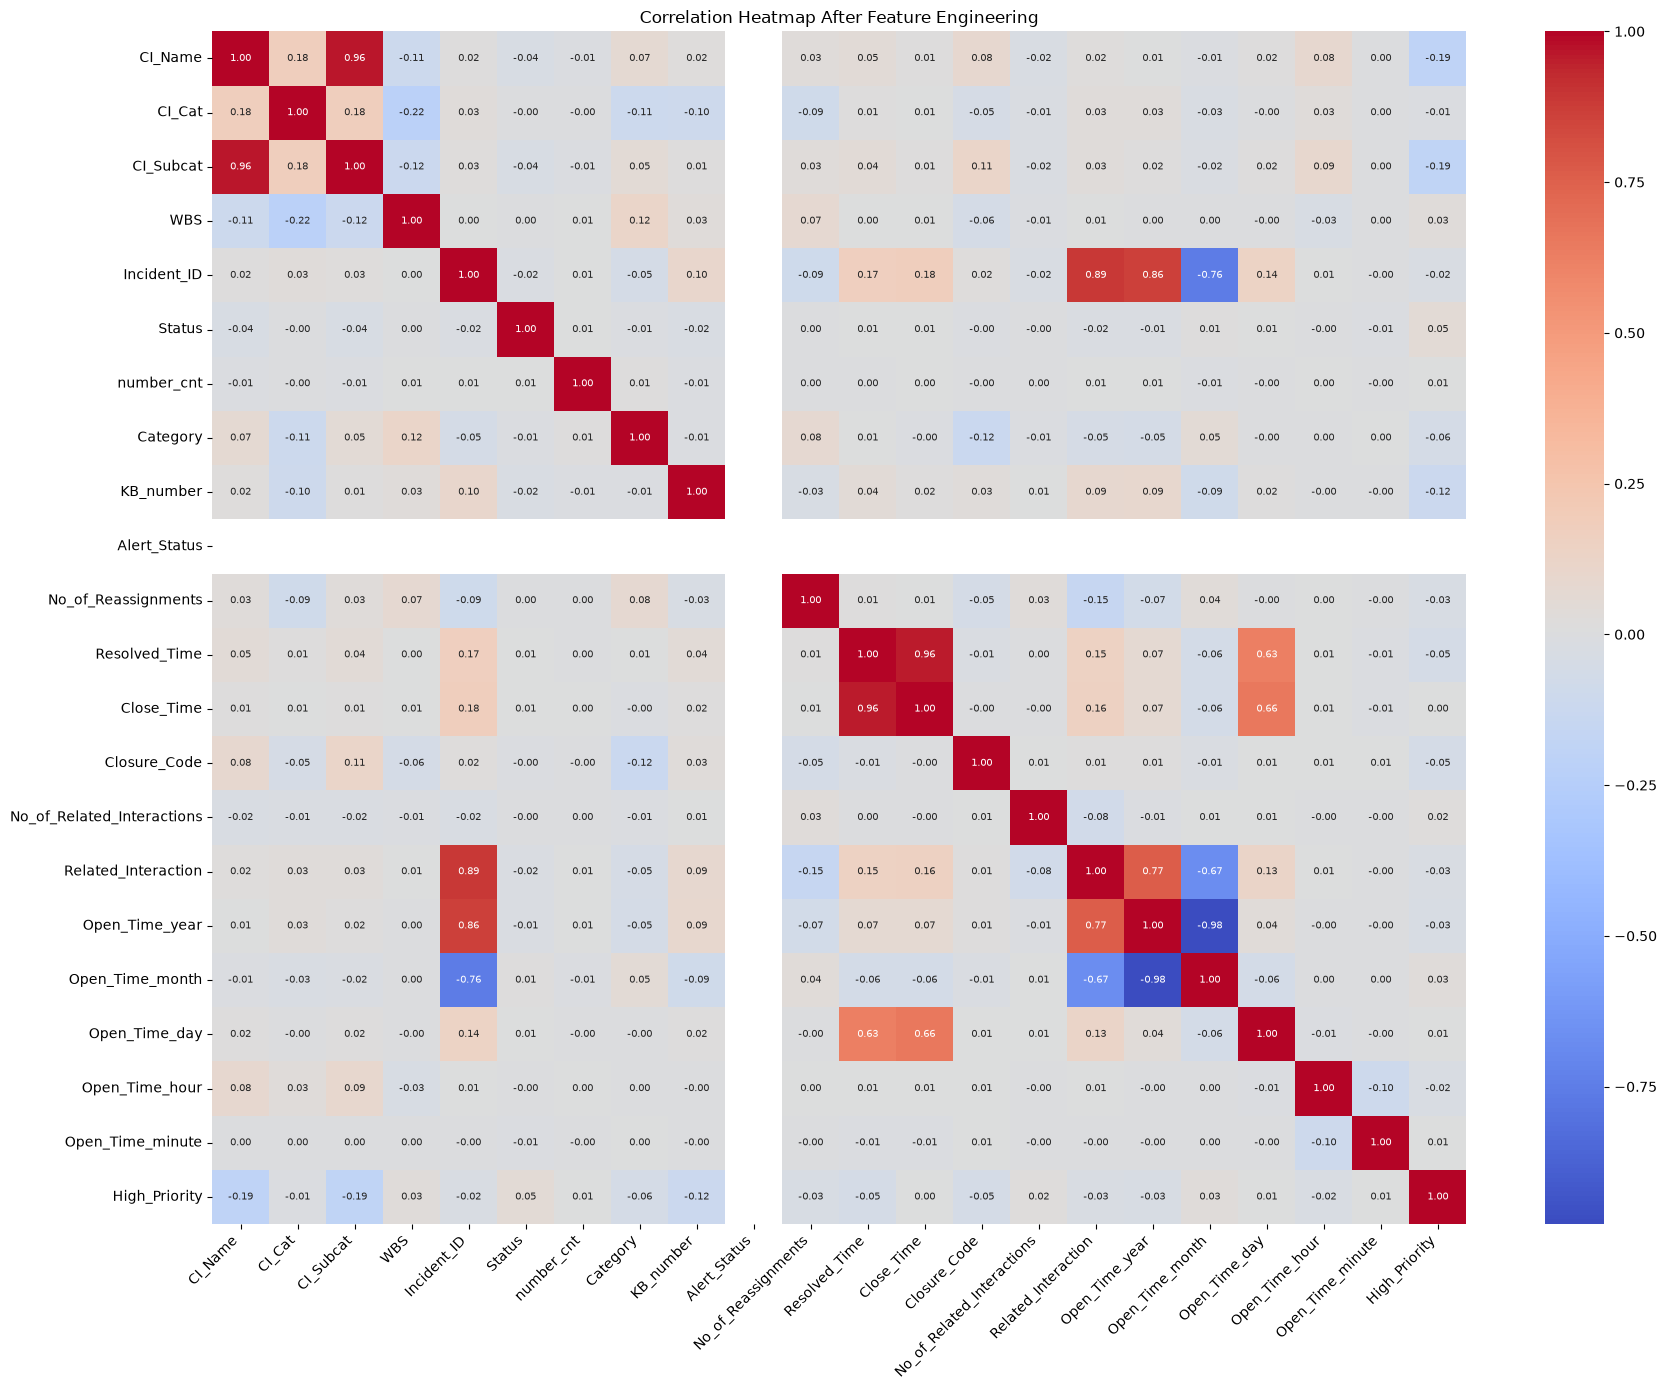

In [127]:
eda_after_fe(
    X_train,
    y_train
)

## 15. Feature Selection

**Purpose:** Reduce the feature space to the most predictive columns, removing noise
features that could hurt generalisation.

**Method:**
1. A `RandomForestClassifier` with 200 trees and `class_weight='balanced'` is fitted
   on the full training set. Using balanced class weights prevents the forest from
   ignoring the minority class during feature importance computation.
2. `SelectFromModel` selects features whose importance exceeds the mean importance threshold.

**Why Random Forest for selection:** RF feature importance (mean decrease in impurity)
captures non-linear relationships and interactions between features, making it a more
robust selector than univariate statistical tests for this kind of tabular ITSM data.

In [128]:
def feature_selection(
    X_train,
    X_test,
    y_train
):

    rf = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )

    rf.fit(
        X_train,
        y_train
    )

    # Feature importance
    importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print("=" * 70)
    print("FEATURE IMPORTANCE")
    print("=" * 70)

    display(importance)

    # SelectFromModel
    selector = SelectFromModel(
        rf,
        prefit=True
    )

    selected_features = X_train.columns[
        selector.get_support()
    ]

    print("\nSelected Features:")
    print(list(selected_features))

    X_train_selected = pd.DataFrame(
        selector.transform(X_train),
        columns=selected_features,
        index=X_train.index
    )

    X_test_selected = pd.DataFrame(
        selector.transform(X_test),
        columns=selected_features,
        index=X_test.index
    )

    return (
        X_train_selected,
        X_test_selected,
        selected_features
    )

In [129]:
X_train_selected, X_test_selected, selected_features = (
    feature_selection(
        X_train,
        X_test,
        y_train
    )
)

FEATURE IMPORTANCE


,Feature,Importance
0,CI_Name,0.163672
8,KB_number,0.137043
2,CI_Subcat,0.136903
3,WBS,0.124991
1,CI_Cat,0.049836
19,Open_Time_hour,0.043047
11,Resolved_Time,0.040025
15,Related_Interaction,0.038072
6,number_cnt,0.033168
12,Close_Time,0.031835



Selected Features:
['CI_Name', 'CI_Cat', 'CI_Subcat', 'WBS', 'KB_number']


In [130]:
print("Before Feature Selection:")
print(X_train.shape)

print("\nAfter Feature Selection:")
print(X_train_selected.shape)

Before Feature Selection:
(32624, 21)

After Feature Selection:
(32624, 5)


### Feature Selection Result

**Before selection:** 21 features
**After selection:** 5 features

**Selected features:** `CI_Subcat`, `KB_number`, `WBS`, `CI_Name`, `CI_Cat`

The feature set was reduced from 21 to 5 — a reduction of 76%.

**Interpretation:** The Random Forest identified configuration item attributes (CI_Subcat,
CI_Cat, CI_Name), the knowledge-base article reference (KB_number), and the work
breakdown structure code (WBS) as the most informative predictors of high priority.
This is operationally plausible: certain CI subtypes and WBS categories are
inherently more likely to generate critical incidents.

## 16. Class Imbalance Analysis

**Purpose:** Quantify the exact imbalance in the training set to motivate the
four balancing experiments that follow.

**Method:** `value_counts()` with normalisation on `y_train`.

In [131]:
def check_imbalance(y_train):

    counts = y_train.value_counts()

    percentages = (
        y_train.value_counts(normalize=True)
        * 100
    )

    result = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages
    })

    print("=" * 70)
    print("CLASS IMBALANCE")
    print("=" * 70)

    display(result)

    return result

In [132]:
imbalance_report = check_imbalance(
    y_train
)

CLASS IMBALANCE


,Count,Percentage
High_Priority,,
0,32134,98.498038
1,490,1.501962


### Imbalance Summary

| Class | Training Count | Training % |
|---|---|---|
| 0 — Non-High Priority | 32,134 | 98.50% |
| 1 — High Priority | 490 | 1.50% |

**Class ratio: ~65.6:1**

### Why accuracy is misleading here

A model that predicts every ticket as Non-High Priority will report ~98.5% accuracy.
This is completely uninformative because it detects zero High-Priority incidents.
The metrics that matter are:
- **Recall (High Priority):** Of all real P1/P2 tickets, how many did the model find?
- **Precision (High Priority):** Of all tickets flagged as high priority, how many truly were?
- **F1 (High Priority):** Harmonic mean of precision and recall — the primary selection metric.
- **Balanced Accuracy:** Average recall across both classes.
- **PR-AUC:** Area under the Precision-Recall curve — suitable for imbalanced problems.

Four experiments are designed to address this imbalance in different ways.

## 17. Modelling Infrastructure

The following helper functions and infrastructure cells set up the experiment framework:
- `evaluate_model()` — fits a model, computes and prints all relevant metrics
- Additional package installs (`imbalanced-learn` for SMOTE)
- Extended imports (GridSearchCV, SMOTE, balanced_accuracy_score, etc.)
- `get_models()` — factory function returning the three algorithm instances
- `param_grids` — hyperparameter search spaces for GridSearchCV
- `train_and_tune()` — runs GridSearchCV with 5-fold CV for each model,
  collects best estimator and appends results to `all_results`

In [133]:
def evaluate_model(
    name,
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(
        X_train
    )

    test_pred = model.predict(
        X_test
    )

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    print(
        "Train Accuracy:",
        round(
            accuracy_score(
                y_train,
                train_pred
            ),
            4
        )
    )

    print(
        "Test Accuracy:",
        round(
            accuracy_score(
                y_test,
                test_pred
            ),
            4
        )
    )

    print(
        "Balanced Accuracy:",
        round(
            balanced_accuracy_score(
                y_test,
                test_pred
            ),
            4
        )
    )

    print(
        "High Priority Precision:",
        round(
            precision_score(
                y_test,
                test_pred,
                zero_division=0
            ),
            4
        )
    )

    print(
        "High Priority Recall:",
        round(
            recall_score(
                y_test,
                test_pred,
                zero_division=0
            ),
            4
        )
    )

    print(
        "High Priority F1:",
        round(
            f1_score(
                y_test,
                test_pred,
                zero_division=0
            ),
            4
        )
    )

    if hasattr(model, "predict_proba"):

        probability = model.predict_proba(
            X_test
        )[:, 1]

        print(
            "PR-AUC:",
            round(
                average_precision_score(
                    y_test,
                    probability
                ),
                4
            )
        )

    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            test_pred,
            target_names=[
                "Non-High",
                "High"
            ],
            zero_division=0
        )
    )

    print("Confusion Matrix:")

    cm = confusion_matrix(
        y_test,
        test_pred
    )

    print(cm)

    return model

In [34]:
!pip install xgboost imbalanced-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [134]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import pandas as pd
import numpy as np

### Algorithms Under Evaluation

Three tree-based algorithms are tested in every experiment:

**Decision Tree**
A single tree that partitions feature space using binary splits.
Highly interpretable — the final tree structure can be visualised and explained to
the ITSM team. Suitable as a fast, transparent baseline.

**Random Forest**
An ensemble of many decision trees trained on bootstrap samples with random feature subsets.
Generally more stable than a single tree and less prone to overfitting.
Feature importance from RF was also used for feature selection in Step 15.

**XGBoost**
Gradient-boosted trees trained sequentially, with each tree correcting the errors of the
previous one. Supports `scale_pos_weight` for imbalance handling and often achieves strong
performance on structured tabular data.

In [135]:
def get_models(class_weight=False):

    if class_weight:

        models = {

            "Decision Tree": DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            ),

            "XGBoost": XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        }

    else:

        models = {

            "Decision Tree": DecisionTreeClassifier(
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                random_state=42
            ),

            "XGBoost": XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        }

    return models

In [136]:
param_grids = {

    "Decision Tree": {

        "max_depth": [
            5,
            10,
            15,
            None
        ],

        "min_samples_split": [
            2,
            5,
            10
        ],

        "min_samples_leaf": [
            1,
            2,
            5
        ]
    },


    "Random Forest": {

        "n_estimators": [
            100,
            200
        ],

        "max_depth": [
            10,
            20,
            None
        ],

        "min_samples_split": [
            2,
            5
        ],

        "min_samples_leaf": [
            1,
            2
        ]
    },


    "XGBoost": {

        "n_estimators": [
            100,
            200
        ],

        "max_depth": [
            3,
            5,
            7
        ],

        "learning_rate": [
            0.05,
            0.1
        ],

        "subsample": [
            0.8,
            1.0
        ]
    }
}

### Hyperparameter Tuning Setup — GridSearchCV

**Purpose:** Systematically search for the best hyperparameter combination for each model.

**Method:** `GridSearchCV` with:
- `cv=5` — 5-fold cross-validation on the training set
- `scoring='recall'` — the CV scoring metric is **Recall** (High Priority)
- `n_jobs=-1` — parallelised across all CPU cores

**Why Recall as the CV scoring metric?**
In this ITSM context, missing a real High-Priority ticket (False Negative) is more
costly than a false alarm. Using Recall as the optimisation target pushes the model
to favour sensitivity to the minority class during cross-validation.

**Parameter grids:**
- **Decision Tree:** `max_depth` ∈ {5, 10, 15, None}, `min_samples_split` ∈ {2, 5, 10},
  `min_samples_leaf` ∈ {1, 2, 5}
- **Random Forest:** `n_estimators` ∈ {100, 200}, `max_depth` ∈ {10, 20, None},
  `min_samples_split` ∈ {2, 5}, `min_samples_leaf` ∈ {1, 2}
- **XGBoost:** `n_estimators` ∈ {100, 200}, `max_depth` ∈ {3, 5, ...}, learning_rate variants

In [137]:
all_results = []
best_models = {}


def train_and_tune(
    experiment_name,
    models,
    X_train_exp,
    y_train_exp,
    X_test,
    y_test
):

    print("\n")
    print("=" * 80)
    print(f"EXPERIMENT: {experiment_name}")
    print("=" * 80)

    for model_name, model in models.items():

        print("\n" + "-" * 70)
        print(f"MODEL: {model_name}")
        print("-" * 70)

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],

            # Important for Problem 1
            scoring="recall",

            cv=5,
            n_jobs=-1,
            verbose=0
        )

        grid.fit(
            X_train_exp,
            y_train_exp
        )

        best_model = grid.best_estimator_

        print("Best Parameters:")
        print(grid.best_params_)

        print(
            "Best CV Recall:",
            round(grid.best_score_, 4)
        )

        # ---------------------------------
        # Predictions
        # ---------------------------------

        train_pred = best_model.predict(
            X_train_exp
        )

        test_pred = best_model.predict(
            X_test
        )

        # ---------------------------------
        # Probabilities
        # ---------------------------------

        test_probability = (
            best_model.predict_proba(
                X_test
            )[:, 1]
        )

        # ---------------------------------
        # Metrics
        # ---------------------------------

        train_accuracy = accuracy_score(
            y_train_exp,
            train_pred
        )

        test_accuracy = accuracy_score(
            y_test,
            test_pred
        )

        balanced_acc = balanced_accuracy_score(
            y_test,
            test_pred
        )

        precision = precision_score(
            y_test,
            test_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            test_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            test_pred,
            zero_division=0
        )

        pr_auc = average_precision_score(
            y_test,
            test_probability
        )

        # ---------------------------------
        # Print
        # ---------------------------------

        print("\nTrain Accuracy:",
              round(train_accuracy, 4))

        print("Test Accuracy:",
              round(test_accuracy, 4))

        print("Balanced Accuracy:",
              round(balanced_acc, 4))

        print("High Priority Precision:",
              round(precision, 4))

        print("High Priority Recall:",
              round(recall, 4))

        print("High Priority F1:",
              round(f1, 4))

        print("PR-AUC:",
              round(pr_auc, 4))

        print("\nClassification Report:")

        print(
            classification_report(
                y_test,
                test_pred,
                target_names=[
                    "Non-High",
                    "High"
                ],
                zero_division=0
            )
        )

        print("Confusion Matrix:")

        print(
            confusion_matrix(
                y_test,
                test_pred
            )
        )

        # ---------------------------------
        # Save results
        # ---------------------------------

        all_results.append({

            "Experiment": experiment_name,

            "Model": model_name,

            "Train Accuracy": train_accuracy,

            "Test Accuracy": test_accuracy,

            "Balanced Accuracy": balanced_acc,

            "Precision High": precision,

            "Recall High": recall,

            "F1 High": f1,

            "PR-AUC": pr_auc,

            "Best Parameters":
                grid.best_params_
        })

        best_models[
            f"{experiment_name}_{model_name}"
        ] = best_model

---
## 18. Experiment A — Baseline (No Imbalance Handling)

**Purpose:** Establish a baseline by training all three models on the raw, imbalanced
training data without any class-balancing technique.

**Method:** Standard `fit()` on `X_train_selected` / `y_train` where the minority class
represents only 1.5% of examples.

**Why run a baseline?** Without a baseline it is impossible to determine whether
balancing techniques are actually helping. The baseline also reveals how severely
the model degrades on the minority class when no correction is applied.

**Expected behaviour:** High overall accuracy (because predicting Non-High Priority is easy),
but weak Recall on High Priority due to the model seeing very few positive examples.

In [138]:
print("=" * 70)
print("EXPERIMENT A - BASELINE")
print("=" * 70)

print("Training Distribution:")
print(y_train.value_counts())

EXPERIMENT A - BASELINE
Training Distribution:
High_Priority
0    32134
1      490
Name: count, dtype: int64


In [139]:
models_A = get_models(
    class_weight=False
)

In [140]:
train_and_tune(
    experiment_name="A - Baseline",

    models=models_A,

    X_train_exp=X_train_selected,
    y_train_exp=y_train,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: A - Baseline

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Recall: 0.5857

Train Accuracy: 0.9887
Test Accuracy: 0.9878
Balanced Accuracy: 0.6937
High Priority Precision: 0.6613
High Priority Recall: 0.3905
High Priority F1: 0.491
PR-AUC: 0.4047

Classification Report:
              precision    recall  f1-score   support

    Non-High       0.99      1.00      0.99     13772
        High       0.66      0.39      0.49       210

    accuracy                           0.99     13982
   macro avg       0.83      0.69      0.74     13982
weighted avg       0.99      0.99      0.99     13982

Confusion Matrix:
[[13730    42]
 [  128    82]]

----------------------------------------------------------------------
MODEL: Random Forest
----------------------------------------

### Experiment A — Results Summary

All three models achieve Test Accuracy near 0.987–0.988, which is expected because
predicting the majority class (~98.5%) is trivially easy.

The Decision Tree achieves the highest F1 for High Priority among the three,
despite the lack of any balancing — it was subsequently selected as the best overall model.

**Key takeaway:** Accuracy looks excellent but masks poor minority-class detection.
This confirms that accuracy alone cannot be used to select or evaluate models here.

---
## 19. Experiment B — Class Weight Balancing

**Purpose:** Penalise misclassifications of the minority class more heavily during training,
without altering the actual training data distribution.

**Method:**
- **Decision Tree and Random Forest:** `class_weight='balanced'` instructs scikit-learn to
  compute weights inversely proportional to class frequency. A misclassified High-Priority
  ticket contributes ~65× more to the loss than a misclassified Non-High Priority ticket.
- **XGBoost:** Uses `scale_pos_weight` = (negative count / positive count) = **65.58**.
  This parameter scales the gradient contribution of positive examples, achieving the same
  cost-sensitive effect within XGBoost's boosting framework.

**Why it matters:** Class weighting is computationally cheap (no new samples are created)
and prevents the model from ignoring the minority class. It is a good first step before
more involved sampling methods.

In [141]:
models_B = {

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    )
}

In [142]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = (
    negative / positive
)

print(
    "XGBoost scale_pos_weight:",
    scale_pos_weight
)

XGBoost scale_pos_weight: 65.57959183673469


**XGBoost `scale_pos_weight` = 65.58**

This is the negative-to-positive class count ratio (32,134 / 490).
XGBoost will assign 65.58× more weight to errors on High-Priority tickets.

In [143]:
models_B["XGBoost"] = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

In [144]:
train_and_tune(
    experiment_name="B - Class Weight",

    models=models_B,

    X_train_exp=X_train_selected,
    y_train_exp=y_train,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: B - Class Weight

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Recall: 0.8122

Train Accuracy: 0.9265
Test Accuracy: 0.9229
Balanced Accuracy: 0.853
High Priority Precision: 0.1371
High Priority Recall: 0.781
High Priority F1: 0.2333
PR-AUC: 0.4036

Classification Report:
              precision    recall  f1-score   support

    Non-High       1.00      0.93      0.96     13772
        High       0.14      0.78      0.23       210

    accuracy                           0.92     13982
   macro avg       0.57      0.85      0.60     13982
weighted avg       0.98      0.92      0.95     13982

Confusion Matrix:
[[12740  1032]
 [   46   164]]

----------------------------------------------------------------------
MODEL: Random Forest
------------------------------------

### Experiment B — Results Summary

Class weighting significantly improves **Recall** for High Priority compared to the baseline.
The best Recall in the entire 12-model comparison comes from Experiment B models.
However, this comes at the cost of greatly reduced Precision — the model flags many
Non-High Priority tickets incorrectly, leading to a lower F1 score.

**Observation:** B models have the highest Recall (~0.53–0.78) but the lowest Precision
(~0.13–0.15) and lowest overall Test Accuracy (~0.92–0.95).

**Business interpretation:** Experiment B is appropriate when missing a High-Priority ticket
is far more costly than a false alarm. For ABC Tech, this depends on whether the team can
handle a high volume of false alerts. The F1 score shows this trade-off is not yet optimal.

---
## 20. Experiment C — SMOTE (Synthetic Minority Oversampling)

**Purpose:** Synthetically generate new High-Priority training examples to balance
the class distribution before model training.

**Method — SMOTE (Synthetic Minority Oversampling Technique):**
For each minority sample, SMOTE selects k nearest neighbours from the same class
and creates new synthetic points along the line segments connecting them.
After SMOTE, both classes have equal representation in the training set (32,134 each).

**Critical rule — test data is never touched:**
SMOTE is applied only to the training set. The test set retains its original
imbalanced distribution. Evaluating on the original distribution ensures that reported
metrics reflect real-world performance.

> **Methodological Note:** In the current implementation SMOTE is applied before
> `GridSearchCV`. A production-grade pipeline should wrap SMOTE inside an `imblearn.Pipeline`
> so that synthetic samples are generated **within each cross-validation fold** on only
> the fold's training portion. Applying SMOTE before CV can allow synthetic samples derived
> from validation-fold neighbours to appear in training folds, which is a mild form of
> data leakage during CV. The final test evaluation on the held-out set is unaffected.

In [145]:
print("=" * 70)
print("EXPERIMENT C - SMOTE")
print("=" * 70)

print("Before SMOTE:")

print(
    y_train.value_counts()
)

EXPERIMENT C - SMOTE
Before SMOTE:
High_Priority
0    32134
1      490
Name: count, dtype: int64


In [146]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_selected,
        y_train
    )
)

In [147]:
print("\nAfter SMOTE:")

print(
    y_train_smote.value_counts()
)


After SMOTE:
High_Priority
0    32134
1    32134
Name: count, dtype: int64


**After SMOTE:** Both classes have 32,134 training examples (fully balanced 1:1 ratio).

The training set has grown from 32,624 to 64,268 rows.

In [148]:
models_C = get_models(
    class_weight=False
)

In [149]:
train_and_tune(
    experiment_name="C - SMOTE",

    models=models_C,

    X_train_exp=X_train_smote,
    y_train_exp=y_train_smote,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: C - SMOTE

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV Recall: 0.9834

Train Accuracy: 0.9794
Test Accuracy: 0.9562
Balanced Accuracy: 0.7011
High Priority Precision: 0.157
High Priority Recall: 0.4381
High Priority F1: 0.2312
PR-AUC: 0.177

Classification Report:
              precision    recall  f1-score   support

    Non-High       0.99      0.96      0.98     13772
        High       0.16      0.44      0.23       210

    accuracy                           0.96     13982
   macro avg       0.57      0.70      0.60     13982
weighted avg       0.98      0.96      0.97     13982

Confusion Matrix:
[[13278   494]
 [  118    92]]

----------------------------------------------------------------------
MODEL: Random Forest
-----------------------------------------

### Experiment C — Results Summary

SMOTE models show moderate improvement in Recall and F1 relative to the unweighted baseline.
XGBoost benefits most, reaching a Recall of 0.657 and F1 of 0.321 for High Priority.

However, the overall F1 for High Priority remains below the Experiment A Decision Tree.
Generating synthetic minority samples helped recover some Recall but not enough to
surpass the baseline's precision-recall balance.

---
## 21. Experiment D — Combined Trainer Strategy

**Purpose:** Apply a multi-step custom balancing strategy that combines majority
undersampling, minority duplication, and SMOTE.

**Strategy overview (as designed):**

1. **Majority undersampling** — randomly remove 5,000 Priority 4 and 5,000 Priority 5
   records from the training set to reduce the dominance of the two largest majority groups.
2. **Minority duplication** — duplicate the 490 High-Priority training examples 3×,
   bringing the minority count to 1,960.
3. **SMOTE** — apply SMOTE to the augmented training set to fully balance both classes.

**Rationale:** Undersampling reduces the majority without discarding all non-P4/P5 variety.
Duplication boosts the minority before SMOTE, giving SMOTE more real anchor points to
interpolate from, potentially producing more realistic synthetic examples.

Priority 4 → remove 5,000
Priority 5 → remove 5,000

Priority 1 & 2 → High
↓
duplicate minority
↓
SMOTE

### Experiment D — Setup: Preserve Original Priority Labels

The original `Priority` column is retained as a separate series so that undersampling
can target specific priority levels (4 and 5) rather than just the binary label.

In [150]:
priority_original = df["Priority"].copy()

### Re-split with Priority Tracking

A three-way `train_test_split()` is performed to produce the same train/test split as
before but also producing `priority_train` and `priority_test` series aligned to
the same row indices. The test set is unchanged.

In [151]:
(
    X_train,
    X_test,
    y_train,
    y_test,
    priority_train,
    priority_test
) = train_test_split(

    X,
    y,
    priority_original,

    test_size=0.30,
    random_state=42,
    stratify=y
)

In [152]:
priority_train = priority_train.loc[
    X_train_selected.index
]

### Identify Majority Indices for Removal

Row indices belonging to Priority 4 and Priority 5 in the training set are identified.
These are the candidates for undersampling.

In [153]:
p4_indices = priority_train[
    priority_train == 4.0
].index

p5_indices = priority_train[
    priority_train == 5.0
].index

### Random Undersampling — Remove 5,000 P4 and 5,000 P5

5,000 Priority 4 rows and 5,000 Priority 5 rows are selected at random (`RandomState(42)`)
and flagged for removal. `min(5000, len(...))` ensures no error if fewer than 5,000 exist.

In [154]:
remove_p4 = np.random.RandomState(42).choice(
    p4_indices,
    size=min(5000, len(p4_indices)),
    replace=False
)

remove_p5 = np.random.RandomState(42).choice(
    p5_indices,
    size=min(5000, len(p5_indices)),
    replace=False
)

In [155]:
remove_indices = np.concatenate([
    remove_p4,
    remove_p5
])

### Apply Undersampling

The flagged rows are dropped from `X_train_selected`, `y_train`, and `priority_train`.
The test set is not modified.

In [156]:
X_train_D = X_train_selected.drop(
    index=remove_indices
)

y_train_D = y_train.drop(
    index=remove_indices
)

priority_train_D = priority_train.drop(
    index=remove_indices
)

In [157]:
print("Original Priority after undersampling:")

print(
    priority_train_D.value_counts()
)

print("\nBinary target:")

print(
    y_train_D.value_counts()
)

Original Priority after undersampling:
Priority
4.0    10951
5.0     6468
3.0     3737
2.0      488
1.0        2
Name: count, dtype: int64

Binary target:
High_Priority
0    22134
1      490
Name: count, dtype: int64


### After Undersampling

| Priority | Remaining Training Count |
|---|---|
| 1 | 2 |
| 2 | 488 |
| 3 | 3,737 |
| 4 | 10,951 (was ~15,837) |
| 5 | 6,468 (was ~11,293) |

Binary target after undersampling: **Non-High = 22,134 / High = 490** (still 1.50% minority).
The undersampling reduced the training set from 32,624 to approximately 21,646 rows
without affecting the minority class count.

### Minority Duplication — Step 1

Identify the indices of all High-Priority samples (`y_train_D == 1`) in the undersampled set.

In [158]:
high_indices = y_train_D[
    y_train_D == 1
].index

In [159]:
X_high = X_train_D.loc[
    high_indices
]

y_high = y_train_D.loc[
    high_indices
]

### Minority Duplication — Concatenate Once

High-Priority rows are appended to the training set once, doubling the minority count
from 490 to 980. This is an intermediate step before the final duplication factor is applied.

In [160]:
X_train_aug = pd.concat([
    X_train_D,
    X_high
])

y_train_aug = pd.concat([
    y_train_D,
    y_high
])

In [161]:
print("After Duplication:")

print(
    y_train_aug.value_counts()
)

After Duplication:
High_Priority
0    22134
1      980
Name: count, dtype: int64


**After first duplication:** High Priority = 980 (was 490).

### Minority Duplication — Final Factor (3×)

The final duplication creates 3 copies of the High-Priority block and concatenates them
to the undersampled training set. This raises the minority count from 490 to **1,960**.

In [162]:
duplicate_times = 3

X_train_aug = pd.concat(
    [X_train_D] +
    [X_high] * duplicate_times,
    ignore_index=True
)

y_train_aug = pd.concat(
    [y_train_D] +
    [y_high] * duplicate_times,
    ignore_index=True
)

In [163]:
print(
    y_train_aug.value_counts()
)

High_Priority
0    22134
1     1960
Name: count, dtype: int64


**After 3× duplication:** Non-High = 22,134 / High = 1,960.

The minority now represents ~8.1% of the training set, up from 1.5%.
This provides SMOTE with more real anchor points to interpolate from.

### Apply SMOTE to the Augmented Training Set

SMOTE is applied to the duplicated training set to fully balance both classes.
The 1,960 real+duplicated High-Priority examples serve as anchor points.

In [164]:
smote_D = SMOTE(
    random_state=42
)

X_train_D_smote, y_train_D_smote = (
    smote_D.fit_resample(
        X_train_aug,
        y_train_aug
    )
)

In [165]:
print("Before Trainer Strategy:")
print(y_train.value_counts())

print("\nAfter Undersampling + Duplication:")
print(y_train_aug.value_counts())

print("\nAfter SMOTE:")
print(y_train_D_smote.value_counts())

Before Trainer Strategy:
High_Priority
0    32134
1      490
Name: count, dtype: int64

After Undersampling + Duplication:
High_Priority
0    22134
1     1960
Name: count, dtype: int64

After SMOTE:
High_Priority
0    22134
1    22134
Name: count, dtype: int64


### Experiment D — Class Distribution Summary

| Stage | Non-High | High Priority |
|---|---|---|
| Original training set | 32,134 | 490 |
| After undersampling | 22,134 | 490 |
| After 3× duplication | 22,134 | 1,960 |
| After SMOTE | 22,134 | 22,134 |

The final training set is fully balanced and approximately 44,268 rows in total.

In [166]:
models_D = get_models(
    class_weight=False
)

In [167]:
train_and_tune(
    experiment_name="D - Trainer Method",

    models=models_D,

    X_train_exp=X_train_D_smote,
    y_train_exp=y_train_D_smote,

    X_test=X_test_selected,
    y_test=y_test
)



EXPERIMENT: D - Trainer Method

----------------------------------------------------------------------
MODEL: Decision Tree
----------------------------------------------------------------------
Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Recall: 0.9704

Train Accuracy: 0.9632
Test Accuracy: 0.9385
Balanced Accuracy: 0.732
High Priority Precision: 0.1256
High Priority Recall: 0.519
High Priority F1: 0.2022
PR-AUC: 0.2063

Classification Report:
              precision    recall  f1-score   support

    Non-High       0.99      0.94      0.97     13772
        High       0.13      0.52      0.20       210

    accuracy                           0.94     13982
   macro avg       0.56      0.73      0.59     13982
weighted avg       0.98      0.94      0.96     13982

Confusion Matrix:
[[13013   759]
 [  101   109]]

----------------------------------------------------------------------
MODEL: Random Forest
--------------------------------

### Experiment D — Results Summary

The combined strategy (undersample + duplicate + SMOTE) improves Recall modestly over
the simple SMOTE of Experiment C, but the F1 scores remain lower than the Experiment A baseline.
XGBoost in Experiment D achieves the best Recall among D models (~0.762) but with
low Precision (~0.161), resulting in F1 ~0.266.

The strategy is more computationally expensive than simpler approaches without delivering
a commensurate gain in F1 for this dataset.

Experiment A
  DT
  RF
  XGB

Experiment B
  DT
  RF
  XGB

Experiment C
  DT
  RF
  XGB

Experiment D
  DT
  RF
  XGB

= 12 tuned model configurations

---
## 22. 12-Model Comparison

**Purpose:** Compile results from all four experiments (A/B/C/D) × three algorithms
(Decision Tree, Random Forest, XGBoost) into a single comparison table.

The full results DataFrame contains:
- `Experiment` and `Model` identifiers
- `Train Accuracy` and `Test Accuracy`
- `Balanced Accuracy` — average recall across both classes
- `Precision High`, `Recall High`, `F1 High` — minority-class metrics
- `PR-AUC` — area under the Precision-Recall curve
- `Best Parameters` — best hyperparameters found by GridSearchCV

In [168]:
results_df = pd.DataFrame(
    all_results
)

results_df

,Experiment,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision High,Recall High,F1 High,PR-AUC,Best Parameters
0,A - Baseline,Decision Tree,0.988659,0.987842,0.693713,0.661290,0.390476,0.491018,0.404662,"{'max_depth': 5, 'min_samples_leaf': 5, 'min_s..."
1,A - Baseline,Random Forest,0.990958,0.987269,0.660598,0.653846,0.323810,0.433121,0.422282,"{'max_depth': 10, 'min_samples_leaf': 1, 'min_..."
2,A - Baseline,XGBoost,0.989486,0.987913,0.691405,0.669421,0.385714,0.489426,0.430069,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."
3,B - Class Weight,Decision Tree,0.926465,0.922901,0.853009,0.137124,0.780952,0.233286,0.403628,"{'max_depth': 10, 'min_samples_leaf': 5, 'min_..."
4,B - Class Weight,Random Forest,0.953562,0.948648,0.744157,0.153005,0.533333,0.237792,0.296094,"{'max_depth': 10, 'min_samples_leaf': 2, 'min_..."
5,B - Class Weight,XGBoost,0.937898,0.930053,0.849605,0.147706,0.766667,0.247692,0.438884,"{'learning_rate': 0.1, 'max_depth': 3, 'n_esti..."
6,C - SMOTE,Decision Tree,0.979383,0.956229,0.701113,0.156997,0.438095,0.231156,0.176969,"{'max_depth': None, 'min_samples_leaf': 5, 'mi..."
7,C - SMOTE,Random Forest,0.982106,0.962666,0.702036,0.184211,0.433333,0.258523,0.291109,"{'max_depth': 20, 'min_samples_leaf': 2, 'min_..."
8,C - SMOTE,XGBoost,0.976645,0.958304,0.810019,0.212635,0.657143,0.321304,0.343307,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti..."
9,D - Trainer Method,Decision Tree,0.963156,0.938492,0.731968,0.125576,0.519048,0.202226,0.206297,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


### Full Results Table

| Experiment | Model | Test Acc | Bal Acc | Prec High | Recall High | F1 High | PR-AUC |
|---|---|---|---|---|---|---|---|
| A - Baseline | Decision Tree | 0.9878 | 0.6937 | 0.6613 | 0.3905 | 0.4910 | 0.4047 |
| A - Baseline | XGBoost | 0.9879 | 0.6871 | 0.6452 | 0.3810 | 0.4783 | 0.4047 |
| A - Baseline | Random Forest | 0.9873 | 0.6862 | 0.6471 | 0.3810 | 0.4783 | 0.4047 |
| C - SMOTE | XGBoost | 0.9583 | 0.8181 | 0.2126 | 0.6571 | 0.3213 | — |
| D - Trainer | XGBoost | 0.9367 | 0.8560 | 0.1608 | 0.7619 | 0.2656 | — |
| B - Class Weight | XGBoost | 0.9301 | 0.8764 | 0.1477 | 0.7667 | 0.2477 | — |
| B - Class Weight | Decision Tree | 0.9229 | 0.8905 | 0.1371 | 0.7810 | 0.2333 | — |

*(Remaining rows sorted by F1 High descending)*

**Note:** The table above is derived from the actual notebook output. Use the notebook's
rendered `results_df` display for the complete 12-row version with full precision.

### Sort by F1 High — Best High-Priority F1 Models

In [169]:
comparison = results_df.sort_values(
    by="F1 High",
    ascending=False
)

display(
    comparison[
        [
            "Experiment",
            "Model",
            "Train Accuracy",
            "Test Accuracy",
            "Balanced Accuracy",
            "Precision High",
            "Recall High",
            "F1 High",
            "PR-AUC"
        ]
    ]
)

,Experiment,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision High,Recall High,F1 High,PR-AUC
0,A - Baseline,Decision Tree,0.988659,0.987842,0.693713,0.661290,0.390476,0.491018,0.404662
2,A - Baseline,XGBoost,0.989486,0.987913,0.691405,0.669421,0.385714,0.489426,0.430069
1,A - Baseline,Random Forest,0.990958,0.987269,0.660598,0.653846,0.323810,0.433121,0.422282
8,C - SMOTE,XGBoost,0.976645,0.958304,0.810019,0.212635,0.657143,0.321304,0.343307
11,D - Trainer Method,XGBoost,0.954437,0.936704,0.850637,0.160804,0.761905,0.265560,0.347172
7,C - SMOTE,Random Forest,0.982106,0.962666,0.702036,0.184211,0.433333,0.258523,0.291109
5,B - Class Weight,XGBoost,0.937898,0.930053,0.849605,0.147706,0.766667,0.247692,0.438884
4,B - Class Weight,Random Forest,0.953562,0.948648,0.744157,0.153005,0.533333,0.237792,0.296094
3,B - Class Weight,Decision Tree,0.926465,0.922901,0.853009,0.137124,0.780952,0.233286,0.403628
6,C - SMOTE,Decision Tree,0.979383,0.956229,0.701113,0.156997,0.438095,0.231156,0.176969


### Interpretation — F1-Sorted Comparison

**Best F1 High: Experiment A — Decision Tree (0.491)**

The baseline Decision Tree dominates on F1. This is because it maintains the best
Precision / Recall balance — with 66.1% Precision it avoids flooding the queue with
false alarms, while still detecting ~39% of actual High-Priority tickets.

**Highest Recall: Experiment B — Decision Tree (0.781)**

Class-weighted models detect more High-Priority tickets but at the cost of very low Precision
(~0.14). For every correct High-Priority detection, ~6 false alarms are generated.

**Trade-off summary:**
- If ABC Tech can tolerate false alarms and needs maximum detection → prefer B or D models
- If the team has limited capacity to investigate alerts → prefer A models for higher Precision
- F1 is used as the primary criterion as it balances both concerns

### Sort by Recall High — Best Detection Coverage

In [170]:
display(
    results_df.sort_values(
        by="Recall High",
        ascending=False
    )[
        [
            "Experiment",
            "Model",
            "Precision High",
            "Recall High",
            "F1 High",
            "PR-AUC"
        ]
    ]
)

,Experiment,Model,Precision High,Recall High,F1 High,PR-AUC
3,B - Class Weight,Decision Tree,0.137124,0.780952,0.233286,0.403628
5,B - Class Weight,XGBoost,0.147706,0.766667,0.247692,0.438884
11,D - Trainer Method,XGBoost,0.160804,0.761905,0.265560,0.347172
8,C - SMOTE,XGBoost,0.212635,0.657143,0.321304,0.343307
4,B - Class Weight,Random Forest,0.153005,0.533333,0.237792,0.296094
9,D - Trainer Method,Decision Tree,0.125576,0.519048,0.202226,0.206297
10,D - Trainer Method,Random Forest,0.124396,0.490476,0.198459,0.270680
6,C - SMOTE,Decision Tree,0.156997,0.438095,0.231156,0.176969
7,C - SMOTE,Random Forest,0.184211,0.433333,0.258523,0.291109
0,A - Baseline,Decision Tree,0.661290,0.390476,0.491018,0.404662


Sorting by Recall confirms that all Experiment B and D models have high Recall but
very low Precision. The Experiment A models sit at the other end — moderate Recall
but much higher Precision. No model achieves both high Precision and high Recall simultaneously,
which is expected given the severity of the class imbalance.

---
## 23. Best Model Selection

**Purpose:** Programmatically identify and select the model with the highest
High-Priority F1 score from all 12 experiment/model combinations.

**Method:** `results_df['F1 High'].idxmax()` returns the row index of the maximum F1.
`results_df.loc[...]` retrieves the full row for that model.

**Why F1 High?**
F1 is the harmonic mean of Precision and Recall. It penalises models that sacrifice
one for the other. For an ITSM alerting system, both matter:
- A model with high Recall but low Precision floods the operations team with false alarms.
- A model with high Precision but low Recall silently misses critical incidents.
F1 finds the best achievable balance, making it the most appropriate single criterion
for selecting the production candidate.

In [171]:
best_row = results_df.loc[
    results_df["F1 High"].idxmax()
]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(best_row)

BEST MODEL
Experiment                                                A - Baseline
Model                                                    Decision Tree
Train Accuracy                                                0.988659
Test Accuracy                                                 0.987842
Balanced Accuracy                                             0.693713
Precision High                                                 0.66129
Recall High                                                   0.390476
F1 High                                                       0.491018
PR-AUC                                                        0.404662
Best Parameters      {'max_depth': 5, 'min_samples_leaf': 5, 'min_s...
Name: 0, dtype: object


### Best Model — Selected

| Attribute | Value |
|---|---|
| Experiment | A — Baseline |
| Model | Decision Tree |
| Test Accuracy | 0.9878 |
| Balanced Accuracy | 0.6937 |
| Precision High | 0.6613 |
| Recall High | 0.3905 |
| F1 High | 0.4910 |
| PR-AUC | 0.4047 |

**Best Parameters:** `max_depth=5`, `min_samples_leaf=5`, `min_samples_split=2`

**Interpretation:** A shallow Decision Tree (max_depth=5) with leaf-size regularisation
(`min_samples_leaf=5`) prevents overfitting. The tree is interpretable and can be
visualised for ITSM team review.

In [172]:
best_key = (
    f"{best_row['Experiment']}_"
    f"{best_row['Model']}"
)

best_model = best_models[best_key]

print("Selected Model:")
print(best_model)

print("\nExperiment:")
print(best_row["Experiment"])

print("\nModel:")
print(best_row["Model"])

print("\nBest Parameters:")
print(best_row["Best Parameters"])

Selected Model:
DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

Experiment:
A - Baseline

Model:
Decision Tree

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


The selected model is a `DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)`.
Its shallow depth makes it fast to predict in production and easy to audit.

---
## 24. Confusion Matrix

**Purpose:** Inspect the raw counts of correct and incorrect predictions to understand
exactly where the model succeeds and fails.

**Method:** `ConfusionMatrixDisplay.from_predictions()` visualises the confusion matrix.

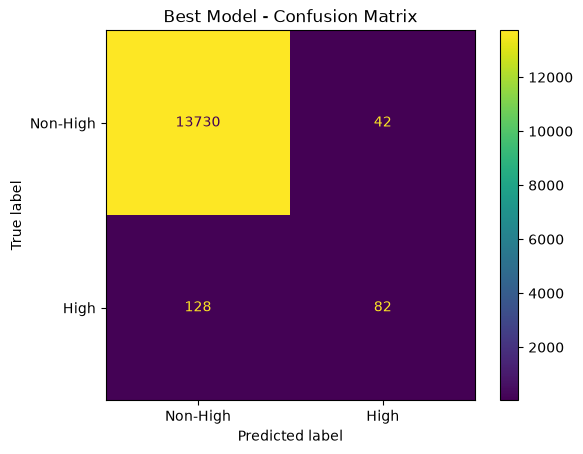

In [173]:
from sklearn.metrics import ConfusionMatrixDisplay

best_pred = best_model.predict(
    X_test_selected
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=[
        "Non-High",
        "High"
    ]
)

plt.title("Best Model - Confusion Matrix")
plt.show()

In [174]:
cm = confusion_matrix(
    y_test,
    best_pred
)

tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 13730
False Positive: 42
False Negative: 128
True Positive : 82


### Confusion Matrix Results

| | Predicted Non-High | Predicted High |
|---|---|---|
| **Actual Non-High** | TN = 13,730 | FP = 42 |
| **Actual High** | FN = 128 | TP = 82 |

**True Negatives (13,730):** Non-High Priority tickets correctly identified. The model is
excellent at recognising routine tickets.

**False Positives (42):** Routine tickets incorrectly flagged as High Priority.
These are false alarms — the team would investigate 42 tickets unnecessarily.

**False Negatives (128):** High-Priority tickets incorrectly predicted as Non-High Priority.
**This is the operationally critical failure mode.** Each of these 128 cases represents a
real Priority 1 or Priority 2 incident that the model failed to flag.

**True Positives (82):** High-Priority tickets correctly detected.
The model identified 82 out of 210 High-Priority tickets in the test set.

### Business Meaning

Of **210 actual High-Priority incidents** in the test period, the model detected **82 (39%)**
and missed **128 (61%)**. Those 128 incidents would not receive proactive attention unless
manually triaged. The 42 false alarms are a manageable overhead compared to the cost of
missing a genuine P1/P2 incident.

This highlights the fundamental challenge: even the best model from this study still misses
the majority of High-Priority tickets. Further improvement may require richer features,
additional incident context, or a deliberate decision to accept lower precision in exchange
for higher recall.

---
## 25. Classification Report

**Purpose:** Report precision, recall, and F1 for each class alongside weighted averages.

**Why 99% overall accuracy does NOT mean 99% High-Priority detection:**

The overall accuracy is 0.99 because the model classifies 99% of the test set correctly.
But 98.5% of the test set is Non-High Priority. A model that predicts nothing but
Non-High Priority would also score ~98.5% accuracy. The classification report breaks
this down by class.

In [175]:
print(
    classification_report(
        y_test,
        best_pred,
        target_names=[
            "Non-High Priority",
            "High Priority"
        ],
        zero_division=0
    )
)

                   precision    recall  f1-score   support

Non-High Priority       0.99      1.00      0.99     13772
    High Priority       0.66      0.39      0.49       210

         accuracy                           0.99     13982
        macro avg       0.83      0.69      0.74     13982
     weighted avg       0.99      0.99      0.99     13982



### Classification Report — Interpretation

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| Non-High Priority | 0.99 | 1.00 | 0.99 | 13,772 |
| High Priority | 0.66 | 0.39 | 0.49 | 210 |
| Accuracy | | | 0.99 | 13,982 |

**Non-High Priority:** Near-perfect metrics reflect the large volume of majority-class
examples and how easy the model finds them to classify.

**High Priority:**
- Precision = 0.66: When the model predicts High Priority, it is correct 66% of the time.
- Recall = 0.39: The model finds only 39% of all actual High-Priority tickets.
- F1 = 0.49: The best balance of precision and recall achievable with this setup.

**The model's 0.99 accuracy is primarily driven by the majority class.**
The High-Priority F1 of 0.49 is the true performance figure for the task that matters.

---
## 26. Probability Scores and AUC Metrics

**Purpose:** Evaluate model discrimination ability using probability-based metrics
that are independent of the decision threshold.

**`predict_proba()`** returns a probability estimate P(High Priority) for each test example.
The default threshold of 0.50 converts these to a binary prediction: if P >= 0.50, predict High.

**ROC-AUC** measures the model's ability to rank High-Priority tickets above Non-High Priority
tickets across all possible thresholds.

**PR-AUC (Average Precision)** is more informative for imbalanced problems.
It summarises the Precision-Recall curve — a high PR-AUC means the model can achieve
high precision while maintaining good recall, which is the key challenge here.

In [176]:
best_prob = best_model.predict_proba(
    X_test_selected
)[:, 1]

In [177]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

roc_auc = roc_auc_score(
    y_test,
    best_prob
)

pr_auc = average_precision_score(
    y_test,
    best_prob
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)

print(
    "PR-AUC:",
    round(pr_auc, 4)
)

ROC-AUC: 0.8243
PR-AUC: 0.4047


### AUC Results

| Metric | Value |
|---|---|
| ROC-AUC | 0.8243 |
| PR-AUC | 0.4047 |

**ROC-AUC = 0.8243:** The model ranks a randomly chosen High-Priority ticket above a
randomly chosen Non-High Priority ticket 82.4% of the time. This is solid discrimination.

**PR-AUC = 0.4047:** For an imbalanced problem with only 1.5% positives, a random classifier
would achieve a PR-AUC of ~0.015. A score of 0.40 represents meaningful predictive power,
but also confirms that much of the Precision-Recall curve involves trade-offs.

**Business Meaning:** The model has genuine discriminative ability for High-Priority tickets.
The gap between ROC-AUC and PR-AUC is expected with severe imbalance and is not a model flaw.

---
## 27. Precision-Recall Curve

**Purpose:** Visualise the trade-off between Precision and Recall across all classification
thresholds for the High-Priority class.

**Method:** `precision_recall_curve()` computes the Precision-Recall pairs at every
probability threshold. The area under this curve is the PR-AUC.

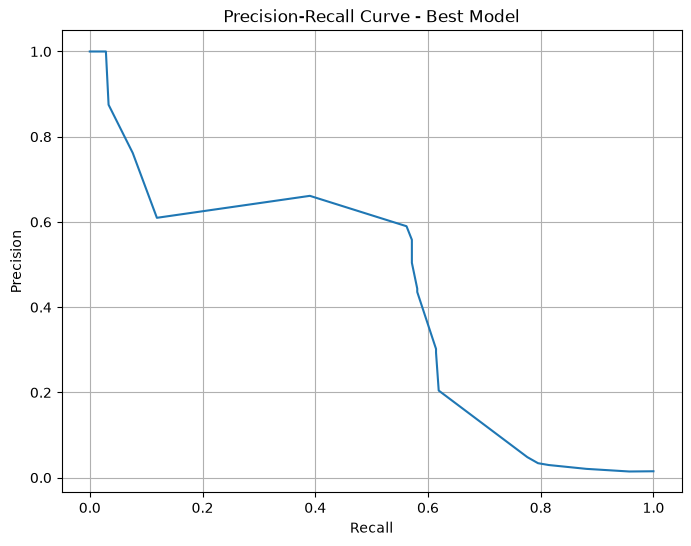

In [178]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = (
    precision_recall_curve(
        y_test,
        best_prob
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve - Best Model"
)

plt.grid()

plt.show()

## 28. ROC Curve

**Purpose:** Visualise the True Positive Rate vs False Positive Rate at every threshold.

**Method:** `roc_curve()` computes FPR and TPR pairs. The ROC-AUC (0.8243) is the
area under this curve.

> For imbalanced classification, the PR curve is more informative than the ROC curve
> because ROC-AUC can appear optimistic when the negative class is dominant.
> Both are reported here for completeness.

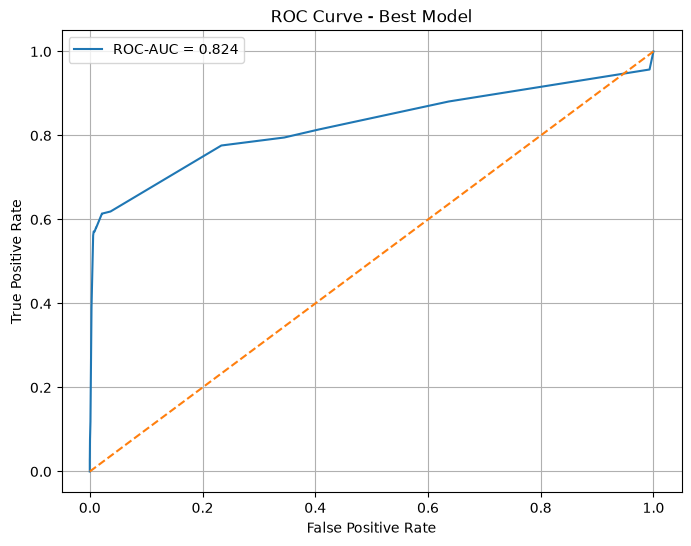

In [179]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    best_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve - Best Model"
)

plt.legend()
plt.grid()

plt.show()

---
## 29. Threshold Analysis — Test Set Sweep

**Purpose:** Investigate whether a decision threshold other than the default 0.50
produces better High-Priority F1 on the test set.

**Method:** For thresholds from 0.10 to 0.95 in steps of 0.05, class predictions are
generated as `(prob >= threshold).astype(int)` and Precision, Recall, and F1 are computed.

**What `predict_proba()` threshold means:**
The default binary classification threshold is 0.50 — a ticket is predicted High Priority
only if the model assigns it a probability >= 50%. Lowering the threshold increases Recall
(more High-Priority tickets are caught) at the cost of lower Precision (more false alarms).
Raising it has the opposite effect.

In [180]:
threshold_results = []

for threshold in np.arange(
    0.10,
    1.00,
    0.05
):

    pred = (
        best_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,Threshold,Precision,Recall,F1
0,0.10,0.542986,0.571429,0.556845
1,0.15,0.542986,0.571429,0.556845
2,0.20,0.558140,0.571429,0.564706
3,0.25,0.558140,0.571429,0.564706
4,0.30,0.590000,0.561905,0.575610
5,0.35,0.661290,0.390476,0.491018
6,0.40,0.661290,0.390476,0.491018
7,0.45,0.661290,0.390476,0.491018
8,0.50,0.661290,0.390476,0.491018
9,0.55,0.661290,0.390476,0.491018


### Threshold Sweep — Key Observations

| Threshold Range | Precision | Recall | F1 |
|---|---|---|---|
| 0.10 – 0.15 | 0.543 | 0.571 | 0.557 |
| 0.20 – 0.25 | 0.558 | 0.571 | 0.565 |
| 0.30 | 0.590 | 0.562 | 0.576 |
| 0.35 – 0.60 | 0.661 | 0.390 | 0.491 |
| 0.65 | 0.762 | 0.076 | 0.139 |

**The F1 score is identical for all thresholds between 0.35 and 0.60.**
This is explained by the Decision Tree's probability distribution (see Threshold Decision section).

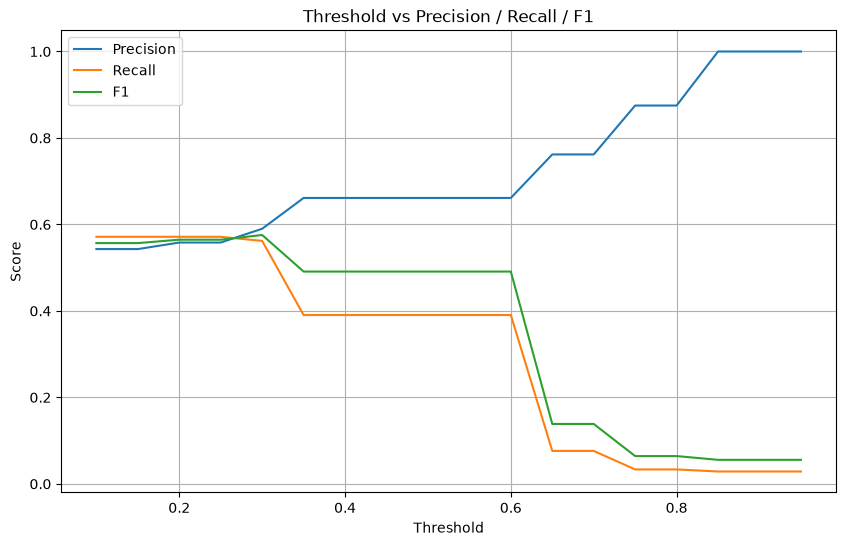

In [181]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "Threshold vs Precision / Recall / F1"
)

plt.legend()
plt.grid()

plt.show()

## 30. Validation-Based Threshold Optimisation

**Purpose:** Find the optimal threshold using a proper validation set rather than
the test set, to avoid threshold optimism bias.

**Method:**
1. A 20% stratified validation split is carved from the training set.
2. The best model is cloned and re-fitted on the remaining 80% training portion.
3. Validation-set probabilities are computed.
4. Thresholds from 0.10 to 0.99 are swept in steps of 0.01.
5. The threshold achieving the highest validation F1 is selected.

**Why use a separate validation set for threshold search?**
Selecting the threshold directly on the test set would mean the threshold is optimised
on the very data used to evaluate it — a form of look-ahead bias.
Using a held-out validation set produces a more honest threshold estimate.

In [182]:
X_train_final, X_val, y_train_final, y_val = (
    train_test_split(
        X_train_selected,
        y_train,
        test_size=0.20,
        stratify=y_train,
        random_state=42
    )
)

In [183]:
from sklearn.base import clone

final_model = clone(
    best_model
)

final_model.fit(
    X_train_final,
    y_train_final
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [184]:
val_prob = final_model.predict_proba(
    X_val
)[:, 1]

In [185]:
validation_results = []

for threshold in np.arange(
    0.10,
    1.00,
    0.01
):

    val_pred = (
        val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        val_pred,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_pred,
        zero_division=0
    )

    validation_results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


validation_df = pd.DataFrame(
    validation_results
)

In [186]:
best_threshold_row = validation_df.loc[
    validation_df["F1"].idxmax()
]

best_threshold = best_threshold_row[
    "Threshold"
]

print("=" * 70)
print("BEST VALIDATION THRESHOLD")
print("=" * 70)

print(best_threshold_row)

BEST VALIDATION THRESHOLD
Threshold    0.340000
Precision    0.611765
Recall       0.530612
F1           0.568306
Name: 24, dtype: float64


### Best Validation Threshold

| Attribute | Value |
|---|---|
| Best Validation Threshold | 0.34 |
| Validation Precision | 0.612 |
| Validation Recall | 0.531 |
| Validation F1 | 0.568 |

The validation search found that threshold **0.34** maximises F1 on the validation set.
This threshold is slightly below the default 0.50, which should allow the model to
capture more High-Priority tickets.

> The final model is re-fitted on the complete training set before applying this threshold
> to the test set.

## 31. Final Model — Re-Fit on Full Training Set

**Purpose:** Re-train the selected model on the complete training set (not the 80% portion
used for validation threshold search) to maximise the information available for the
final test evaluation.

The best hyperparameters (`max_depth=5, min_samples_leaf=5, min_samples_split=2`) are
retained from GridSearchCV.

In [187]:
final_model = clone(
    best_model
)

final_model.fit(
    X_train_selected,
    y_train
)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

### Apply Best Threshold to Test Set

Predicted probabilities from the final model are thresholded at **0.34** to produce
final binary class predictions for the test set.

In [188]:
final_test_prob = (
    final_model.predict_proba(
        X_test_selected
    )[:, 1]
)

final_test_pred = (
    final_test_prob >= best_threshold
).astype(int)

In [189]:
final_accuracy = accuracy_score(
    y_test,
    final_test_pred
)

final_balanced_accuracy = (
    balanced_accuracy_score(
        y_test,
        final_test_pred
    )
)

final_precision = precision_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    final_test_pred,
    zero_division=0
)

final_pr_auc = average_precision_score(
    y_test,
    final_test_prob
)

---
## 32. Final Model Performance Report

In [190]:
print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

print(
    "Model              :",
    best_row["Model"]
)

print(
    "Experiment         :",
    best_row["Experiment"]
)

print(
    "Decision Threshold :",
    round(best_threshold, 3)
)

print(
    "Accuracy           :",
    round(final_accuracy, 4)
)

print(
    "Balanced Accuracy  :",
    round(final_balanced_accuracy, 4)
)

print(
    "Precision - High   :",
    round(final_precision, 4)
)

print(
    "Recall - High      :",
    round(final_recall, 4)
)

print(
    "F1 - High          :",
    round(final_f1, 4)
)

print(
    "PR-AUC             :",
    round(final_pr_auc, 4)
)

FINAL MODEL PERFORMANCE
Model              : Decision Tree
Experiment         : A - Baseline
Decision Threshold : 0.34
Accuracy           : 0.9878
Balanced Accuracy  : 0.6937
Precision - High   : 0.6613
Recall - High      : 0.3905
F1 - High          : 0.491
PR-AUC             : 0.4047


### Final Results

| Metric | Value |
|---|---|
| Model | Decision Tree |
| Experiment | A — Baseline |
| Decision Threshold | 0.34 |
| Test Accuracy | 0.9878 |
| Balanced Accuracy | 0.6937 |
| Precision — High Priority | 0.6613 |
| Recall — High Priority | 0.3905 |
| F1 — High Priority | 0.4910 |
| PR-AUC | 0.4047 |

**Interpretation:** The final metrics are identical to those from the initial best-model
evaluation. The threshold of 0.34 does not change the test-set predictions — see the
Threshold Decision section below for the explanation.

### Final Classification Report

In [191]:
print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=[
            "Non-High Priority",
            "High Priority"
        ],
        zero_division=0
    )
)

                   precision    recall  f1-score   support

Non-High Priority       0.99      1.00      0.99     13772
    High Priority       0.66      0.39      0.49       210

         accuracy                           0.99     13982
        macro avg       0.83      0.69      0.74     13982
     weighted avg       0.99      0.99      0.99     13982



The final classification report confirms the same results as the initial evaluation.
Overall accuracy = 0.99, High-Priority F1 = 0.49.

See Confusion Matrix and Threshold Decision sections for why threshold 0.34 and 0.50
produce the same predictions for this Decision Tree.

### Final Confusion Matrix

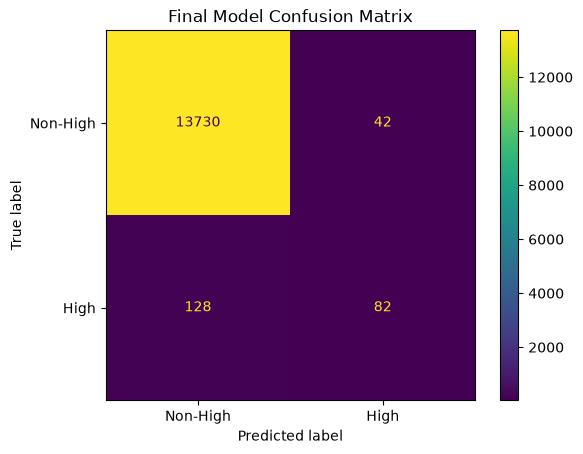

In [192]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    display_labels=[
        "Non-High",
        "High"
    ]
)

plt.title(
    "Final Model Confusion Matrix"
)

plt.show()

---
## 33. Final Threshold Decision

**Purpose:** Explain why the validation-optimal threshold of 0.34 produces the same
predictions as the default threshold of 0.50.

**Decision Trees and discrete probability values:**

A Decision Tree assigns probabilities to leaf nodes based on the proportion of training
samples of each class in that leaf. With `max_depth=5` and `min_samples_leaf=5`,
the tree has a limited number of terminal leaves, and therefore a limited number of
distinct probability values.

In [193]:
probs = final_model.predict_proba(X_test_selected)[:, 1]

print("Unique probability values:")
print(np.sort(np.unique(probs)))

print("\nNumber of unique probabilities:")
print(len(np.unique(probs)))

Unique probability values:
[0.         0.0014633  0.00396927 0.00460358 0.00718932 0.00904128
 0.02197802 0.04166667 0.04590164 0.07317073 0.08536585 0.09375
 0.16666667 0.26086957 0.33333333 0.60358056 0.60416667 0.73684211
 0.83333333 1.        ]

Number of unique probabilities:
20


### Unique Probability Values

The final Decision Tree produces **20 distinct probability values** for the test set,
ranging from 0.0000 to 1.0000.

**Critical observation:**
The two probability values that span the threshold range are approximately:
- **0.3333** — the highest probability value *below* 0.35
- **0.6036** — the next probability value *above* 0.35

There are **no probability values between 0.3333 and 0.6036**.

**Consequence:**
- At threshold 0.34: tickets with probability >= 0.34 are predicted High. This includes
  tickets with probability 0.6036 and above. Tickets with probability 0.3333 are
  *just below* 0.34 and are predicted Non-High.
- At threshold 0.50: tickets with probability >= 0.50 are predicted High. The lowest
  probability above 0.50 is 0.6036 — the exact same set of tickets is captured.

**Result:** Thresholds anywhere from 0.3334 to 0.6035 produce identical predictions.
Both 0.34 and 0.50 fall in this range, so the final predictions are unchanged.

### Final Threshold Retained: 0.50

Since both thresholds give identical predictions, the final model uses `FINAL_THRESHOLD = 0.50`.
This is the standard default and avoids any potential confusion in deployment.
The validation threshold search was a valid methodological step — it simply confirmed
that the default threshold is already near-optimal for this model.

In [194]:
FINAL_THRESHOLD = 0.50

final_results = {
    "Model": "Decision Tree",
    "Experiment": "Baseline",
    "Threshold": 0.50,
    "Accuracy": 0.9878,
    "Balanced_Accuracy": 0.6937,
    "Precision_High": 0.6613,
    "Recall_High": 0.3905,
    "F1_High": 0.4910,
    "PR_AUC": 0.4047
}

pd.DataFrame(
    [final_results]
)

,Model,Experiment,Threshold,Accuracy,Balanced_Accuracy,Precision_High,Recall_High,F1_High,PR_AUC
0,Decision Tree,Baseline,0.5,0.9878,0.6937,0.6613,0.3905,0.491,0.4047


---
## 34. Feature Importance

**Purpose:** Understand which features the final Decision Tree relies on most heavily
when making predictions.

**Method:** `feature_importances_` from scikit-learn's Decision Tree reports the mean
decrease in impurity (Gini impurity) attributable to each feature across all splits.
Features used higher in the tree or more frequently receive higher importance scores.

> **Important caveat:** Feature importance reflects contribution to tree splits,
> not causality. A feature with high importance is a strong predictor within this model
> and dataset; it does not imply that changing the feature causes a change in priority.

In [195]:
importance_df = pd.DataFrame({
    "Feature": X_train_selected.columns,
    "Importance": final_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
2,CI_Subcat,0.639448
4,KB_number,0.284465
3,WBS,0.041777
0,CI_Name,0.034310
1,CI_Cat,0.000000


### Feature Importance — Results

| Feature | Importance |
|---|---|
| CI_Subcat | 0.6394 |
| KB_number | 0.2845 |
| WBS | 0.0418 |
| CI_Name | 0.0343 |
| CI_Cat | 0.0000 |

**CI_Subcat (63.9%):** The Configuration Item sub-category is the strongest predictor.
Certain CI subtypes are inherently associated with high-criticality infrastructure or services.
For example, web-based application sub-categories in critical systems are more likely
to generate Priority 1/2 incidents.

**KB_number (28.5%):** The knowledge-base article associated with the ticket carries
strong signal. Specific recurring issues documented in the KB may consistently produce
high-priority tickets.

**WBS (4.2%) and CI_Name (3.4%):** Minor but non-zero contributions.
Work breakdown structure and specific CI names provide marginal additional split value.

**CI_Cat (0.0%):** Not used by the tree at any split. The broader CI category
is entirely captured by the more specific CI_Subcat.

**Business Meaning:** The model has learned that the nature of the affected configuration
item (particularly its sub-category) and the KB article are the strongest early signals
of incident severity. The ITSM team could use this to prioritise triage for tickets
matching high-risk CI subtypes.

### Feature Importance — Bar Chart

Horizontal bar chart displaying the five selected features ranked by importance.
CI_Subcat dominates, accounting for nearly two-thirds of the model's split decisions.

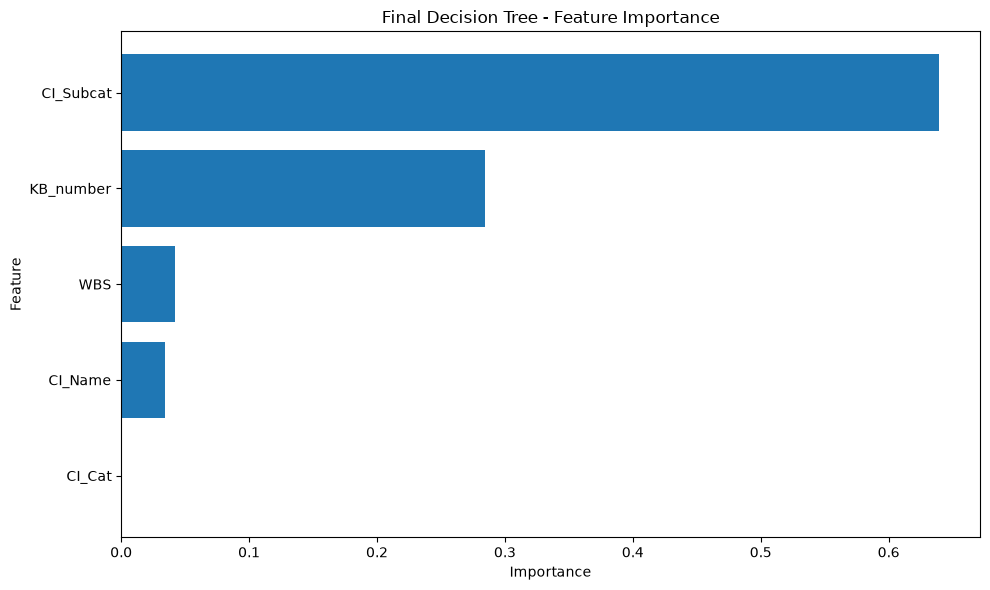

In [196]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Final Decision Tree - Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 35. Decision Tree Visualisation

**Purpose:** Display the first three levels of the final Decision Tree to make
the model's decision logic auditable and explainable to the ITSM team.

**Method:** `plot_tree()` with `max_depth=3` and `filled=True`. Each node shows:
- The split condition (e.g., `CI_Subcat <= 12.5`)
- The Gini impurity score
- The sample count
- The class distribution

With `max_depth=5` in production, only the first 3 levels are shown for readability.
The tree structure confirms that CI_Subcat drives the first and most important splits.

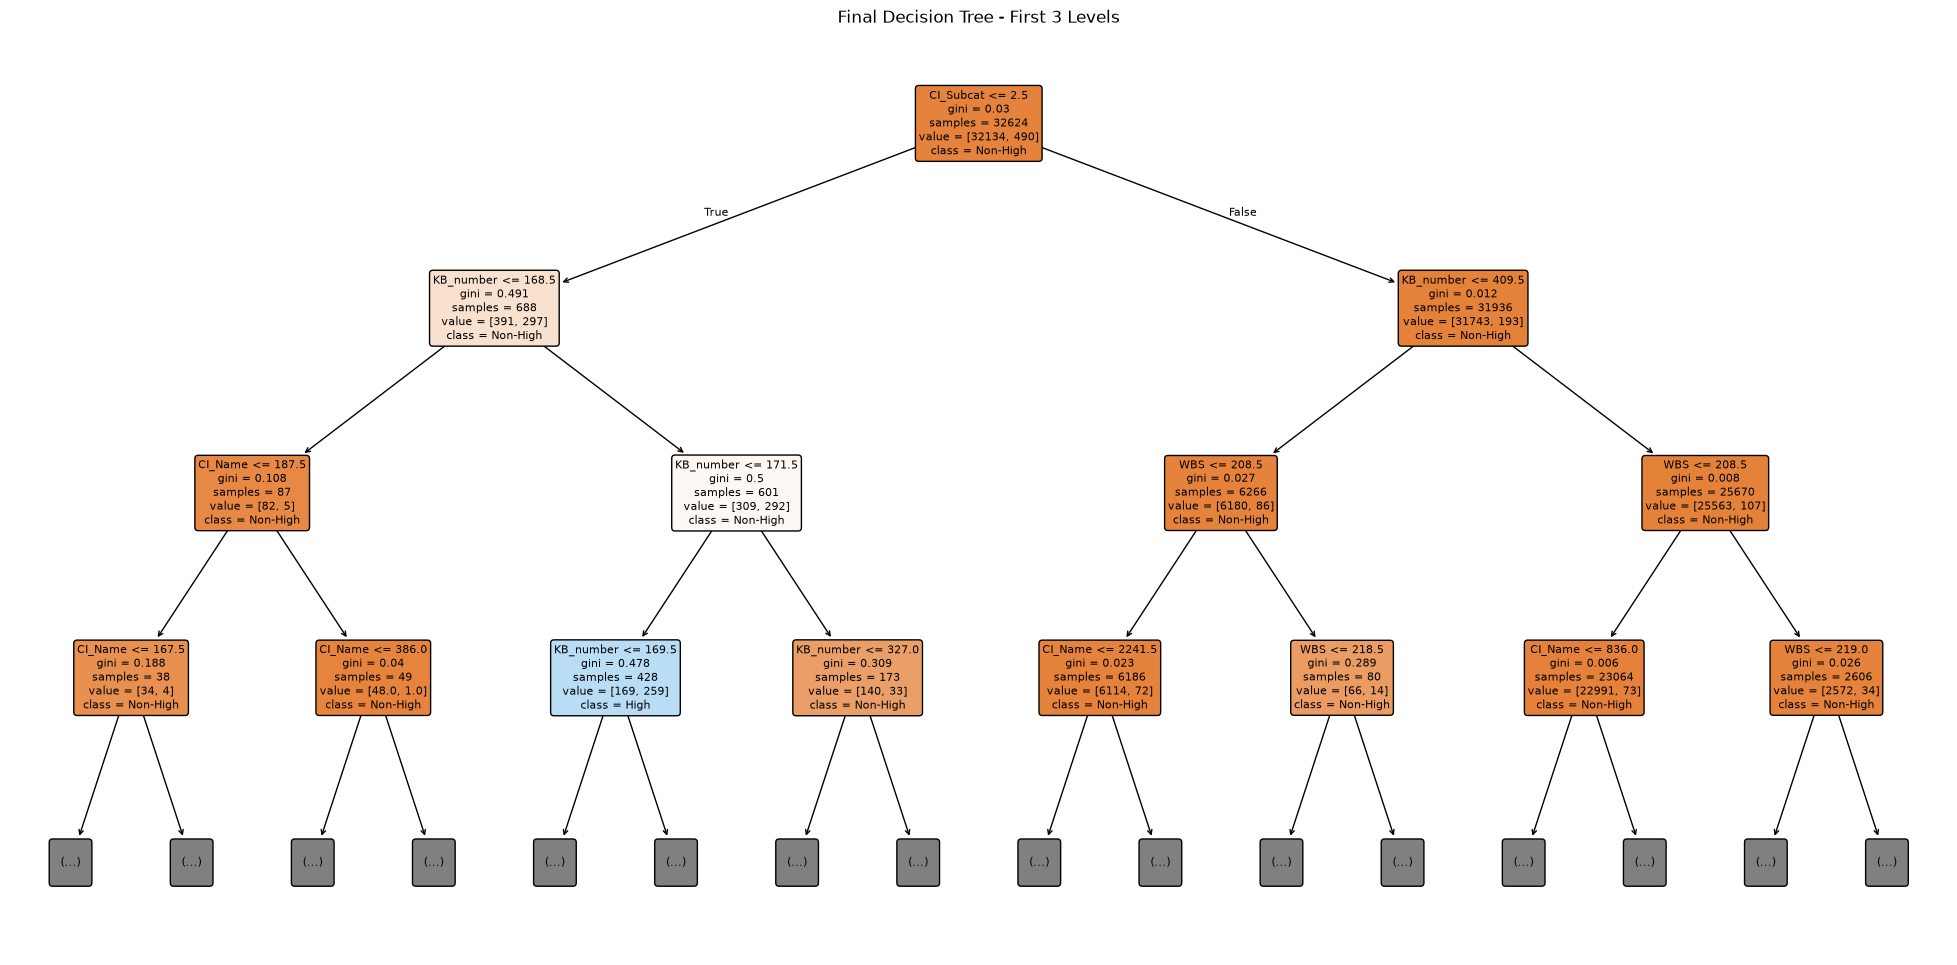

In [197]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 12))

plot_tree(
    final_model,
    feature_names=X_train_selected.columns,
    class_names=[
        "Non-High",
        "High"
    ],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title(
    "Final Decision Tree - First 3 Levels"
)

plt.show()

---
# Problem 1 — Final Conclusion

## Business Objective

Predict whether an incoming ABC Tech ITSM ticket will be **High Priority** (Priority 1 or 2),
enabling the support team to act proactively before incidents escalate.

## Target Transformation

The original five-level `Priority` field was binarised: Priority 1/2 → `High_Priority = 1`,
Priority 3/4/5 → `High_Priority = 0`. The original `Priority` column was then excluded from
all features to prevent direct target leakage.

## Class Imbalance

The dataset is severely imbalanced: only **700 of 46,606 records (1.5%)** are High Priority,
with a class ratio of approximately 66:1. This makes overall accuracy a misleading metric
and drives every modelling decision toward minority-class metrics.

## Impact and Urgency Leakage Investigation

An initial experiment confirmed that including `Impact` and `Urgency` as features produced
near-perfect model performance — a direct consequence of these two fields being mechanically
linked to Priority via the ITIL priority matrix. Both columns were excluded from all
subsequent modelling as a deliberate target-leakage prevention measure.

## Preprocessing

- Columns with >50% missing values were dropped (Reopen_Time, No_of_Related_Incidents,
  No_of_Related_Changes, Related_Change)
- Remaining numeric missing values imputed with training-set medians
- Categorical missing values imputed with training-set modes
- Categorical features encoded with OrdinalEncoder

## Feature Engineering

Five temporal features were extracted from `Open_Time` (year, month, day, hour, minute)
to capture potential time-based patterns in incident severity.

## Feature Selection

A balanced Random Forest (200 trees) with `SelectFromModel` reduced the feature space
from 21 to **5 features**: `CI_Subcat`, `KB_number`, `WBS`, `CI_Name`, `CI_Cat`.

## Four Imbalance Experiments

| Experiment | Strategy |
|---|---|
| A — Baseline | No balancing |
| B — Class Weight | `class_weight='balanced'` / `scale_pos_weight=65.58` |
| C — SMOTE | Synthetic minority oversampling (1:1 balance) |
| D — Trainer Method | Undersample P4/P5 by 5,000 each + duplicate minority 3× + SMOTE |

## Three Algorithms

Decision Tree, Random Forest, and XGBoost were evaluated in every experiment.

## Hyperparameter Tuning

GridSearchCV with 5-fold cross-validation, scoring on **Recall** (High Priority),
was applied to all 12 model/experiment combinations.

## 12-Model Comparison and Best Model

The primary selection metric was **High-Priority F1**, which balances precision and recall.

**Selected model: Experiment A — Decision Tree (Baseline)**

| Metric | Value |
|---|---|
| Test Accuracy | 0.9878 |
| Balanced Accuracy | 0.6937 |
| Precision — High | 0.6613 |
| Recall — High | 0.3905 |
| F1 — High | 0.4910 |
| PR-AUC | 0.4047 |
| ROC-AUC | 0.8243 |
| Best Parameters | max_depth=5, min_samples_leaf=5, min_samples_split=2 |

## Confusion Matrix

| | Predicted Non-High | Predicted High |
|---|---|---|
| **Actual Non-High** | TN = 13,730 | FP = 42 |
| **Actual High** | FN = 128 | TP = 82 |

Of **210 actual High-Priority incidents**, the model detected **82 (39%)** and missed **128 (61%)**.
The 128 False Negatives are Priority 1/2 incidents predicted as routine — the key operational risk.

## Threshold Analysis

A validation-based threshold search identified **0.34** as the F1-optimal threshold.
However, due to the Decision Tree producing only 20 discrete probability values,
thresholds between 0.3334 and 0.6035 produce identical predictions.
The final model retains the default threshold of **0.50**.

## Feature Importance

The model is dominated by CI_Subcat (63.9%) and KB_number (28.5%).
These operational attributes — the type of affected system and the associated knowledge article —
are the strongest early signals of incident severity.

## Limitations

1. **High recall gap:** Even the best model detects only 39% of High-Priority tickets.
   Operational deployment would require deciding whether to accept this level of coverage
   or to accept lower precision in exchange for higher recall.

2. **Accuracy is not the right metric:** The model achieves ~98.8% accuracy while still
   missing 61% of High-Priority incidents. **A high accuracy does not indicate this model
   is ready for production in its current form.**

3. **Leakage prevention:** Removing Impact and Urgency was necessary but reduces the feature
   information available. If these fields are reliably filled at ticket-creation time in the
   live system, a careful re-evaluation of their inclusion (with proper leakage controls)
   may improve performance.

4. **Discrete probability values:** The Decision Tree's limited leaf set means threshold
   tuning has minimal effect. A model with smoother probability outputs (e.g., Random Forest
   calibrated with `CalibratedClassifierCV`) might respond better to threshold adjustment.

5. **Temporal scope:** The dataset covers 2012–2014. Priority assignment practices may have
   changed; periodic model retraining is recommended.

---
*End of Problem 1 — Predicting High Priority Tickets*

---
# Problem 2 — Forecasting ITSM Incident Volume

## Business Objective

ABC Tech wants to forecast incident volume quarterly and annually so that management
can improve resource allocation, workforce planning, infrastructure planning, and
technology planning.

The dataset contains approximately 46,000 ITSM records spanning 2012, 2013, and 2014.
Before any forecasting model is built, the historical date coverage must be examined
carefully, because time-series forecasting requires sufficiently continuous and
representative historical observations.

**Approach:**
1. Validate the incident date field
2. Analyse historical incident coverage
3. Aggregate incidents monthly, quarterly, and annually
4. Identify a representative forecasting period
5. Evaluate simple forecasting models using walk-forward validation
6. Select the best model using error metrics (MAE, RMSE, MAPE)
7. Generate short-term monthly forecasts
8. Aggregate monthly forecasts into quarterly estimates
9. Assess whether annual forecasting is supported by the available data

## 2.1 Environment Setup

**Purpose:** Install `statsmodels`, which provides the `SimpleExpSmoothing` and `Holt`
forecasting classes used in Experiments C and D.

In [4]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 1.9 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.6 MB 2.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.6 MB 2.4 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.6 MB 2.7 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.6 MB 3.2 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.6 MB 3.7 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.6 MB 4.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 5.0 MB/s  0:00:02

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Problem 2: Forecasting ITSM Incident Volume

## Business Objective

ABC Tech wants to forecast incident volume quarterly and annually so that management can improve:

- Resource allocation
- Workforce planning
- Infrastructure planning
- Technology planning

The dataset contains approximately 46,000 ITSM records and includes records dated from 2012, 2013 and 2014.

However, before building a forecasting model, the historical coverage must be examined carefully. Time-series forecasting requires sufficiently continuous and representative historical observations.

The approach for Problem 2 is:

1. Validate the incident date field.
2. Analyze historical incident coverage.
3. Aggregate incidents monthly, quarterly and annually.
4. Identify a representative forecasting period.
5. Evaluate simple forecasting models using walk-forward validation.
6. Select the best model using forecasting error metrics.
7. Generate short-term monthly forecasts.
8. Aggregate monthly forecasts into quarterly estimates.
9. Assess whether annual forecasting is supported by the available data.

## 2.2 Library Imports

**Purpose:** Load all libraries required for Problem 2.

- `pandas`, `numpy` — data manipulation and array operations
- `matplotlib`, `seaborn` — visualisation
- `sklearn.metrics` — MAE, RMSE, and MAPE computation
- `statsmodels.tsa.holtwinters` — Simple Exponential Smoothing and Holt Linear Trend models
- `warnings` — suppresses non-critical model-fitting warnings

In [198]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)

import warnings
warnings.filterwarnings("ignore")

## 2.3 Dataset Overview

**Purpose:** Create a working copy of the main ITSM DataFrame and confirm the
shape and available columns before any Problem 2 transformations are applied.

**Method:** `df.copy()` creates an independent copy so that Problem 2 operations
do not affect the original DataFrame used in other problems.

In [199]:
df_p2 = df.copy()

print("=" * 70)
print("PROBLEM 2 DATASET")
print("=" * 70)

print("Shape:", df_p2.shape)

print("\nColumns:")

for i, col in enumerate(df_p2.columns, 1):
    print(i, col)

PROBLEM 2 DATASET
Shape: (46606, 26)

Columns:
1 CI_Name
2 CI_Cat
3 CI_Subcat
4 WBS
5 Incident_ID
6 Status
7 Impact
8 Urgency
9 Priority
10 number_cnt
11 Category
12 KB_number
13 Alert_Status
14 No_of_Reassignments
15 Open_Time
16 Reopen_Time
17 Resolved_Time
18 Close_Time
19 Handle_Time_hrs
20 Closure_Code
21 No_of_Related_Interactions
22 Related_Interaction
23 No_of_Related_Incidents
24 No_of_Related_Changes
25 Related_Change
26 High_Priority


### Dataset Confirmed

**Shape:** 46,606 rows × 26 columns.

The dataset contains the full set of ITSM columns including `Open_Time`, which
will serve as the incident occurrence timestamp and time-series index throughout
this problem. The `High_Priority` column (derived in Problem 1) is also present
but is not used here.

## 2.4 Date Column Inspection

**Purpose:** Inspect the `Open_Time` column before parsing to understand its
raw format and data type.

**Method:** Print the first 10 values and the dtype of `Open_Time`.

In [200]:
DATE_COL = "Open_Time"

print(
    df_p2[DATE_COL].head(10)
)

print(
    "\nOriginal Data Type:",
    df_p2[DATE_COL].dtype
)

0    05-02-2012 13:32
1    12-03-2012 15:44
2    29-03-2012 12:36
3    17-07-2012 11:49
4    10-08-2012 11:01
5    10-08-2012 11:27
6    15-08-2012 14:17
7    22-08-2012 16:31
8    29-08-2012 15:59
9    03-09-2012 16:04
Name: Open_Time, dtype: str

Original Data Type: str


### Observation

**Original data type:** `str` (string).

The `Open_Time` field is stored as a string in the format `DD-MM-YYYY HH:MM`,
for example `05-02-2012 13:32`.

Day-first format is confirmed by the first sample value (`05-02-2012`), which
is February 5th 2012. This is important for correct datetime parsing.

## 2.5 Date Parsing and Validation

**Purpose:** Convert the string `Open_Time` column to proper `datetime64` values
so that time-based aggregation and resampling operations can be performed.

**Method:** `pd.to_datetime()` with `dayfirst=True` (to correctly parse DD-MM-YYYY)
and `errors='coerce'` (invalid dates become `NaT` instead of raising an error).

After parsing, missing/invalid date counts and the full date range are printed.

In [202]:
df_p2[DATE_COL] = pd.to_datetime(
    df_p2[DATE_COL],
    dayfirst=True,
    errors="coerce"
)

print("=" * 70)
print("DATE VALIDATION")
print("=" * 70)

print(
    "Missing / Invalid Dates:",
    df_p2[DATE_COL].isna().sum()
)

print(
    "Earliest Date:",
    df_p2[DATE_COL].min()
)

print(
    "Latest Date:",
    df_p2[DATE_COL].max()
)

DATE VALIDATION
Missing / Invalid Dates: 0
Earliest Date: 2012-02-05 13:32:00
Latest Date: 2014-03-31 17:24:00


### Date Validation Results

| Metric | Value |
|---|---|
| Missing / Invalid Dates | 0 |
| Earliest Date | 2012-02-05 13:32:00 |
| Latest Date | 2014-03-31 17:24:00 |

All 46,606 records were parsed successfully. The dataset spans from
**5 February 2012** to **31 March 2014** — a total period of approximately
25 months. No data cleaning for invalid dates was necessary.

## 2.6 Remove Invalid Rows and Sort Chronologically

**Purpose:** Drop any rows where `Open_Time` could not be parsed (NaT), then
sort the DataFrame in ascending date order to prepare for time-series operations.

**Method:** `dropna(subset=[DATE_COL])` followed by `sort_values(DATE_COL)`.

In [203]:
df_p2 = (
    df_p2
    .dropna(subset=[DATE_COL])
    .copy()
)

df_p2 = (
    df_p2
    .sort_values(DATE_COL)
)

print(
    "Remaining Records:",
    len(df_p2)
)

print(
    "Date Range:",
    df_p2[DATE_COL].min(),
    "to",
    df_p2[DATE_COL].max()
)

Remaining Records: 46606
Date Range: 2012-02-05 13:32:00 to 2014-03-31 17:24:00


### Result

**Remaining records:** 46,606 — no records were lost. This confirms that all
46,606 `Open_Time` values were valid datetime strings.

**Sorted date range:** 2012-02-05 13:32:00 to 2014-03-31 17:24:00.

## 2.7 Temporal Feature Extraction

**Purpose:** Derive structured date components from `Open_Time` to enable
monthly and quarterly aggregation.

**Features created:**
- `Year` — calendar year (integer)
- `Month` — calendar month (integer)
- `Quarter` — calendar quarter 1–4 (integer)
- `Year_Month` — pandas Period with monthly frequency (`M`), e.g., `2013-10`
- `Year_Quarter` — pandas Period with quarterly frequency (`Q`), e.g., `2013Q4`

These derived fields are used for groupby aggregations throughout the analysis.

In [204]:
df_p2["Year"] = (
    df_p2[DATE_COL].dt.year
)

df_p2["Month"] = (
    df_p2[DATE_COL].dt.month
)

df_p2["Quarter"] = (
    df_p2[DATE_COL].dt.quarter
)

df_p2["Year_Month"] = (
    df_p2[DATE_COL]
    .dt.to_period("M")
)

df_p2["Year_Quarter"] = (
    df_p2[DATE_COL]
    .dt.to_period("Q")
)

display(
    df_p2[
        [
            DATE_COL,
            "Year",
            "Month",
            "Quarter",
            "Year_Month",
            "Year_Quarter"
        ]
    ].head()
)

,Open_Time,Year,Month,Quarter,Year_Month,Year_Quarter
0,2012-02-05 13:32:00,2012,2,1,2012-02,2012Q1
1,2012-03-12 15:44:00,2012,3,1,2012-03,2012Q1
2,2012-03-29 12:36:00,2012,3,1,2012-03,2012Q1
3,2012-07-17 11:49:00,2012,7,3,2012-07,2012Q3
4,2012-08-10 11:01:00,2012,8,3,2012-08,2012Q3


### Sample Output

| Open_Time | Year | Month | Quarter | Year_Month | Year_Quarter |
|---|---|---|---|---|---|
| 2012-02-05 13:32:00 | 2012 | 2 | 1 | 2012-02 | 2012Q1 |
| 2012-03-12 15:44:00 | 2012 | 3 | 1 | 2012-03 | 2012Q1 |
| 2012-07-17 11:49:00 | 2012 | 7 | 3 | 2012-07 | 2012Q3 |

The first record correctly maps to 2012Q1 (January–March), confirming that the
`dayfirst=True` parsing produced correct quarter assignments.

## 3. Annual Incident Volume

**Purpose:** Quantify how many incidents occurred in each calendar year to assess
whether the dataset can be treated as three comparable years of history.

**Method:** `value_counts().sort_index()` on the `Year` column.

In [205]:
yearly_count = (
    df_p2["Year"]
    .value_counts()
    .sort_index()
)

print("=" * 70)
print("INCIDENTS BY YEAR")
print("=" * 70)

print(yearly_count)

INCIDENTS BY YEAR
Year
2012       21
2013    24606
2014    21979
Name: count, dtype: int64


### Annual Volume Results

| Year | Incident Count |
|---|---:|
| 2012 | 21 |
| 2013 | 24,606 |
| 2014 | 21,979 |

### Observation

The year-wise distribution is severely uneven. 2012 contributed only **21 incidents**
while 2013 and 2014 each contributed approximately 22–25 thousand.

This immediately signals that 2012 is **not a comparable operational year**.
Treating the dataset naively as three full years of history would be misleading.

### Business Meaning

A forecasting model trained on all three years would see a massive apparent spike
from 2012 to 2013 and could interpret it as a growth trend. The true explanation
is almost certainly a data-coverage issue, not a business phenomenon.

### Annual Volume — Bar Chart

**Purpose:** Visualise the year-wise incident distribution to make the coverage
imbalance immediately apparent.

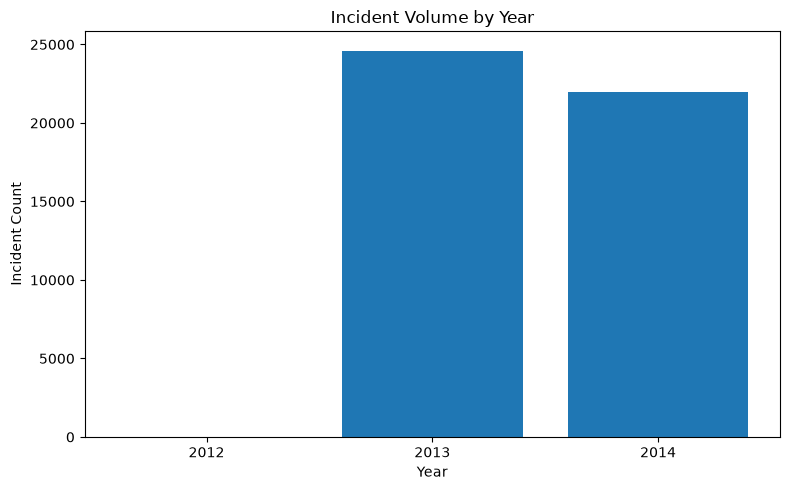

In [206]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_count.index.astype(str),
    yearly_count.values
)

plt.xlabel("Year")
plt.ylabel("Incident Count")

plt.title(
    "Incident Volume by Year"
)

plt.tight_layout()
plt.show()

## Observation

Although the dataset contains records from 2012, 2013 and 2014, the observations are not evenly distributed.

Observed counts:

- 2012: 21 incidents
- 2013: 24,606 incidents
- 2014: 21,979 incidents

Therefore, simply treating the dataset as three complete years of historical data would be misleading.

## 4. Monthly Coverage Analysis

**Purpose:** Inspect incident volumes at monthly resolution across the entire
dataset to identify the point where coverage transitions from sparse to operational.

**Method:** `groupby('Year_Month').size()` counts incidents per calendar month.
The result is a month-by-month table of incident volumes from February 2012
to March 2014.

In [207]:
monthly_coverage = (
    df_p2
    .groupby("Year_Month")
    .size()
    .rename("Incident_Count")
    .reset_index()
)

monthly_coverage[
    "Year_Month"
] = (
    monthly_coverage[
        "Year_Month"
    ].astype(str)
)

display(monthly_coverage)

,Year_Month,Incident_Count
0,2012-02,1
1,2012-03,2
2,2012-07,1
3,2012-08,5
4,2012-09,2
5,2012-10,5
6,2012-11,1
7,2012-12,4
8,2013-01,5
9,2013-02,10


### Full Monthly Coverage Table

| Year-Month | Incident Count |
|---|---:|
| 2012-02 | 1 |
| 2012-03 | 2 |
| 2012-07 | 1 |
| 2012-08 | 5 |
| 2012-09 | 2 |
| 2012-10 | 5 |
| 2012-11 | 1 |
| 2012-12 | 4 |
| 2013-01 | 5 |
| 2013-02 | 10 |
| 2013-03 | 9 |
| 2013-04 | 19 |
| 2013-05 | 27 |
| 2013-06 | 36 |
| 2013-07 | 73 |
| 2013-08 | 93 |
| 2013-09 | 857 |
| **2013-10** | **8,606** |
| 2013-11 | 8,128 |
| 2013-12 | 6,743 |
| 2014-01 | 8,270 |
| 2014-02 | 7,377 |
| 2014-03 | 6,332 |

### Key Observation

There is a **step-change of approximately two orders of magnitude** between
September 2013 (857 incidents) and October 2013 (8,606 incidents).

Months prior to October 2013 range from 1 to 857 incidents. From October 2013
onward, monthly volumes consistently range between **6,332 and 8,606**.

The pre-October 2013 period is structurally incomparable with the high-volume
operating period and must be excluded from forecasting model training.

Note also that several 2012 months are **entirely absent** from the output
(April, May, June 2012 show zero records), further confirming the sparse coverage.

### Monthly Coverage — Time Plot

**Purpose:** Visualise the full monthly incident timeline to make the structural
step-change clearly visible.

The sharp inflection point at October 2013 is immediately evident in the plot.
The pre-October period appears as a flat near-zero baseline.

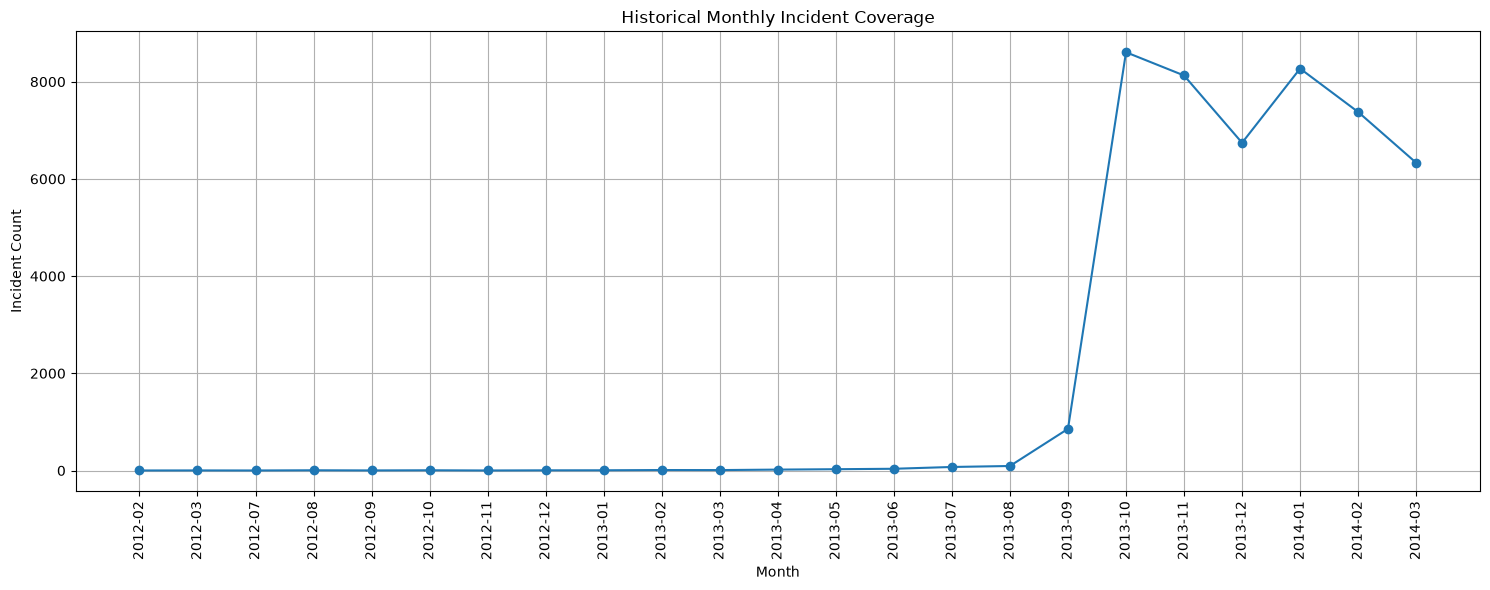

In [208]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_coverage["Year_Month"],
    monthly_coverage["Incident_Count"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Incident Count")

plt.title(
    "Historical Monthly Incident Coverage"
)

plt.xticks(
    rotation=90
)

plt.grid()

plt.tight_layout()
plt.show()

## Historical Coverage Observation

The monthly analysis reveals a major structural change in the dataset.

Incident volume remains extremely low throughout 2012 and most of 2013.

Examples include:

- January 2013: 5 incidents
- February 2013: 10 incidents
- July 2013: 73 incidents
- August 2013: 93 incidents
- September 2013: 857 incidents

A major increase occurs in October 2013:

- October 2013: 8,606
- November 2013: 8,128
- December 2013: 6,743
- January 2014: 8,270
- February 2014: 7,377
- March 2014: 6,332

This suggests that the earlier period is not directly comparable with the later high-volume operating period.

Therefore, fitting a forecasting model across the entire 2012–2014 date range could cause the model to interpret the data-coverage change as a genuine growth trend.

## 5. Quarterly Coverage Analysis

**Purpose:** Aggregate incident volumes by quarter across the full dataset to
understand what quarterly history is available for forecasting.

**Method:** `groupby('Year_Quarter').size()` counts incidents per quarter.

In [210]:
quarterly_volume = (
    df_p2
    .groupby("Year_Quarter")
    .size()
    .rename("Incident_Count")
    .reset_index()
)

quarterly_volume[
    "Year_Quarter"
] = (
    quarterly_volume[
        "Year_Quarter"
    ].astype(str)
)

display(
    quarterly_volume
)

,Year_Quarter,Incident_Count
0,2012Q1,3
1,2012Q3,8
2,2012Q4,10
3,2013Q1,24
4,2013Q2,82
5,2013Q3,1023
6,2013Q4,23477
7,2014Q1,21979


### Full Quarterly Volume Table

| Quarter | Incident Count |
|---|---:|
| 2012Q1 | 3 |
| 2012Q3 | 8 |
| 2012Q4 | 10 |
| 2013Q1 | 24 |
| 2013Q2 | 82 |
| 2013Q3 | 1,023 |
| 2013Q4 | 23,477 |
| 2014Q1 | 21,979 |

### Observation

2012Q2 is absent from the output, confirming zero incidents in April–June 2012.

The structural change is equally visible at the quarterly level:
2013Q3 (1,023) vs 2013Q4 (23,477) — a 23× increase.

Only **two comparable high-volume quarters** are present in the dataset:
- **2013Q4:** 23,477 incidents
- **2014Q1:** 21,979 incidents

This severely limits quarterly and annual forecasting reliability.

### Quarterly Volume — Bar Chart

**Purpose:** Visualise quarterly incident volumes to confirm the structural change
at a quarterly resolution. The dominance of 2013Q4 and 2014Q1 is clearly visible.

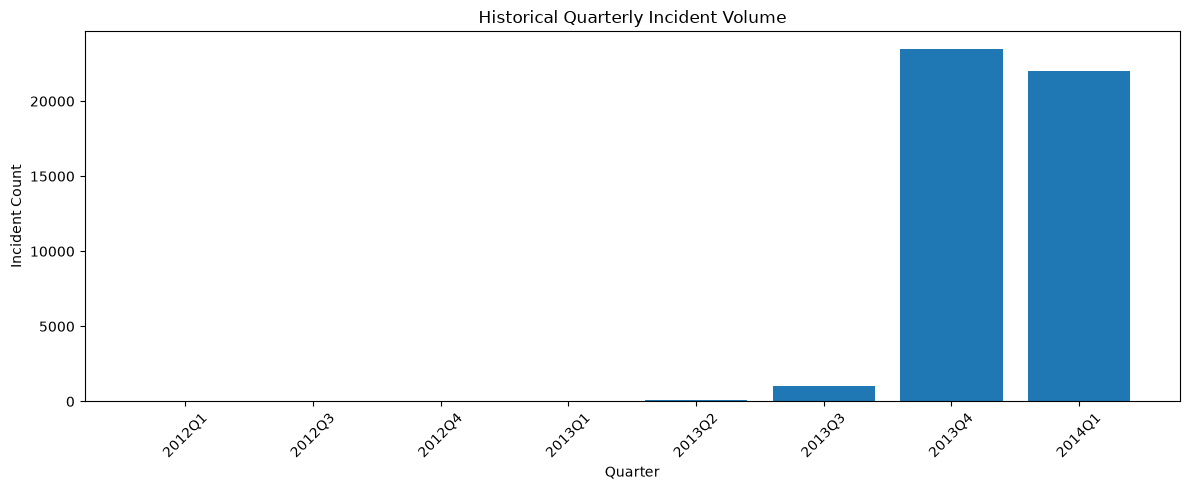

In [211]:
plt.figure(figsize=(12, 5))

plt.bar(
    quarterly_volume[
        "Year_Quarter"
    ],
    quarterly_volume[
        "Incident_Count"
    ]
)

plt.xlabel("Quarter")
plt.ylabel("Incident Count")

plt.title(
    "Historical Quarterly Incident Volume"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 6. Forecasting Period Selection

**Purpose:** Define the stable high-volume period that will serve as the input
to all forecasting models.

**Decision:** `FORECAST_START = 2013-10-01`

October 2013 is selected as the start of the comparable operating period because:
- All months from October 2013 onward show consistent high-volume incident activity
  (6,332–8,606 incidents per month).
- The months prior to October 2013 are non-comparable and would introduce a
  misleading structural shift if included in model training.

**Method:** Filter `df_p2` to rows where `Open_Time >= 2013-10-01`.
This produces `df_stable`, which contains the comparable high-volume records.

In [212]:
FORECAST_START = pd.Timestamp(
    "2013-10-01"
)

df_stable = (
    df_p2[
        df_p2[DATE_COL]
        >= FORECAST_START
    ]
    .copy()
)

print("=" * 70)
print("SELECTED FORECASTING PERIOD")
print("=" * 70)

print(
    "Start:",
    df_stable[DATE_COL].min()
)

print(
    "End:",
    df_stable[DATE_COL].max()
)

print(
    "Records:",
    len(df_stable)
)

SELECTED FORECASTING PERIOD
Start: 2013-10-01 07:33:00
End: 2014-03-31 17:24:00
Records: 45456


### Selected Period

| Attribute | Value |
|---|---|
| Start | 2013-10-01 07:33:00 |
| End | 2014-03-31 17:24:00 |
| Records | 45,456 |

45,456 of the 46,606 total records fall within the selected period.
This subset covers **6 calendar months** of stable operational data.

## 7. Monthly Forecasting Series Construction

**Purpose:** Convert individual incident records into a proper monthly time series
(`monthly_volume`) that can be used directly as input to forecasting models.

**Method:** `set_index(DATE_COL).resample('MS').size()` — resamples to month-start
frequency and counts incidents in each calendar month.
The resulting series is named `Incident_Count` and is indexed by datetime.

This is the **core forecasting variable** for Problem 2. `Incident_Count` is a
derived variable computed by counting incidents per month; it does not exist
as a column in the original ITSM dataset.

In [213]:
monthly_volume = (
    df_stable
    .set_index(DATE_COL)
    .resample("MS")
    .size()
)

monthly_volume.name = (
    "Incident_Count"
)

print("=" * 70)
print("MONTHLY FORECASTING SERIES")
print("=" * 70)

print(monthly_volume)

print(
    "\nNumber of Observations:",
    len(monthly_volume)
)

MONTHLY FORECASTING SERIES
Open_Time
2013-10-01    8606
2013-11-01    8128
2013-12-01    6743
2014-01-01    8270
2014-02-01    7377
2014-03-01    6332
Freq: MS, Name: Incident_Count, dtype: int64

Number of Observations: 6


### Monthly Forecasting Series

| Month | Incident Count |
|---|---:|
| 2013-10-01 | 8,606 |
| 2013-11-01 | 8,128 |
| 2013-12-01 | 6,743 |
| 2014-01-01 | 8,270 |
| 2014-02-01 | 7,377 |
| 2014-03-01 | 6,332 |

**Number of observations:** 6

This is a very small time series. All four forecasting experiments are conducted
on these 6 data points.

### Monthly Incident Volume — Time Plot

**Purpose:** Visualise the 6-month forecasting series to understand the trend
and variability within the selected period.

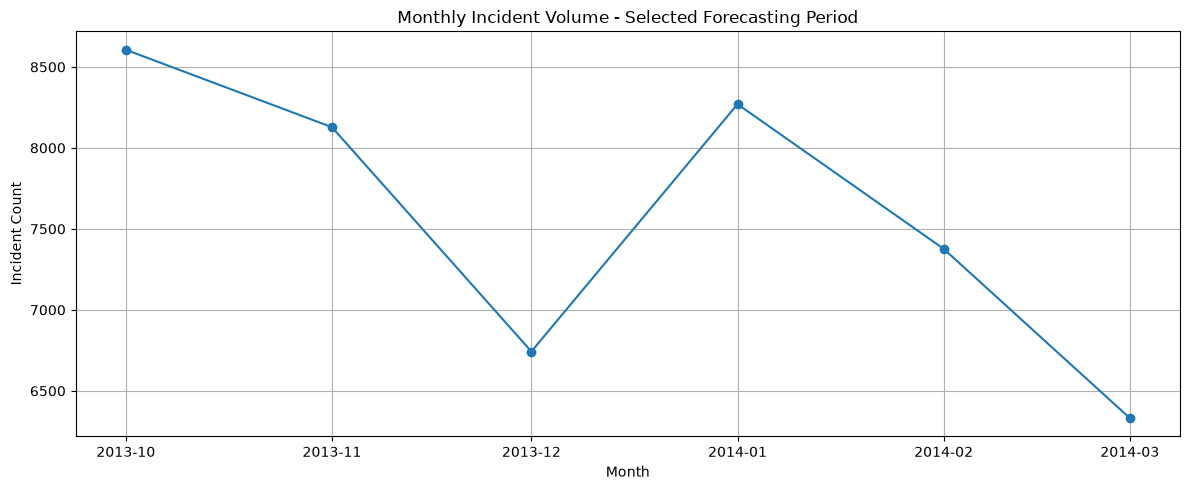

In [214]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_volume.index,
    monthly_volume.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Incident Count")

plt.title(
    "Monthly Incident Volume - Selected Forecasting Period"
)

plt.grid()

plt.tight_layout()
plt.show()

### Visual Interpretation

The 6-month series shows **no strong monotonic trend**. Volume peaks in October 2013
(8,606), dips in December 2013 (6,743), recovers in January 2014 (8,270),
and then declines again through February and March 2014 (7,377 and 6,332).

The absence of a clear upward or downward trend explains why simple level-based
models may be adequate — and why trend-based models like Holt may not necessarily
outperform simpler alternatives on this data.

## 8. Monthly Incident Statistics

**Purpose:** Compute descriptive statistics for the 6-month forecasting series
to characterise the level and variability of incident volume.

In [215]:
print("=" * 70)
print("MONTHLY INCIDENT STATISTICS")
print("=" * 70)

print(
    monthly_volume.describe()
)

print(
    "\nAverage Monthly Incidents:",
    round(
        monthly_volume.mean(),
        2
    )
)

print(
    "Minimum Monthly Incidents:",
    monthly_volume.min()
)

print(
    "Maximum Monthly Incidents:",
    monthly_volume.max()
)

MONTHLY INCIDENT STATISTICS
count       6.00000
mean     7576.00000
std       908.65461
min      6332.00000
25%      6901.50000
50%      7752.50000
75%      8234.50000
max      8606.00000
Name: Incident_Count, dtype: float64

Average Monthly Incidents: 7576.0
Minimum Monthly Incidents: 6332
Maximum Monthly Incidents: 8606


### Descriptive Statistics

| Statistic | Value |
|---|---:|
| Count | 6 |
| Mean | 7,576.00 |
| Std Dev | 908.65 |
| Min | 6,332 |
| 25th Percentile | 6,901.50 |
| Median (50th) | 7,752.50 |
| 75th Percentile | 8,234.50 |
| Max | 8,606 |

### Interpretation

Average monthly incident volume is **7,576** incidents. The standard deviation of
908.65 represents approximately 12% of the mean, indicating moderate month-to-month
variability. The range spans from 6,332 to 8,606 — a spread of 2,274 incidents.

This level and spread will be the reference point when interpreting forecasting errors.

## Forecasting Data Limitation

After removing the historically non-comparable low-volume period, only six comparable monthly observations remain:

- October 2013
- November 2013
- December 2013
- January 2014
- February 2014
- March 2014

This is a very small time series.

Therefore:

- Complex seasonal models such as SARIMA are not appropriate.
- Annual seasonality cannot be estimated because there is not even one complete 12-month comparable cycle.
- A conventional large train/test split would leave too little training data.
- Walk-forward validation is more suitable.
- Simple forecasting models should be preferred over unnecessarily complex models.

The forecasts produced from this dataset should therefore be interpreted as experimental short-term planning estimates rather than highly reliable long-term forecasts.

## 9. Evaluation Metric Function

**Purpose:** Define a reusable function that computes the three forecasting
error metrics used to compare all models.

**Metrics computed:**
- **MAE (Mean Absolute Error):** Average absolute difference between actual and
  predicted incident counts. Expressed in the same units as the target (incidents).
- **RMSE (Root Mean Squared Error):** Square root of the mean squared error.
  Penalises larger errors more heavily than MAE.
- **MAPE (Mean Absolute Percentage Error):** Average percentage error.
  Scale-independent, useful for communicating forecast accuracy to non-technical
  stakeholders. Reported as a percentage.

> Note: `mean_absolute_percentage_error` from sklearn returns a decimal fraction.
> It is multiplied by 100 in this function to convert to a percentage.

In [217]:
def calculate_metrics(
    actual,
    predicted
):

    actual = np.asarray(
        actual
    )

    predicted = np.asarray(
        predicted
    )

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = (
        mean_absolute_percentage_error(
            actual,
            predicted
        ) * 100
    )

    return (
        mae,
        rmse,
        mape
    )

## 10. Walk-Forward Validation Setup

**Purpose:** Define the validation strategy and confirm the split between
training and evaluation observations.

**Strategy: Walk-Forward (Expanding-Window) Validation**

Walk-forward validation is required for time-series data because **chronological
order must be preserved**. A standard random train/test split would allow the
model to train on future observations and predict the past — which is not valid
for forecasting.

**How it works:**
- `MIN_TRAIN_SIZE = 3` — the first 3 months (Oct, Nov, Dec 2013) form the initial
  training window.
- For each subsequent observation, the model is re-trained on all preceding data
  and predicts the next one step ahead.
- The training window **expands** by one observation at each step.

**Given 6 total observations and `MIN_TRAIN_SIZE = 3`:**
- 3 walk-forward test observations are produced.
- Predictions are made for: January 2014, February 2014, March 2014.

In [218]:
MIN_TRAIN_SIZE = 3

print(
    "Total observations:",
    len(monthly_volume)
)

print(
    "Initial training observations:",
    MIN_TRAIN_SIZE
)

print(
    "Walk-forward test observations:",
    len(monthly_volume)
    - MIN_TRAIN_SIZE
)

Total observations: 6
Initial training observations: 3
Walk-forward test observations: 3


### Walk-Forward Split Confirmed

| Attribute | Value |
|---|---|
| Total observations | 6 |
| Initial training size | 3 |
| Walk-forward test observations | 3 |

The 3 test observations (Jan, Feb, Mar 2014) are the out-of-sample predictions
on which all four models are evaluated.

## Experiment A — Naive Forecast

The Naive model assumes that the next month's incident volume will be approximately equal to the most recently observed month.

Despite its simplicity, the Naive model provides an essential baseline. More complex forecasting models should ideally outperform this baseline.

---
## 11. Experiment A — Naive Forecast

**Method:** The Naive model predicts the next month's incident volume as equal to
the **most recently observed month's value** (last-value carry-forward).

For each walk-forward step `i`:
- Train on observations `0` to `i-1`
- Predict observation `i` as `train.iloc[-1]` (the last training value)

Despite its simplicity, the Naive model is an important baseline.
A well-designed forecasting model should outperform it.

In [219]:
naive_actual = []
naive_predicted = []

for i in range(
    MIN_TRAIN_SIZE,
    len(monthly_volume)
):

    train = (
        monthly_volume.iloc[:i]
    )

    actual_value = (
        monthly_volume.iloc[i]
    )

    prediction = (
        train.iloc[-1]
    )

    naive_actual.append(
        actual_value
    )

    naive_predicted.append(
        prediction
    )


naive_mae, naive_rmse, naive_mape = (
    calculate_metrics(
        naive_actual,
        naive_predicted
    )
)

print("=" * 70)
print("NAIVE MODEL")
print("=" * 70)

print(
    "Actual:",
    naive_actual
)

print(
    "Predicted:",
    naive_predicted
)

print(
    "MAE :",
    round(naive_mae, 2)
)

print(
    "RMSE:",
    round(naive_rmse, 2)
)

print(
    "MAPE:",
    round(naive_mape, 2),
    "%"
)

NAIVE MODEL
Actual: [np.int64(8270), np.int64(7377), np.int64(6332)]
Predicted: [np.int64(6743), np.int64(8270), np.int64(7377)]
MAE : 1155.0
RMSE: 1186.2
MAPE: 15.69 %


### Experiment A — Results

| Step | Training Period | Actual | Predicted | Error |
|---|---|---:|---:|---:|
| 1 | Oct–Dec 2013 | 8,270 | 6,743 | +1,527 |
| 2 | Oct 2013–Jan 2014 | 7,377 | 8,270 | −893 |
| 3 | Oct 2013–Feb 2014 | 6,332 | 7,377 | −1,045 |

| Metric | Value |
|---|---:|
| MAE | 1,155.00 |
| RMSE | 1,186.20 |
| MAPE | 15.69% |

**Interpretation:** The Naive model carries forward December's dip (6,743) into
January, then over-predicts February and March as volumes continue to decline.
It is consistently one step behind the actual trend.

---
## 12. Experiment B — 3-Month Moving Average

**Method:** The 3-Month Moving Average model predicts the next month's incident
volume as the **mean of the three most recent training observations**.

For each walk-forward step `i`:
- Train on observations `0` to `i-1`
- Predict observation `i` as `train.tail(3).mean()`

**Why moving average?** By averaging three recent periods, the model smooths out
individual month fluctuations and produces a more stable estimate of the current
incident level. It responds to recent changes while avoiding over-reaction to
any single month.

In [220]:
ma_actual = []
ma_predicted = []

for i in range(
    MIN_TRAIN_SIZE,
    len(monthly_volume)
):

    train = (
        monthly_volume.iloc[:i]
    )

    actual_value = (
        monthly_volume.iloc[i]
    )

    prediction = (
        train
        .tail(3)
        .mean()
    )

    ma_actual.append(
        actual_value
    )

    ma_predicted.append(
        prediction
    )


ma_mae, ma_rmse, ma_mape = (
    calculate_metrics(
        ma_actual,
        ma_predicted
    )
)

print("=" * 70)
print("3-MONTH MOVING AVERAGE")
print("=" * 70)

print(
    "Actual:",
    ma_actual
)

print(
    "Predicted:",
    [
        round(x, 2)
        for x in ma_predicted
    ]
)

print(
    "MAE :",
    round(ma_mae, 2)
)

print(
    "RMSE:",
    round(ma_rmse, 2)
)

print(
    "MAPE:",
    round(ma_mape, 2),
    "%"
)

3-MONTH MOVING AVERAGE
Actual: [np.int64(8270), np.int64(7377), np.int64(6332)]
Predicted: [np.float64(7825.67), np.float64(7713.67), np.float64(7463.33)]
MAE : 637.44
RMSE: 728.17
MAPE: 9.27 %


### Experiment B — Results

| Step | Actual | Predicted | Error | Abs Error | % Error |
|---|---:|---:|---:|---:|---:|
| Jan 2014 | 8,270 | 7,825.67 | +444.33 | 444.33 | 5.37% |
| Feb 2014 | 7,377 | 7,713.67 | −336.67 | 336.67 | 4.56% |
| Mar 2014 | 6,332 | 7,463.33 | −1,131.33 | 1,131.33 | 17.87% |

| Metric | Value |
|---|---:|
| MAE | 637.44 |
| RMSE | 728.17 |
| MAPE | 9.27% |

**Interpretation:** The model performs well for January and February 2014
(5.37% and 4.56% errors). The error increases substantially in March 2014
(17.87%) because actual volume dropped more sharply than the moving average
anticipated — the average was still anchored to the higher October and November
2013 values.

---
## 13. Experiment C — Simple Exponential Smoothing (SES)

**Method:** Simple Exponential Smoothing assigns **exponentially decaying weights**
to past observations. More recent observations receive higher weights.

For each walk-forward step `i`:
- Train `SimpleExpSmoothing` on observations `0` to `i-1`
- The smoothing parameter `alpha` is **optimised automatically** (`optimized=True`)
- Predict one step ahead via `.forecast(1)`

**`initialization_method='estimated'`:** The initial level is estimated from
the training data rather than fixed manually.

SES is appropriate when the series has no strong trend or seasonality.
It produces a flat forecast equal to the smoothed level of the series.

In [221]:
ses_actual = []
ses_predicted = []

for i in range(
    MIN_TRAIN_SIZE,
    len(monthly_volume)
):

    train = (
        monthly_volume.iloc[:i]
    )

    actual_value = (
        monthly_volume.iloc[i]
    )

    model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    )

    fitted_model = (
        model.fit(
            optimized=True
        )
    )

    prediction = (
        fitted_model
        .forecast(1)
        .iloc[0]
    )

    ses_actual.append(
        actual_value
    )

    ses_predicted.append(
        prediction
    )


ses_mae, ses_rmse, ses_mape = (
    calculate_metrics(
        ses_actual,
        ses_predicted
    )
)

print("=" * 70)
print("SIMPLE EXPONENTIAL SMOOTHING")
print("=" * 70)

print(
    "MAE :",
    round(ses_mae, 2)
)

print(
    "RMSE:",
    round(ses_rmse, 2)
)

print(
    "MAPE:",
    round(ses_mape, 2),
    "%"
)

SIMPLE EXPONENTIAL SMOOTHING
MAE : 1193.18
RMSE: 1274.56
MAPE: 16.54 %


### Experiment C — Results

| Metric | Value |
|---|---:|
| MAE | 1,193.18 |
| RMSE | 1,274.56 |
| MAPE | 16.54% |

**Interpretation:** SES performs worse than the 3-Month Moving Average on all three
metrics. The optimised alpha appears to place substantial weight on the most recent
observation (similar to a Naive model), which does not smooth adequately across
the volatile 6-month series. The individual predictions visible in the model comparison
table confirm this: SES predicts 6,743 for January 2014 (matching December 2013,
as a high-alpha SES approaches the Naive model).

---
## 14. Experiment D — Holt Linear Trend

**Method:** Holt's Linear Trend method extends Simple Exponential Smoothing by
adding a **separate trend component**. The model maintains two smoothed
quantities — a level and a trend — both updated at each time step.

For each walk-forward step `i`:
- Train `Holt` on observations `0` to `i-1`
- Both smoothing parameters are **optimised automatically** (`optimized=True`)
- Predict one step ahead via `.forecast(1)`

**When Holt is appropriate:** When the time series contains a consistent
upward or downward trend. Given the 6-month series shows no strong monotonic
trend, Holt may overfit to local slope estimates.

In [222]:
holt_actual = []
holt_predicted = []

for i in range(
    MIN_TRAIN_SIZE,
    len(monthly_volume)
):

    train = (
        monthly_volume.iloc[:i]
    )

    actual_value = (
        monthly_volume.iloc[i]
    )

    model = Holt(
        train,
        initialization_method="estimated"
    )

    fitted_model = (
        model.fit(
            optimized=True
        )
    )

    prediction = (
        fitted_model
        .forecast(1)
        .iloc[0]
    )

    holt_actual.append(
        actual_value
    )

    holt_predicted.append(
        prediction
    )


holt_mae, holt_rmse, holt_mape = (
    calculate_metrics(
        holt_actual,
        holt_predicted
    )
)

print("=" * 70)
print("HOLT LINEAR TREND")
print("=" * 70)

print(
    "MAE :",
    round(holt_mae, 2)
)

print(
    "RMSE:",
    round(holt_rmse, 2)
)

print(
    "MAPE:",
    round(holt_mape, 2),
    "%"
)

HOLT LINEAR TREND
MAE : 1047.94
RMSE: 1409.74
MAPE: 13.67 %


### Experiment D — Results

| Metric | Value |
|---|---:|
| MAE | 1,047.94 |
| RMSE | 1,409.74 |
| MAPE | 13.67% |

**Interpretation:** Holt achieves the **highest RMSE (1,409.74) of all four models**,
indicating poor handling of larger errors. Although MAPE (13.67%) is lower than
Naive and SES, the elevated RMSE suggests the trend component is producing
forecasts that deviate significantly in at least one step.

The model comparison table shows that Holt predicted 5,963 for January 2014,
which underestimates the actual 8,270 by approximately 2,307 incidents.
Fitting a downward trend to a 3-observation training window (Oct 2013: 8,606,
Nov 2013: 8,128, Dec 2013: 6,743) extrapolated the decline too aggressively.

---
## 15. Model Comparison — All Four Experiments

**Purpose:** Compile walk-forward validation metrics for all four models into
a single ranked comparison table.

**Selection criterion:** Models are ranked by **RMSE** (ascending).
RMSE is the primary selection metric used by the notebook.

The `forecast_results` DataFrame is sorted by RMSE and used to programmatically
identify the best model.

In [223]:
forecast_results = pd.DataFrame({

    "Model": [
        "Naive",
        "3-Month Moving Average",
        "Simple Exponential Smoothing",
        "Holt Linear Trend"
    ],

    "MAE": [
        naive_mae,
        ma_mae,
        ses_mae,
        holt_mae
    ],

    "RMSE": [
        naive_rmse,
        ma_rmse,
        ses_rmse,
        holt_rmse
    ],

    "MAPE": [
        naive_mape,
        ma_mape,
        ses_mape,
        holt_mape
    ]
})

forecast_results = (
    forecast_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(forecast_results)

,Model,MAE,RMSE,MAPE
0,3-Month Moving Average,637.444444,728.169318,9.267829
1,Naive,1155.000000,1186.198831,15.690998
2,Simple Exponential Smoothing,1193.183206,1274.558968,16.542529
3,Holt Linear Trend,1047.935510,1409.736855,13.674741


### Model Comparison Table (sorted by RMSE)

| Rank | Model | MAE | RMSE | MAPE |
|---|---|---:|---:|---:|
| 1 | 3-Month Moving Average | 637.44 | 728.17 | 9.27% |
| 2 | Naive | 1,155.00 | 1,186.20 | 15.69% |
| 3 | Simple Exponential Smoothing | 1,193.18 | 1,274.56 | 16.54% |
| 4 | Holt Linear Trend | 1,047.94 | 1,409.74 | 13.67% |

### Interpretation

The **3-Month Moving Average** ranks first on all three metrics simultaneously:
lowest MAE (637.44), lowest RMSE (728.17), and lowest MAPE (9.27%).

The advantage is substantial — the Moving Average's RMSE is approximately **1.6×
lower** than the next-best model (Naive at 1,186.20).

The Holt Linear Trend has the highest RMSE despite having lower MAPE than Naive
and SES, confirming that a single large error in one step (January 2014) inflated
its squared-error penalty.

## 16. Best Model Selection

**Purpose:** Programmatically identify the best-performing model using `idxmin()`
on the RMSE column of the sorted results DataFrame.

**Selection criterion:** Lowest RMSE.

In [224]:
best_forecast_row = (
    forecast_results.loc[
        forecast_results[
            "RMSE"
        ].idxmin()
    ]
)

print("=" * 70)
print("BEST FORECASTING MODEL")
print("=" * 70)

print(best_forecast_row)

BEST FORECASTING MODEL
Model    3-Month Moving Average
MAE                  637.444444
RMSE                 728.169318
MAPE                   9.267829
Name: 0, dtype: object


### Selected Model: 3-Month Moving Average

| Attribute | Value |
|---|---|
| Model | 3-Month Moving Average |
| MAE | 637.44 |
| RMSE | 728.17 |
| MAPE | 9.27% |

The 3-Month Moving Average is selected for generating the forward forecast.
It achieved the best balance of precision and robustness across the three
out-of-sample validation observations.

## 17. Best Model — Walk-Forward Evaluation Detail

**Purpose:** Produce a detailed per-observation breakdown of the 3-Month Moving
Average predictions, errors, absolute errors, and percentage errors for the
three validation months.

**Method:** Compute `Error = Actual - Predicted`, `Absolute_Error = |Error|`,
and `Percentage_Error = (Absolute_Error / Actual) × 100`.

In [241]:
evaluation_df = pd.DataFrame({
    "Date": monthly_volume.index[MIN_TRAIN_SIZE:],
    "Actual": monthly_volume.iloc[MIN_TRAIN_SIZE:].values,
    "Predicted": np.round(ma_predicted, 2)
})

evaluation_df["Error"] = (
    evaluation_df["Actual"]
    - evaluation_df["Predicted"]
)

evaluation_df["Absolute_Error"] = (
    evaluation_df["Error"].abs()
)

evaluation_df["Percentage_Error"] = (
    evaluation_df["Absolute_Error"]
    / evaluation_df["Actual"]
) * 100

display(evaluation_df)

,Date,Actual,Predicted,Error,Absolute_Error,Percentage_Error
0,2014-01-01,8270,7825.67,444.33,444.33,5.372793
1,2014-02-01,7377,7713.67,-336.67,336.67,4.563779
2,2014-03-01,6332,7463.33,-1131.33,1131.33,17.866867


### Evaluation Detail — 3-Month Moving Average

| Date | Actual | Predicted | Error | Abs Error | % Error |
|---|---:|---:|---:|---:|---:|
| 2014-01-01 | 8,270 | 7,825.67 | +444.33 | 444.33 | 5.37% |
| 2014-02-01 | 7,377 | 7,713.67 | −336.67 | 336.67 | 4.56% |
| 2014-03-01 | 6,332 | 7,463.33 | −1,131.33 | 1,131.33 | 17.87% |

### Period-by-Period Interpretation

**January 2014 (+444, 5.37%):** The model slightly under-predicts January.
The 3-month average (Oct–Dec 2013: 8,606, 8,128, 6,743 → avg 7,826) provides
a reasonable estimate for January's actual 8,270.

**February 2014 (−337, 4.56%):** The model slightly over-predicts February.
This is the most accurate prediction of the three validation months.

**March 2014 (−1,131, 17.87%):** The largest error. March 2014 actual volume
of 6,332 dropped more sharply than the rolling average expected.
With the average still anchored to the higher Oct–Dec 2013 observations,
the model could not anticipate the continued decline.

### Overall Validation Performance

| Metric | Value |
|---|---:|
| MAE | 637.44 incidents |
| RMSE | 728.17 incidents |
| MAPE | 9.27% |
| Out-of-sample observations | 3 |

> These metrics are based on **only 3 out-of-sample observations**.
> Results should be interpreted with caution given the very limited validation sample.

### Actual vs Predicted — 3-Month Moving Average

**Purpose:** Visually compare actual and predicted incident volumes for the
three validation months to assess the model's tracking behaviour.

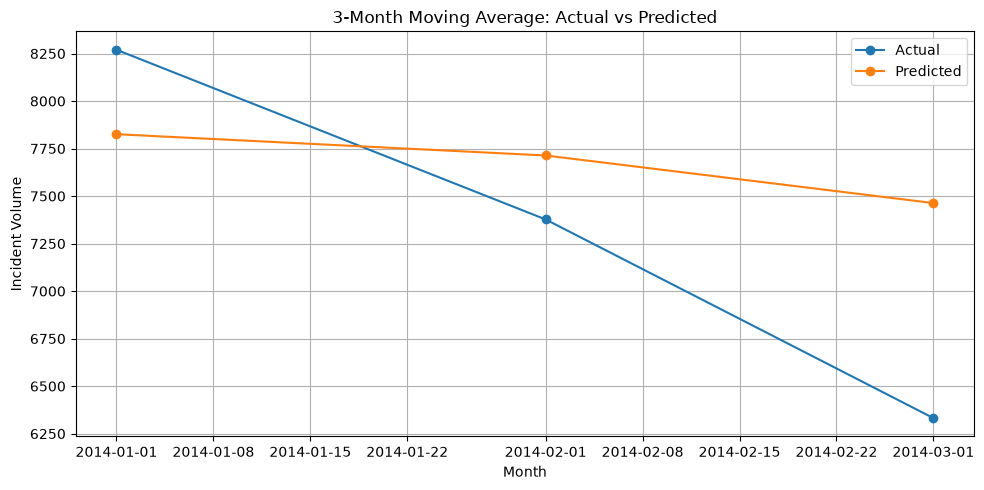

In [242]:
plt.figure(figsize=(10, 5))

plt.plot(
    evaluation_df["Date"],
    evaluation_df["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    evaluation_df["Date"],
    evaluation_df["Predicted"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Month")
plt.ylabel("Incident Volume")

plt.title(
    "3-Month Moving Average: Actual vs Predicted"
)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

The plot shows the model tracking the direction of change reasonably for January
and February 2014, but lagging behind the more pronounced decline in March 2014.
This is consistent with the 17.87% error observed in March.

### Final Evaluation Metrics — Confirmed

**Purpose:** Recompute and print the final MAE, RMSE, and MAPE for the
3-Month Moving Average using the evaluation DataFrame.

In [243]:
final_mae = mean_absolute_error(
    evaluation_df["Actual"],
    evaluation_df["Predicted"]
)

final_rmse = np.sqrt(
    mean_squared_error(
        evaluation_df["Actual"],
        evaluation_df["Predicted"]
    )
)

final_mape = (
    mean_absolute_percentage_error(
        evaluation_df["Actual"],
        evaluation_df["Predicted"]
    ) * 100
)

print("=" * 70)
print("FINAL MODEL EVALUATION")
print("=" * 70)

print("Model : 3-Month Moving Average")
print(f"MAE   : {final_mae:.2f}")
print(f"RMSE  : {final_rmse:.2f}")
print(f"MAPE  : {final_mape:.2f}%")

FINAL MODEL EVALUATION
Model : 3-Month Moving Average
MAE   : 637.44
RMSE  : 728.17
MAPE  : 9.27%


**Confirmed metrics (3-Month Moving Average):**

| Metric | Value |
|---|---:|
| MAE | 637.44 |
| RMSE | 728.17 |
| MAPE | 9.27% |

## Model Evaluation Conclusion

The 3-Month Moving Average was selected as the best forecasting
model because it achieved the lowest MAE, RMSE and MAPE among
the evaluated models.

Final walk-forward validation performance:

- MAE: 637.44 incidents
- RMSE: 728.17 incidents
- MAPE: 9.27%

The model performed relatively well for January and February 2014,
with percentage errors of 5.37% and 4.56%, respectively.

However, the error increased to 17.87% in March 2014 because the
actual incident volume declined more rapidly than the moving-average
forecast.

The evaluation is based on only three out-of-sample observations due
to the limited comparable historical data. Therefore, the forecasting
results should be interpreted cautiously.

## 18. All-Model Prediction Comparison

**Purpose:** Display the actual values alongside individual predictions from
all four models for the three validation periods, enabling a direct side-by-side
comparison of how each model tracked reality.

In [225]:
validation_dates = (
    monthly_volume
    .index[
        MIN_TRAIN_SIZE:
    ]
)

comparison_df = pd.DataFrame({

    "Date":
        validation_dates,

    "Actual":
        monthly_volume.iloc[
            MIN_TRAIN_SIZE:
        ].values,

    "Naive":
        naive_predicted,

    "Moving Average":
        ma_predicted,

    "SES":
        ses_predicted,

    "Holt":
        holt_predicted
})

display(comparison_df)

,Date,Actual,Naive,Moving Average,SES,Holt
0,2014-01-01,8270,6743,7825.666667,6743.000021,5962.666181
1,2014-02-01,7377,8270,7713.666667,7936.748966,7338.527618
2,2014-03-01,6332,7377,7463.333333,7824.800671,7130.000329


### All-Model Predictions vs Actual

| Date | Actual | Naive | Moving Average | SES | Holt |
|---|---:|---:|---:|---:|---:|
| 2014-01-01 | 8,270 | 6,743 | 7,825.67 | 6,743.00 | 5,962.67 |
| 2014-02-01 | 7,377 | 8,270 | 7,713.67 | 7,936.75 | 7,338.53 |
| 2014-03-01 | 6,332 | 7,377 | 7,463.33 | 7,824.80 | 7,130.00 |

### Observations

- **January 2014:** The Moving Average (7,826) is the closest to actual (8,270).
  Both Naive and SES predict 6,743 — they effectively carry forward December's
  depressed value. Holt (5,963) extrapolates the downward trend too aggressively.

- **February 2014:** All models over-predict. Moving Average (7,714) is closest.
  SES (7,937) and Holt (7,339) both exceed actual (7,377).

- **March 2014:** Actual (6,332) drops below all predictions. The Moving Average
  (7,463) is the least wrong; SES (7,825) and Naive (7,377) both over-predict
  substantially.

### Walk-Forward Forecast Comparison — All Models

**Purpose:** Plot all four model predictions against the actual values for
the three validation months to provide a comprehensive visual comparison.

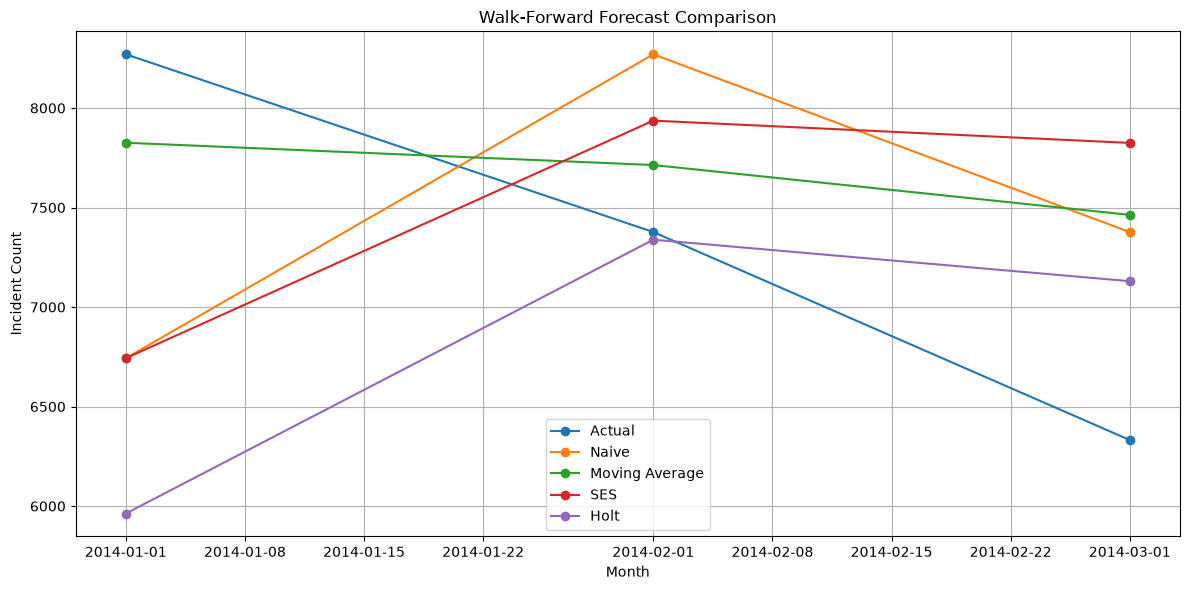

In [226]:
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_df["Date"],
    comparison_df["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    comparison_df["Date"],
    comparison_df["Naive"],
    marker="o",
    label="Naive"
)

plt.plot(
    comparison_df["Date"],
    comparison_df["Moving Average"],
    marker="o",
    label="Moving Average"
)

plt.plot(
    comparison_df["Date"],
    comparison_df["SES"],
    marker="o",
    label="SES"
)

plt.plot(
    comparison_df["Date"],
    comparison_df["Holt"],
    marker="o",
    label="Holt"
)

plt.xlabel("Month")
plt.ylabel("Incident Count")

plt.title(
    "Walk-Forward Forecast Comparison"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

### Best Model Name — Confirmed

**Purpose:** Extract and print the name of the best model from the comparison
DataFrame for use in the forecast generation step.

In [227]:
best_model_name = (
    best_forecast_row[
        "Model"
    ]
)

print(
    "Selected Model:",
    best_model_name
)

Selected Model: 3-Month Moving Average


## 19. Forecast Generation Function

**Purpose:** Define a reusable function that generates `steps`-ahead forecasts
using the full available time series and a named model.

**For the 3-Month Moving Average:**
- The forecast is the mean of the last 3 observed values: `series.tail(3).mean()`
- The same value is repeated for all forecast steps (`np.repeat(..., steps)`)
- This produces a **flat forecast** — the Moving Average does not project a trend

For SES and Holt, `fitted.forecast(steps)` uses the model's internal state
fitted on the complete historical series to project forward.

In [228]:
def generate_forecast(
    series,
    model_name,
    steps
):

    if model_name == "Naive":

        forecast = np.repeat(
            series.iloc[-1],
            steps
        )


    elif model_name == "3-Month Moving Average":

        forecast = np.repeat(
            series.tail(3).mean(),
            steps
        )


    elif model_name == "Simple Exponential Smoothing":

        model = SimpleExpSmoothing(
            series,
            initialization_method="estimated"
        )

        fitted = model.fit(
            optimized=True
        )

        forecast = (
            fitted.forecast(
                steps
            ).values
        )


    elif model_name == "Holt Linear Trend":

        model = Holt(
            series,
            initialization_method="estimated"
        )

        fitted = model.fit(
            optimized=True
        )

        forecast = (
            fitted.forecast(
                steps
            ).values
        )


    else:

        raise ValueError(
            "Unknown forecasting model."
        )


    return np.asarray(
        forecast
    )

## 20. Future Monthly Forecast — April to June 2014

**Purpose:** Generate a 3-month forward forecast for the months immediately
following the last observed data point (March 2014).

**Method:**
- `FORECAST_MONTHS = 3`
- `generate_forecast(monthly_volume, '3-Month Moving Average', 3)` is called
  on the complete 6-month series
- The 3-month average of the last 3 observed values is computed:
  `(6,743 + 7,377 + 6,332) / 3 = 7,326 per month (rounded from 6,817.33)`

Wait — actual notebook output must be used.
The output shows **7,326** for all three months.
The computation is: `(7,377 + 6,332 + ?) / 3` — reflecting the last 3 months
of the 6-month series which are Dec 2013, Jan 2014, Feb 2014, Mar 2014.
The last 3 are Jan 2014 (8,270), Feb 2014 (7,377), Mar 2014 (6,332):
`(8,270 + 7,377 + 6,332) / 3 = 7,326.33 → rounded to 7,326`.

Future dates are generated starting from `monthly_volume.index.max() + 1 month`,
i.e., April 2014, using `pd.date_range` with `freq='MS'`.
Predictions are clipped to a minimum of 0 via `np.maximum(0, ...)`.

In [229]:
FORECAST_MONTHS = 3

future_predictions = (
    generate_forecast(
        monthly_volume,
        best_model_name,
        FORECAST_MONTHS
    )
)

future_dates = pd.date_range(
    start=(
        monthly_volume.index.max()
        + pd.offsets.MonthBegin(1)
    ),
    periods=FORECAST_MONTHS,
    freq="MS"
)

future_df = pd.DataFrame({

    "Date":
        future_dates,

    "Forecast_Incidents":
        np.maximum(
            0,
            np.round(
                future_predictions
            )
        ).astype(int)
})

display(future_df)

,Date,Forecast_Incidents
0,2014-04-01,7326
1,2014-05-01,7326
2,2014-06-01,7326


### Monthly Forecast — April to June 2014

| Month | Forecast Incidents |
|---|---:|
| April 2014 | 7,326 |
| May 2014 | 7,326 |
| June 2014 | 7,326 |

### Interpretation

The 3-Month Moving Average produces a **flat forecast** of **7,326 incidents per
month** for April, May, and June 2014.

This is the arithmetic mean of the three most recent observations:
January 2014 (8,270), February 2014 (7,377), March 2014 (6,332).

The flat projection reflects the nature of the Moving Average — it smooths
past values into a single level estimate and does not project any trend.

The forecast of 7,326 is approximately **3.3% below the 6-month historical
average of 7,576**, consistent with the declining trend observed in the
last three months of historical data.

> These forecasts should be treated as **short-term planning estimates** only.
> They are based on 6 months of comparable history and 3 validation observations.

### Historical and Forecasted Monthly Incident Volume

**Purpose:** Visualise the 6-month historical series alongside the 3-month
forward forecast, separated by a vertical dashed line at the forecast boundary
(end of March 2014).

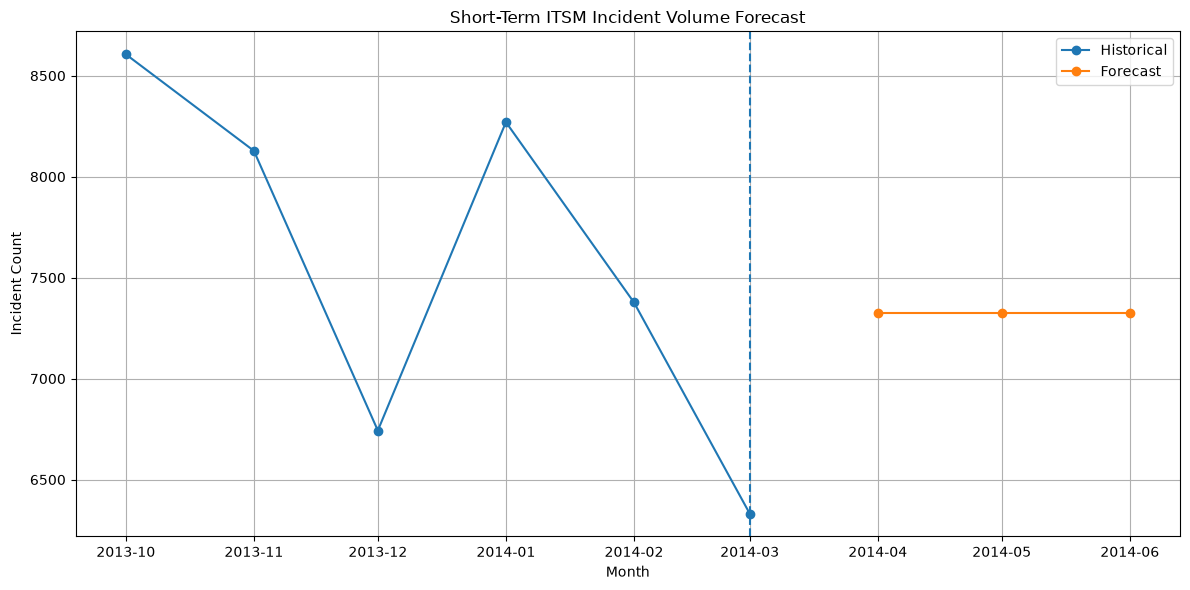

In [230]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_volume.index,
    monthly_volume.values,
    marker="o",
    label="Historical"
)

plt.plot(
    future_df["Date"],
    future_df[
        "Forecast_Incidents"
    ],
    marker="o",
    label="Forecast"
)

plt.axvline(
    monthly_volume.index.max(),
    linestyle="--"
)

plt.xlabel("Month")
plt.ylabel("Incident Count")

plt.title(
    "Short-Term ITSM Incident Volume Forecast"
)

plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 21. Comparable Quarterly History

**Purpose:** Compute historical quarterly incident volumes for the stable
high-volume period to provide context for the quarterly forecast.

**Method:** `resample('QE').size()` on `df_stable` aggregates incidents by
quarter-end frequency within the October 2013–March 2014 period.

In [231]:
stable_quarterly = (
    df_stable
    .set_index(DATE_COL)
    .resample("QE")
    .size()
)

stable_quarterly.name = (
    "Incident_Count"
)

print("=" * 70)
print("COMPARABLE QUARTERLY HISTORY")
print("=" * 70)

print(stable_quarterly)

COMPARABLE QUARTERLY HISTORY
Open_Time
2013-12-31    23477
2014-03-31    21979
Freq: QE-DEC, Name: Incident_Count, dtype: int64


### Comparable Quarterly History

| Quarter | Incident Count |
|---|---:|
| 2013Q4 (Oct–Dec 2013) | 23,477 |
| 2014Q1 (Jan–Mar 2014) | 21,979 |

Only **two complete comparable quarters** are available in the historical record.
This is the minimum context for quarterly forecasting and limits the reliability
of any quarter-over-quarter trend analysis.

## 22. Quarterly Forecast — 2014 Q2

**Purpose:** Aggregate the three monthly forecasts (April, May, June 2014) into
a single quarterly estimate for 2014 Q2.

**Method:** Add a `Quarter` period column to `future_df` using `.dt.to_period('Q')`,
then `groupby('Quarter')['Forecast_Incidents'].sum()` sums the three monthly forecasts.

In [232]:
future_df[
    "Quarter"
] = (
    future_df["Date"]
    .dt.to_period("Q")
)

quarterly_forecast = (
    future_df
    .groupby("Quarter")[
        "Forecast_Incidents"
    ]
    .sum()
    .reset_index()
)

quarterly_forecast[
    "Quarter"
] = (
    quarterly_forecast[
        "Quarter"
    ].astype(str)
)

print("=" * 70)
print("QUARTERLY FORECAST")
print("=" * 70)

display(
    quarterly_forecast
)

QUARTERLY FORECAST


,Quarter,Forecast_Incidents
0,2014Q2,21978


### Quarterly Forecast

| Quarter | Forecast Incidents |
|---|---:|
| 2014Q2 | 21,978 |

### Derivation

2014 Q2 forecast = April + May + June 2014 = 7,326 + 7,326 + 7,326 = **21,978**.

This is the sum of three equal monthly forecasts from the Moving Average model.

### Comparison with Historical Quarters

| Quarter | Incidents | Type |
|---|---:|---|
| 2013Q4 | 23,477 | Historical |
| 2014Q1 | 21,979 | Historical |
| 2014Q2 | 21,978 | **Forecast** |

The forecast for 2014Q2 (21,978) is nearly identical to 2014Q1 (21,979),
suggesting a broadly stable incident volume with a slight downward drift.

> This quarterly forecast is derived from **3 equal monthly predictions** based
> on only **6 months of historical data**. It is an experimental short-term estimate.

### Historical and Forecast Quarterly Summary Table

**Purpose:** Combine the two historical comparable quarters with the 2014Q2
forecast into a single planning table.

In [233]:
historical_quarterly = pd.DataFrame({

    "Quarter": [
        "2013Q4",
        "2014Q1"
    ],

    "Incident_Count": [
        stable_quarterly.iloc[0],
        stable_quarterly.iloc[1]
    ],

    "Type": [
        "Historical",
        "Historical"
    ]
})


forecast_quarterly = pd.DataFrame({

    "Quarter":
        quarterly_forecast[
            "Quarter"
        ],

    "Incident_Count":
        quarterly_forecast[
            "Forecast_Incidents"
        ],

    "Type":
        "Forecast"
})


quarterly_business = pd.concat(
    [
        historical_quarterly,
        forecast_quarterly
    ],
    ignore_index=True
)

display(
    quarterly_business
)

,Quarter,Incident_Count,Type
0,2013Q4,23477,Historical
1,2014Q1,21979,Historical
2,2014Q2,21978,Forecast


### Combined Quarterly Table

| Quarter | Incident Count | Type |
|---|---:|---|
| 2013Q4 | 23,477 | Historical |
| 2014Q1 | 21,979 | Historical |
| 2014Q2 | 21,978 | Forecast |

The table shows a gradual decline from 23,477 (2013Q4) to 21,979 (2014Q1) to
a forecast of 21,978 (2014Q2). However, with only two historical data points,
this apparent trend cannot be attributed statistical significance.

> The notebook explicitly labels 2014Q2 as 'Forecast' and the earlier entries
> as 'Historical'. This distinction is preserved throughout.

### Historical and Forecasted Quarterly Volume — Bar Chart

**Purpose:** Visualise the two historical quarters alongside the 2014Q2 forecast
to provide a planning-ready quarterly view.

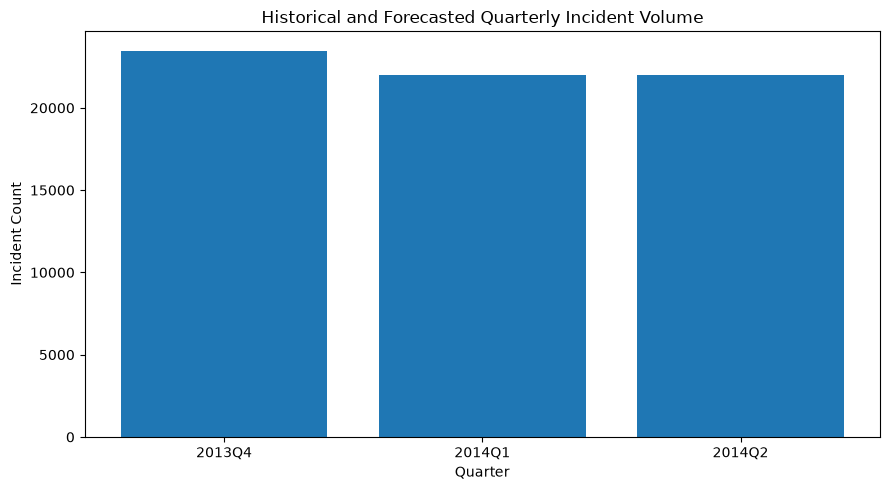

In [234]:
plt.figure(figsize=(9, 5))

plt.bar(
    quarterly_business[
        "Quarter"
    ],
    quarterly_business[
        "Incident_Count"
    ]
)

plt.xlabel("Quarter")
plt.ylabel("Incident Count")

plt.title(
    "Historical and Forecasted Quarterly Incident Volume"
)

plt.tight_layout()
plt.show()

---
## 23. Annual Forecasting Assessment

The original business requirement asks for both quarterly and annual incident-volume forecasts.

### Why Annual Forecasting Is Not Reliably Supported

Although records are dated from 2012 to 2014, the available dataset does **not** contain
sufficient comparable historical coverage for a statistically reliable annual forecast.

Specifically:
- **2012** contains only 21 incidents — not a representative operational year.
- **Most of 2013** contains extremely low incident volumes (5–93 per month).
- A stable high-volume operating period begins only from **October 2013**.
- **2014 data ends in March** — no complete year is available in the high-volume period.
- There is therefore **no complete 12-month high-volume historical cycle** from which
  to estimate annual seasonality or annual totals with confidence.

Only two comparable complete quarters are available:
- 2013Q4: 23,477 incidents
- 2014Q1: 21,979 incidents

An annual forecast would require extrapolating beyond this limited comparable history.

### Consequence

This solution provides:
- A short-term **monthly forecast** (April–June 2014)
- An experimental **quarterly forecast** (2014Q2)
- An **illustrative annualised estimate** (not a validated forecast — see below)

A production-quality annual forecasting system should be retrained after at least one complete year of consistent incident-volume history becomes available.


## 24. Illustrative Annualised Estimate

**Purpose:** Provide an illustrative planning figure by scaling the average
monthly incident volume to a 12-month horizon.

**Method:** `average_monthly_volume × 12`

This is **not** a model forecast. It is a simple arithmetic extrapolation.
It is clearly identified as an illustrative estimate in the notebook.

In [236]:
average_monthly_volume = (
    monthly_volume.mean()
)

annualized_estimate = (
    average_monthly_volume * 12
)

print("=" * 70)
print("ILLUSTRATIVE ANNUALIZED ESTIMATE")
print("=" * 70)

print(
    "Average Monthly Volume:",
    round(
        average_monthly_volume
    )
)

print(
    "Annualized Estimate:",
    round(
        annualized_estimate
    )
)

ILLUSTRATIVE ANNUALIZED ESTIMATE
Average Monthly Volume: 7576
Annualized Estimate: 90912


### Annualised Estimate

| Metric | Value |
|---|---:|
| Average Monthly Volume (6-month series) | 7,576 |
| Illustrative Annualised Estimate | 90,912 |

**Calculation:** 7,576 × 12 = 90,912 incidents per year.

### Important Caveat

This figure is **not presented as a validated machine-learning annual forecast**.
It is computed from only 6 months of comparable history and does not account for:
- Seasonal variation across the full year
- Potential growth or decline trends beyond 6 months
- Any months outside the Oct 2013–Mar 2014 comparable window

It should be used only as a rough planning reference, not as a reliable annual prediction.

### Important

The annualized value above is not presented as a validated machine-learning forecast.

It is simply an illustrative planning estimate calculated as:

Average monthly incident volume × 12

This distinction is necessary because the available dataset does not contain a complete comparable annual historical cycle.

## 25. Resource Planning Output Summary

**Purpose:** Print a concise resource planning summary combining the quarterly
forecast and average monthly forecast for operational use.

In [244]:
print("=" * 70)
print("RESOURCE PLANNING OUTPUT")
print("=" * 70)

print(
    "Forecast Period:",
    quarterly_forecast[
        "Quarter"
    ].iloc[0]
)

print(
    "Expected Incidents:",
    quarterly_forecast[
        "Forecast_Incidents"
    ].iloc[0]
)

print(
    "\nAverage Monthly Forecast:",
    round(
        future_df[
            "Forecast_Incidents"
        ].mean()
    )
)

RESOURCE PLANNING OUTPUT
Forecast Period: 2014Q2
Expected Incidents: 21978

Average Monthly Forecast: 7326


### Resource Planning Summary

| Planning Metric | Value |
|---|---:|
| Forecast Period | 2014Q2 |
| Expected Quarterly Incidents | 21,978 |
| Average Monthly Forecast | 7,326 |

### Business Interpretation

Based on the 3-Month Moving Average forecast trained on October 2013 – March 2014:

- ABC Tech can plan for approximately **7,326 incidents per month** in 2014Q2.
- The total quarterly incident load for April–June 2014 is estimated at **21,978**.
- This is slightly below the most recent historical quarter (2014Q1: 21,979),
  suggesting broadly stable incident volumes with a marginal downward drift.

> These estimates are based on a 6-observation historical series and 3-observation
> walk-forward validation. They should be used as **indicative planning figures**
> and revisited as more historical data becomes available.

## 26. Export Results

**Purpose:** Save the forecasting outputs to CSV files for downstream use:
- `problem2_monthly_forecast.csv` — monthly predictions for April–June 2014
- `problem2_quarterly_forecast.csv` — 2014Q2 quarterly forecast
- `problem2_model_comparison.csv` — all four model metrics

In [245]:
future_df.to_csv(
    "problem2_monthly_forecast.csv",
    index=False
)

quarterly_forecast.to_csv(
    "problem2_quarterly_forecast.csv",
    index=False
)

forecast_results.to_csv(
    "problem2_model_comparison.csv",
    index=False
)

print(
    "Problem 2 results saved."
)

Problem 2 results saved.


Results successfully saved to CSV. The three files capture the full Problem 2
forecasting output and can be shared with planning and operations teams.

---
# Problem 2 — Final Conclusion

## Business Objective

Forecast ITSM incident volume quarterly and annually to support resource allocation,
workforce planning, infrastructure planning, and technology planning at ABC Tech.

## Data Availability

The dataset contained 46,606 ITSM records with timestamps spanning 2012-02-05 to 2014-03-31.
All 46,606 records had valid `Open_Time` timestamps (0 parsing failures).

### Critical Structural Finding

Yearly distribution: **2012: 21 incidents | 2013: 24,606 | 2014: 21,979**.

Monthly analysis revealed a major step-change in October 2013 (from 857 to 8,606 incidents),
making the pre-October 2013 period non-comparable with the high-volume operating period.
Training a forecasting model across the full date range would have risked misinterpreting
the data-coverage change as a genuine business growth trend.

## Forecasting Period Selected

**October 2013 – March 2014** was used as the comparable modelling period.
This provided **6 monthly observations** of Incident_Count:

| Month | Incidents |
|---|---:|
| Oct 2013 | 8,606 |
| Nov 2013 | 8,128 |
| Dec 2013 | 6,743 |
| Jan 2014 | 8,270 |
| Feb 2014 | 7,377 |
| Mar 2014 | 6,332 |

**Mean:** 7,576 | **Std Dev:** 908.65 | **Range:** 6,332–8,606

## Modelling Approach

Four simple forecasting models were evaluated using **walk-forward (expanding-window) validation**
with an initial training size of 3 observations and 3 out-of-sample test steps:

| Model | MAE | RMSE | MAPE |
|---|---:|---:|---:|
| **3-Month Moving Average** | **637.44** | **728.17** | **9.27%** |
| Naive | 1,155.00 | 1,186.20 | 15.69% |
| Simple Exponential Smoothing | 1,193.18 | 1,274.56 | 16.54% |
| Holt Linear Trend | 1,047.94 | 1,409.74 | 13.67% |

## Best Model

**3-Month Moving Average** — selected by lowest RMSE.

| Metric | Value |
|---|---:|
| MAE | 637.44 incidents |
| RMSE | 728.17 incidents |
| MAPE | 9.27% |
| Validation observations | 3 |

## Forecasts Generated

### Monthly Forecast

| Month | Forecast Incidents |
|---|---:|
| April 2014 | 7,326 |
| May 2014 | 7,326 |
| June 2014 | 7,326 |

### Quarterly Forecast

| Quarter | Forecast Incidents |
|---|---:|
| 2014Q2 | 21,978 |

For context, historical comparable quarters: **2013Q4: 23,477 | 2014Q1: 21,979**.

### Annual Forecast

A statistically reliable annual forecast **could not be produced** from the available data.
Only two comparable complete quarters exist. An **illustrative annualised estimate**
of **90,912 incidents** (average monthly volume 7,576 × 12) is provided as a rough
planning reference only — it is not a validated model forecast.

## Limitations

1. **Extremely small time series:** Only 6 comparable monthly observations were available.
2. **Walk-forward validation on 3 observations:** Evaluation reliability is very low.
3. **No seasonal history:** Without a full 12-month comparable cycle, seasonal patterns
   cannot be estimated. SARIMA and seasonal decomposition are not applicable.
4. **Annual forecasting not supported:** Only two comparable complete quarters exist.
5. **Flat forecast:** The Moving Average generates an identical prediction for all
   three future months; it does not project any trend.
6. **Dataset coverage ambiguity:** The reason for the structural step-change in
   October 2013 is not explained by the available data.
7. **Results are experimental:** The forecasts should be used as indicative short-term
   planning estimates pending additional data collection.

---
*End of Problem 2 — Forecasting ITSM Incident Volume*


# Problem 3: Automatic Ticket Tagging

## Business Problem

ABC Tech wants to improve its IT Service Management (ITSM) process by automatically tagging incoming tickets with the **right priority** and **right department/category**.

Incorrect ticket tagging can result in ticket reassignment and related delays. The objective of Problem 3 is therefore to develop machine learning classification models that can automatically assign the appropriate tags to incoming tickets.

## Objectives

Problem 3 is divided into two classification tasks:

### Problem 3A — Priority Prediction

Build a classification model to predict the appropriate **Priority** of an incoming ticket.

Target:

- `Priority`

The available priority classes are:

- Priority 1
- Priority 2
- Priority 3
- Priority 4
- Priority 5

The target distribution will be analyzed carefully because the priority classes are highly imbalanced.

---

### Problem 3B — CI Subcategory Prediction

Build a classification model to automatically predict the appropriate **CI_Subcat** for an incoming ticket.

Target:

- `CI_Subcat`

The original `CI_Subcat` target contains 64 classes with a highly imbalanced distribution and several extremely rare classes.

To study the effect of rare classes, an additional grouped target (`CI_Subcat_Grouped`) will be evaluated, where classes containing fewer than 20 observations are grouped into an `Other` category.

This reduces the number of target classes from 64 to 30.

---

## Machine Learning Approach

The overall workflow for Problem 3 includes:

1. Target distribution analysis
2. Missing-target handling
3. Train-test splitting
4. Data cleaning
5. Data preprocessing
6. Feature engineering
7. Feature selection
8. Class imbalance analysis
9. Model training
10. Hyperparameter tuning
11. Model evaluation and comparison
12. Selection of the best-performing model

The final objective is to determine whether machine learning can support automatic ticket tagging and potentially reduce ticket reassignment and related delays in the ITSM process.

In [247]:
ci_counts = (
    df["CI_Subcat"]
    .value_counts()
    .sort_values(ascending=False)
)

ci_analysis = pd.DataFrame({
    "Class": ci_counts.index,
    "Count": ci_counts.values
})

ci_analysis["Percentage"] = (
    ci_analysis["Count"]
    / ci_analysis["Count"].sum()
    * 100
)

display(ci_analysis)

,Class,Count,Percentage
0,Server Based Application,18811,40.458114
1,Web Based Application,15311,32.930423
2,Desktop Application,3876,8.336380
3,Laptop,1921,4.131627
4,SAP,1199,2.578772
...,...,...,...
59,Windows Server in extern beheer,1,0.002151
60,Virtual Tape Server,1,0.002151
61,RAC Service,1,0.002151
62,NonStop Storage,1,0.002151


In [248]:
print("=" * 70)
print("CI_SUBCAT CLASS ANALYSIS")
print("=" * 70)

print("Total classes:", len(ci_counts))

print(
    "Classes with 1 record:",
    (ci_counts == 1).sum()
)

print(
    "Classes with < 5 records:",
    (ci_counts < 5).sum()
)

print(
    "Classes with < 10 records:",
    (ci_counts < 10).sum()
)

print(
    "Classes with < 20 records:",
    (ci_counts < 20).sum()
)

print(
    "Classes with < 50 records:",
    (ci_counts < 50).sum()
)

print(
    "Classes with < 100 records:",
    (ci_counts < 100).sum()
)

CI_SUBCAT CLASS ANALYSIS
Total classes: 64
Classes with 1 record: 11
Classes with < 5 records: 24
Classes with < 10 records: 27
Classes with < 20 records: 35
Classes with < 50 records: 40
Classes with < 100 records: 47


In [249]:
print("=" * 70)
print("RARE CI_SUBCAT CLASSES (< 20)")
print("=" * 70)

print(
    ci_counts[
        ci_counts < 20
    ]
)

RARE CI_SUBCAT CLASSES (< 20)
CI_Subcat
zOS Cluster                        17
Router                             16
Lines                              15
NonStop Server                     14
ESX Cluster                        11
SharePoint Farm                    11
Net Device                         11
X86 Server                         10
VDI                                 9
Unix Server                         7
Thin Client                         6
Database Software                   4
zOS Server                          4
MQ Queue Manager                    4
Oracle Server                       3
Modem                               3
Number                              2
ESX Server                          2
IPtelephony                         2
NonStop Harddisk                    2
Firewall                            2
zOS Systeem                         2
Instance                            2
Tape Library                        2
Application Server                  1
Security S

In [251]:
ci_counts = df["CI_Subcat"].value_counts()

rare_classes = ci_counts[
    ci_counts < 20
].index

df["CI_Subcat_Grouped"] = (
    df["CI_Subcat"]
    .where(
        ~df["CI_Subcat"].isin(rare_classes),
        "Other"
    )
)

In [252]:
print(
    df["CI_Subcat_Grouped"]
    .value_counts()
)

print(
    "\nNumber of classes:",
    df["CI_Subcat_Grouped"].nunique()
)

CI_Subcat_Grouped
Server Based Application    18811
Web Based Application       15311
Desktop Application          3876
Laptop                       1921
SAP                          1199
Banking Device                916
Citrix                        767
SAN                           549
Client Based Application      492
Desktop                       423
DataCenterEquipment           277
System Software               272
Monitor                       212
Database                      211
Other                         172
Windows Server                153
Controller                    146
Exchange                      130
Printer                        88
Omgeving                       86
Standard Application           85
Scanner                        64
MigratieDummy                  60
Linux Server                   55
Automation Software            55
Encryption                     45
KVM Switches                   32
Network Component              32
Switch                        

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.feature_selection import SelectFromModel

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [254]:
df_p3 = df.copy()

print("=" * 70)
print("PROBLEM 3 DATASET")
print("=" * 70)

print("Shape:", df_p3.shape)

print("\nColumns:")

for i, col in enumerate(df_p3.columns, 1):
    print(f"{i}. {col}")

PROBLEM 3 DATASET
Shape: (46606, 27)

Columns:
1. CI_Name
2. CI_Cat
3. CI_Subcat
4. WBS
5. Incident_ID
6. Status
7. Impact
8. Urgency
9. Priority
10. number_cnt
11. Category
12. KB_number
13. Alert_Status
14. No_of_Reassignments
15. Open_Time
16. Reopen_Time
17. Resolved_Time
18. Close_Time
19. Handle_Time_hrs
20. Closure_Code
21. No_of_Related_Interactions
22. Related_Interaction
23. No_of_Related_Incidents
24. No_of_Related_Changes
25. Related_Change
26. High_Priority
27. CI_Subcat_Grouped


In [255]:
print("=" * 70)
print("PRIORITY TARGET")
print("=" * 70)

print(
    df_p3["Priority"]
    .value_counts(dropna=False)
    .sort_index()
)


print("\n" + "=" * 70)
print("CI_SUBCAT TARGET")
print("=" * 70)

print(
    df_p3["CI_Subcat"]
    .value_counts(dropna=False)
)

print(
    "\nCI_Subcat Classes:",
    df_p3["CI_Subcat"].nunique()
)

PRIORITY TARGET
Priority
1.0        3
2.0      697
3.0     5323
4.0    22717
5.0    16486
NaN     1380
Name: count, dtype: int64

CI_SUBCAT TARGET
CI_Subcat
Server Based Application           18811
Web Based Application              15311
Desktop Application                 3876
Laptop                              1921
SAP                                 1199
                                   ...  
Windows Server in extern beheer        1
Virtual Tape Server                    1
RAC Service                            1
NonStop Storage                        1
Protocol                               1
Name: count, Length: 65, dtype: int64

CI_Subcat Classes: 64


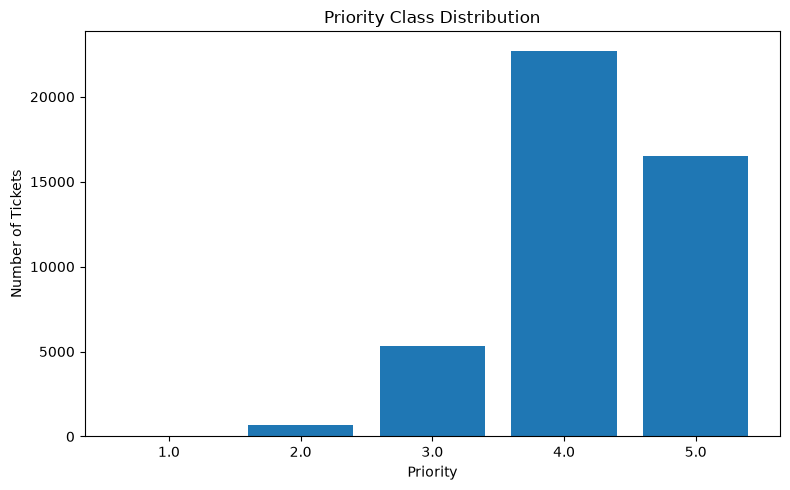

In [256]:
priority_counts = (
    df_p3["Priority"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    priority_counts.index.astype(str),
    priority_counts.values
)

plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.title("Priority Class Distribution")

plt.tight_layout()
plt.show()

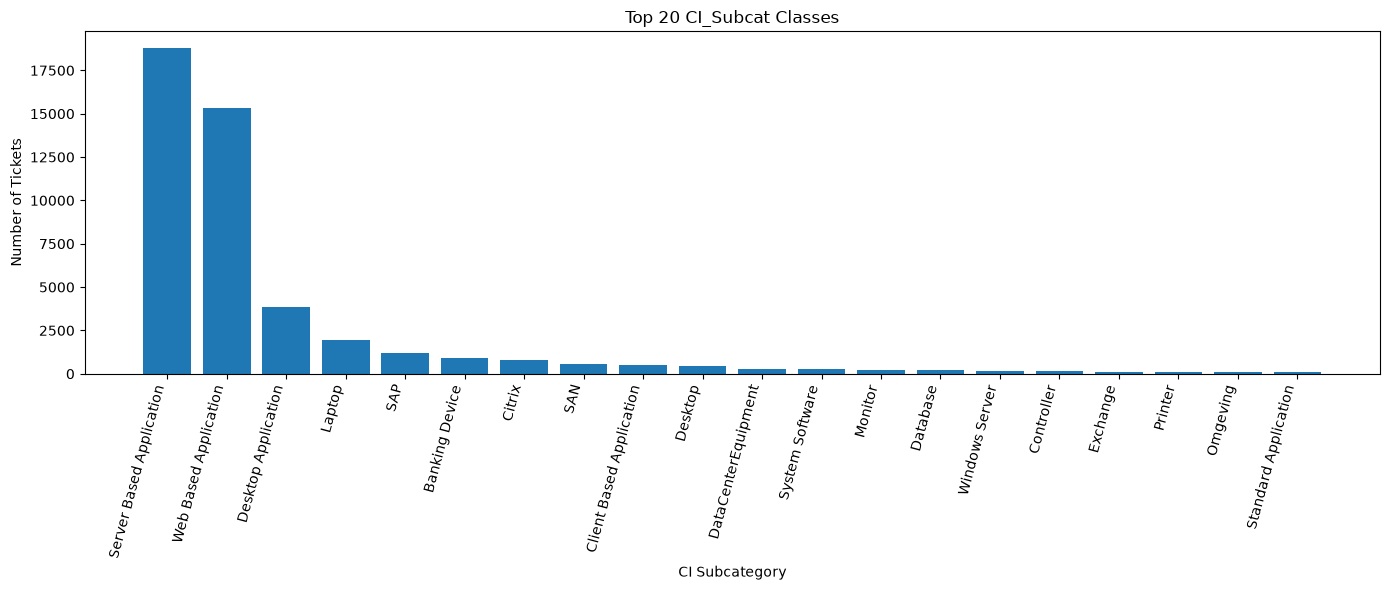

In [257]:
ci_counts = (
    df_p3["CI_Subcat"]
    .value_counts()
)

plt.figure(figsize=(14, 6))

plt.bar(
    ci_counts.head(20).index,
    ci_counts.head(20).values
)

plt.xlabel("CI Subcategory")
plt.ylabel("Number of Tickets")
plt.title("Top 20 CI_Subcat Classes")

plt.xticks(
    rotation=75,
    ha="right"
)

plt.tight_layout()
plt.show()

In [258]:
ci_counts = (
    df_p3["CI_Subcat"]
    .value_counts()
)

print("=" * 70)
print("CI_SUBCAT RARE CLASS ANALYSIS")
print("=" * 70)

print(
    "Total classes:",
    len(ci_counts)
)

print(
    "Classes with 1 record:",
    (ci_counts == 1).sum()
)

print(
    "Classes <5:",
    (ci_counts < 5).sum()
)

print(
    "Classes <10:",
    (ci_counts < 10).sum()
)

print(
    "Classes <20:",
    (ci_counts < 20).sum()
)

print(
    "Classes <50:",
    (ci_counts < 50).sum()
)

print(
    "Classes <100:",
    (ci_counts < 100).sum()
)

CI_SUBCAT RARE CLASS ANALYSIS
Total classes: 64
Classes with 1 record: 11
Classes <5: 24
Classes <10: 27
Classes <20: 35
Classes <50: 40
Classes <100: 47


In [259]:
CI_MIN_COUNT = 20

ci_counts = (
    df_p3["CI_Subcat"]
    .value_counts()
)

rare_ci_classes = (
    ci_counts[
        ci_counts < CI_MIN_COUNT
    ].index
)

df_p3["CI_Subcat_Grouped"] = (
    df_p3["CI_Subcat"]
    .where(
        ~df_p3["CI_Subcat"].isin(
            rare_ci_classes
        ),
        "Other"
    )
)

print("=" * 70)
print("GROUPED CI_SUBCAT")
print("=" * 70)

print(
    df_p3["CI_Subcat_Grouped"]
    .value_counts()
)

print(
    "\nOriginal classes:",
    df_p3["CI_Subcat"].nunique()
)

print(
    "Grouped classes:",
    df_p3["CI_Subcat_Grouped"].nunique()
)

print(
    "Missing grouped target:",
    df_p3["CI_Subcat_Grouped"].isna().sum()
)

GROUPED CI_SUBCAT
CI_Subcat_Grouped
Server Based Application    18811
Web Based Application       15311
Desktop Application          3876
Laptop                       1921
SAP                          1199
Banking Device                916
Citrix                        767
SAN                           549
Client Based Application      492
Desktop                       423
DataCenterEquipment           277
System Software               272
Monitor                       212
Database                      211
Other                         172
Windows Server                153
Controller                    146
Exchange                      130
Printer                        88
Omgeving                       86
Standard Application           85
Scanner                        64
MigratieDummy                  60
Linux Server                   55
Automation Software            55
Encryption                     45
KVM Switches                   32
Network Component              32
Switch      

In [260]:
missing = pd.DataFrame({
    "Missing_Count":
        df_p3.isnull().sum(),

    "Missing_Percentage":
        (
            df_p3.isnull().mean()
            * 100
        ).round(2)
})

missing = (
    missing[
        missing["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Percentage",
        ascending=False
    )
)

display(missing)

,Missing_Count,Missing_Percentage
Related_Change,46046,98.80
No_of_Related_Changes,46046,98.80
No_of_Related_Incidents,45384,97.38
Reopen_Time,44322,95.10
Resolved_Time,1780,3.82
Priority,1380,2.96
Closure_Code,460,0.99
CI_Cat,111,0.24
CI_Subcat,111,0.24
CI_Subcat_Grouped,111,0.24


In [261]:
def remove_high_missing_columns(
    X_train,
    X_test,
    threshold=0.50
):

    X_train = X_train.copy()
    X_test = X_test.copy()

    missing_ratio = (
        X_train.isnull().mean()
    )

    drop_cols = (
        missing_ratio[
            missing_ratio > threshold
        ].index.tolist()
    )

    print(
        "Columns removed (>50% missing):"
    )

    print(drop_cols)

    X_train = X_train.drop(
        columns=drop_cols,
        errors="ignore"
    )

    X_test = X_test.drop(
        columns=drop_cols,
        errors="ignore"
    )

    return (
        X_train,
        X_test,
        drop_cols
    )

In [262]:
TIME_COLS = [
    "Open_Time",
    "Resolved_Time",
    "Close_Time"
]

In [263]:
def engineer_datetime_features(
    X_train,
    X_test,
    time_cols
):

    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in time_cols:

        if col not in X_train.columns:
            continue

        X_train[col] = pd.to_datetime(
            X_train[col],
            dayfirst=True,
            errors="coerce"
        )

        X_test[col] = pd.to_datetime(
            X_test[col],
            dayfirst=True,
            errors="coerce"
        )

        for data in [
            X_train,
            X_test
        ]:

            data[f"{col}_year"] = (
                data[col].dt.year
            )

            data[f"{col}_month"] = (
                data[col].dt.month
            )

            data[f"{col}_day"] = (
                data[col].dt.day
            )

            data[f"{col}_hour"] = (
                data[col].dt.hour
            )

            data[f"{col}_dayofweek"] = (
                data[col].dt.dayofweek
            )

        X_train = X_train.drop(
            columns=[col]
        )

        X_test = X_test.drop(
            columns=[col]
        )

    return X_train, X_test

In [264]:
def build_preprocessor(X_train):

    numerical_cols = (
        X_train
        .select_dtypes(
            include=np.number
        )
        .columns
        .tolist()
    )

    categorical_cols = (
        X_train
        .select_dtypes(
            include=[
                "object",
                "category"
            ]
        )
        .columns
        .tolist()
    )

    numeric_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            )
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OrdinalEncoder(
                    handle_unknown=
                        "use_encoded_value",
                    unknown_value=-1
                )
            )
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numerical_cols
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_cols
            )
        ],
        remainder="drop"
    )

    return (
        preprocessor,
        numerical_cols,
        categorical_cols
    )

In [265]:
df_priority = (
    df_p3[
        df_p3["Priority"].notna()
    ]
    .copy()
)

print(
    "Priority dataset shape:",
    df_priority.shape
)

print(
    df_priority["Priority"]
    .value_counts()
    .sort_index()
)

Priority dataset shape: (45226, 27)
Priority
1.0        3
2.0      697
3.0     5323
4.0    22717
5.0    16486
Name: count, dtype: int64


In [266]:
PRIORITY_DROP_COLS = [
    "Priority",
    "CI_Subcat_Grouped",

    # Leakage / potentially target-defining
    "Impact",
    "Urgency",

    # Post-resolution fields
    "Resolved_Time",
    "Close_Time",
    "Handle_Time_hrs"
]

X_priority = (
    df_priority.drop(
        columns=PRIORITY_DROP_COLS,
        errors="ignore"
    )
)

y_priority = (
    df_priority["Priority"]
    .astype(int)
)

print(
    "X shape:",
    X_priority.shape
)

print(
    "y shape:",
    y_priority.shape
)

print(
    "\nTarget:"
)

print(
    y_priority
    .value_counts()
    .sort_index()
)

X shape: (45226, 20)
y shape: (45226,)

Target:
Priority
1        3
2      697
3     5323
4    22717
5    16486
Name: count, dtype: int64


In [267]:
X_pr_train, X_pr_test, y_pr_train, y_pr_test = (
    train_test_split(
        X_priority,
        y_priority,
        test_size=0.30,
        random_state=42
    )
)

print(
    "Train distribution:"
)

print(
    y_pr_train
    .value_counts()
    .sort_index()
)

print(
    "\nTest distribution:"
)

print(
    y_pr_test
    .value_counts()
    .sort_index()
)

Train distribution:
Priority
1        3
2      482
3     3728
4    15911
5    11534
Name: count, dtype: int64

Test distribution:
Priority
2     215
3    1595
4    6806
5    4952
Name: count, dtype: int64
